In [1]:
import sys
import os
import pandas as pd

sys.path.append('c:\\Users\\andres\\Desktop\\SEPTIMO SEMESTRE\\MONITORIA\\analisis')

import connection as conn

co=conn.connect()

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns



### Q1: What is the predominant biological sex and age group (life cycle) of smokers observed on campus?

In [ ]:
df_pivot=pd.read_sql("""
SELECT * FROM question_question as q
JOIN response_response as r
ON r.question_id = q.id
WHERE q.parent_question_id= 2
OR q.parent_question_id = 9
""",co)

## Test to prove Assumptions

- Normality
- Homoscedasticity (Equal Variance)
- Independence

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns


df_pivot = df_pivot.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# 1. Define the sets of columns for each question
analysis_groups = {
    "Sex": ['Hombre', 'Mujer'],
    "Age": ['Adolescente (12-18 años)', 'Joven(14-26 años)', 'Adulto (27-59 años)', 'Adulto Mayor (> 60 años)']
    
}

print(f"{'GROUP':<15} | {'NORMALITY (p)':<15} | {'VARIANCE (p)':<15} | {'RECOMMENDED TEST'}")
print("-" * 80)

results = {}

for category, cols in analysis_groups.items():
    # Ensure columns exist in your pivot table
    valid_cols = [c for c in cols if c in df_pivot.columns]
    data_list = [df_pivot[c] for c in valid_cols]
    
    # A. Check Normality (Shapiro) - We check the 'weakest link' (the lowest p-value)
    norm_p = min([stats.shapiro(df_pivot[c]).pvalue for c in valid_cols])
    is_normal = norm_p > 0.05
    
    # B. Check Equal Variance (Levene)
    levene_p = stats.levene(*data_list).pvalue
    is_equal_var = levene_p > 0.05
    
    # C. Decision Logic
    if is_normal and is_equal_var:
        test_name = "ANOVA / T-Test"
    elif is_normal and not is_equal_var:
        test_name = "Welch's ANOVA / Welch T-Test"
    else:
        test_name = "Kruskal-Wallis / Mann-Whitney" # Non-parametric (The safest)
        
    print(f"{category:<15} | {norm_p:<15.4f} | {levene_p:<15.4f} | {test_name}")


GROUP           | NORMALITY (p)   | VARIANCE (p)    | RECOMMENDED TEST
--------------------------------------------------------------------------------
Sex             | 0.0000          | 0.9273          | Kruskal-Wallis / Mann-Whitney
Age             | 0.0003          | 0.8357          | Kruskal-Wallis / Mann-Whitney


In [ ]:
import pandas as pd
import scipy.stats as stats

# 1. Define groups based on your actual Index
sex_groups = ['Hombre', 'Mujer']
age_groups = ['Adolescente (12-18 años)', 'Joven(14-26 años)', 
              'Adulto (27-59 años)', 'Adulto Mayor (> 60 años)']

print("--- STATISTICAL VALIDATION FOR Q1 ---")

# --- Analysis for Sex (2 Groups) ---
# We use Mann-Whitney U because it's robust for non-normal observation data
u_stat, p_sex = stats.mannwhitneyu(df_pivot['Hombre'], df_pivot['Mujer'])
print(f"Sex Difference (Mann-Whitney): p-value = {p_sex:.4f}")

# --- Analysis for Age (4 Groups) ---
# We use Kruskal-Wallis to compare the medians of the 4 life cycles
h_stat, p_age = stats.kruskal(*[df_pivot[age] for age in age_groups])
print(f"Age Group Difference (Kruskal-Wallis): p-value = {p_age:.4f}")

# Interpretation
if p_sex < 0.05: print("Result: There is a significant difference in smoking by Sex.")
if p_age < 0.05: print("Result: There is a significant difference in smoking by Age Group.")

--- STATISTICAL VALIDATION FOR Q1 ---
Sex Difference (Mann-Whitney): p-value = 0.5472
Age Group Difference (Kruskal-Wallis): p-value = 0.7681


C:\Users\andres\AppData\Local\Temp\ipykernel_2468\2966381999.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


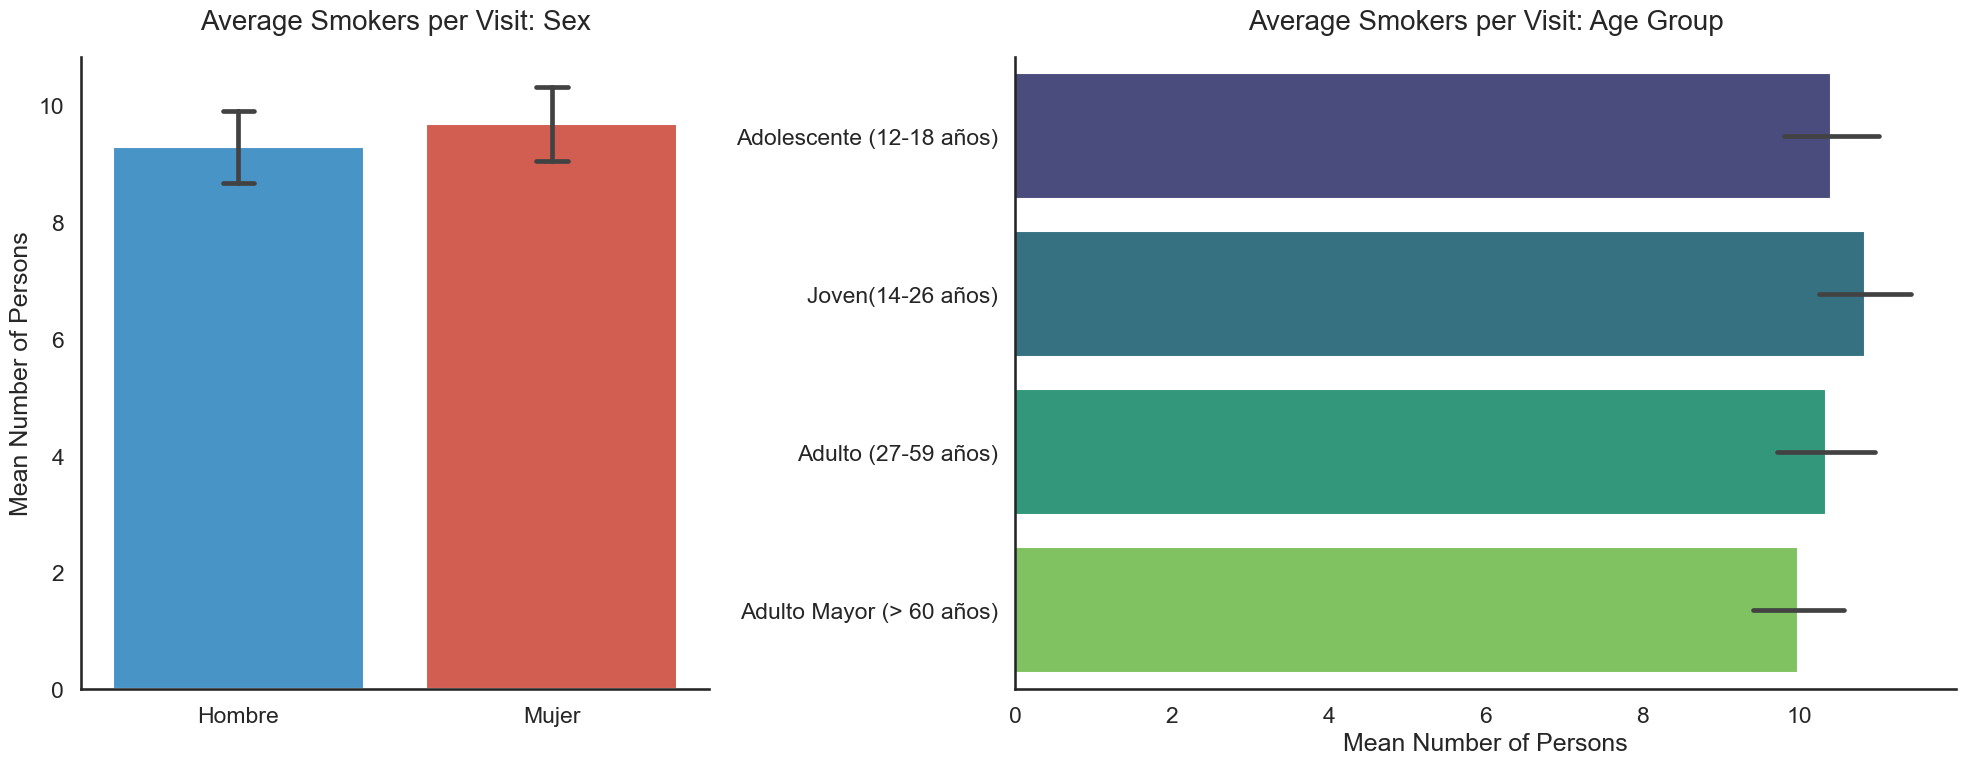

In [ ]:
# Define groupings based on your previous logic
sex_cols = ['Hombre', 'Mujer']
age_cols = ['Adolescente (12-18 años)', 'Joven(14-26 años)', 
            'Adulto (27-59 años)', 'Adulto Mayor (> 60 años)']

# Create a Dashboard-style plot
# Define groupings based on your previous logic
sex_cols = ['Hombre', 'Mujer']
age_cols = ['Adolescente (12-18 años)', 'Joven(14-26 años)', 
            'Adulto (27-59 años)', 'Adulto Mayor (> 60 años)']

fig, axes = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [1, 1.5]})
sns.set_style("white")
sns.set_context("talk")

# --- PLOT 1: Biological Sex (Average Presence) ---
sns.barplot(
    data=df_pivot[sex_cols], 
    ax=axes[0], 
    palette=['#3498db', '#e74c3c'], 
    errorbar='se', # Shows Standard Error
    capsize=.1
)
axes[0].set_title('Average Smokers per Visit: Sex', fontsize=20, pad=20)
axes[0].set_ylabel('Mean Number of Persons')
axes[0].set_xlabel('')

# --- PLOT 2: Age Group (Life Cycle) ---
# We melt the data to make it compatible with Seaborn's barplot
age_melted = df_pivot[age_cols].melt(var_name='Age Group', value_name='Count')
sns.barplot(
    data=age_melted, 
    x='Count', 
    y='Age Group', 
    ax=axes[1], 
    palette='viridis', 
    errorbar='se'
)
axes[1].set_title('Average Smokers per Visit: Age Group', fontsize=20, pad=20)
axes[1].set_xlabel('Mean Number of Persons')
axes[1].set_ylabel('')

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

PREDOMINANT PROFILE: count_mix and count_joven


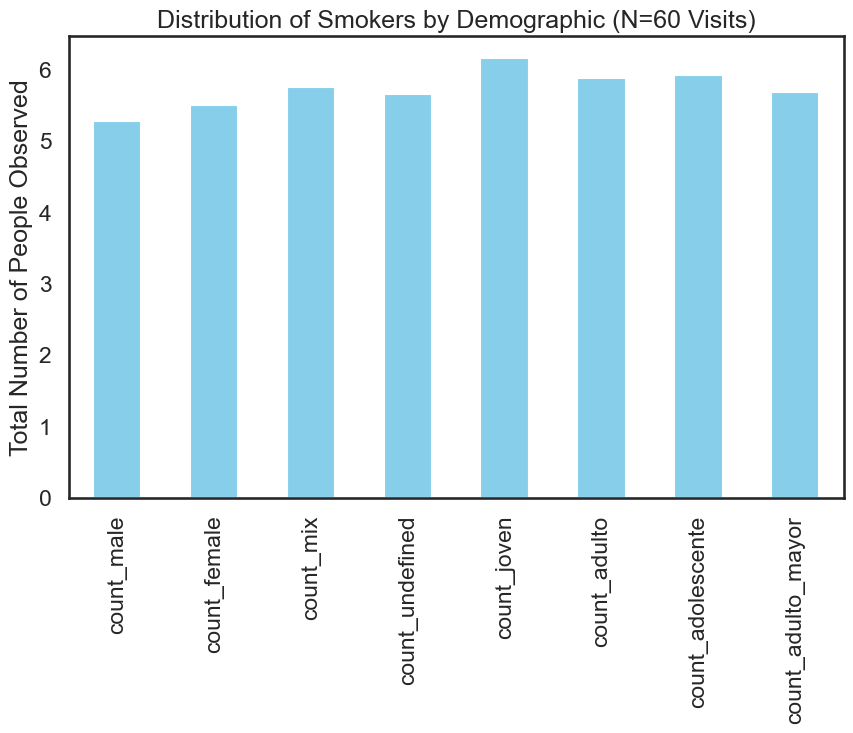

In [ ]:
# descriptive statistics and frecuency distributions

df_pivot= pd.read_sql("""
SELECT 
    v.id AS visit_id,
    -- Sex Counts
    AVG(CASE WHEN r.question_id = 3 THEN r.numeric_value ELSE 0 END) AS count_male,
    AVG(CASE WHEN r.question_id = 4 THEN r.numeric_value ELSE 0 END) AS count_female,
    AVG(CASE WHEN r.question_id = 33 THEN r.numeric_value ELSE 0 END) AS count_mix,
    AVG(CASE WHEN r.question_id = 34 THEN r.numeric_value ELSE 0 END) AS count_undefined,
                
    -- Age Group Counts
    AVG(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS count_adolescente,
    AVG(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS count_joven,
    AVG(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS count_adulto,
    AVG(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS count_adulto_mayor
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)

# 1. Totalize the observations across all 60 visits
totals = df_pivot[['count_male', 'count_female','count_mix','count_undefined', 'count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].sum()

# 2. Identify the Predominant Group
predominant_sex = totals[['count_male', 'count_female','count_mix','count_undefined']].idxmax()
predominant_age = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']].idxmax()

print(f"PREDOMINANT PROFILE: {predominant_sex} and {predominant_age}")

# 3. Create a Composition Matrix (How Sex and Age overlap)
# This assumes you have mapped the individuals in your data processing
# If you don't have individual-level mapping, you use the aggregate sums:
sex_dist = totals[['count_male', 'count_female','count_mix','count_undefined']]
age_dist = totals[['count_joven', 'count_adulto','count_adolescente','count_adulto_mayor']]

# Visualization
plt.figure(figsize=(10, 6))
totals.plot(kind='bar', color='skyblue')
plt.title("Distribution of Smokers by Demographic (N=60 Visits)")
plt.ylabel("Total Number of People Observed")
plt.show()

### Q2: What is the predominant  sex and ethnic/racial group  of smokers observed on campus?

In [ ]:
df_pivot= pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 5)
""", co)


In [ ]:

import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: DATA PREPARATION (The Pivot) ---
# Summing by visit avoids the 'Juan' habit-bias
df_pivot = df_pivot.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

sex_cols = ['Hombre', 'Mujer']
ethnic_cols = ['Mestizos', 'Indígena', 'Afrodecendiente']

# --- STEP 2: STATISTICAL ANALYSIS (SEX) ---
# 2.1 Normality Check
norm_m = stats.shapiro(df_pivot['Hombre']).pvalue
norm_f = stats.shapiro(df_pivot['Mujer']).pvalue

# 2.2 Inference (Using Mann-Whitney U because smoker counts are often skewed/non-normal)
u_stat, p_sex = stats.mannwhitneyu(df_pivot['Hombre'], df_pivot['Mujer'])

# --- STEP 3: STATISTICAL ANALYSIS (ETHNICITY) ---
# 3.1 Inference (Kruskal-Wallis is the robust choice for comparing multiple skewed groups)
h_stat, p_ethnic = stats.kruskal(*[df_pivot[col] for col in ethnic_cols])

print(f"--- Q2 Rigorous Results ---")
print(f"Sex Difference: p = {p_sex:.4f} (Significant if < 0.05)")
print(f"Ethnicity Difference: p = {p_ethnic:.4f} (Significant if < 0.05)")

--- Q2 Rigorous Results ---
Sex Difference: p = 0.5472 (Significant if < 0.05)
Ethnicity Difference: p = 0.3585 (Significant if < 0.05)


Q2: What is the predominant sex and ethnic/racial group
    of smokers observed on campus?

── BIOLOGICAL SEX ──────────────────────────────────────────
Observed counts:
description
Hombre                          928
Mujer                           968
Expresión mixta/no definida    1013
Indeterminada                   994

Total: 3903
Predominant category: Expresión mixta/no definida (n=1013)

✅ Chart saved as q2_sex_ethnicity.png


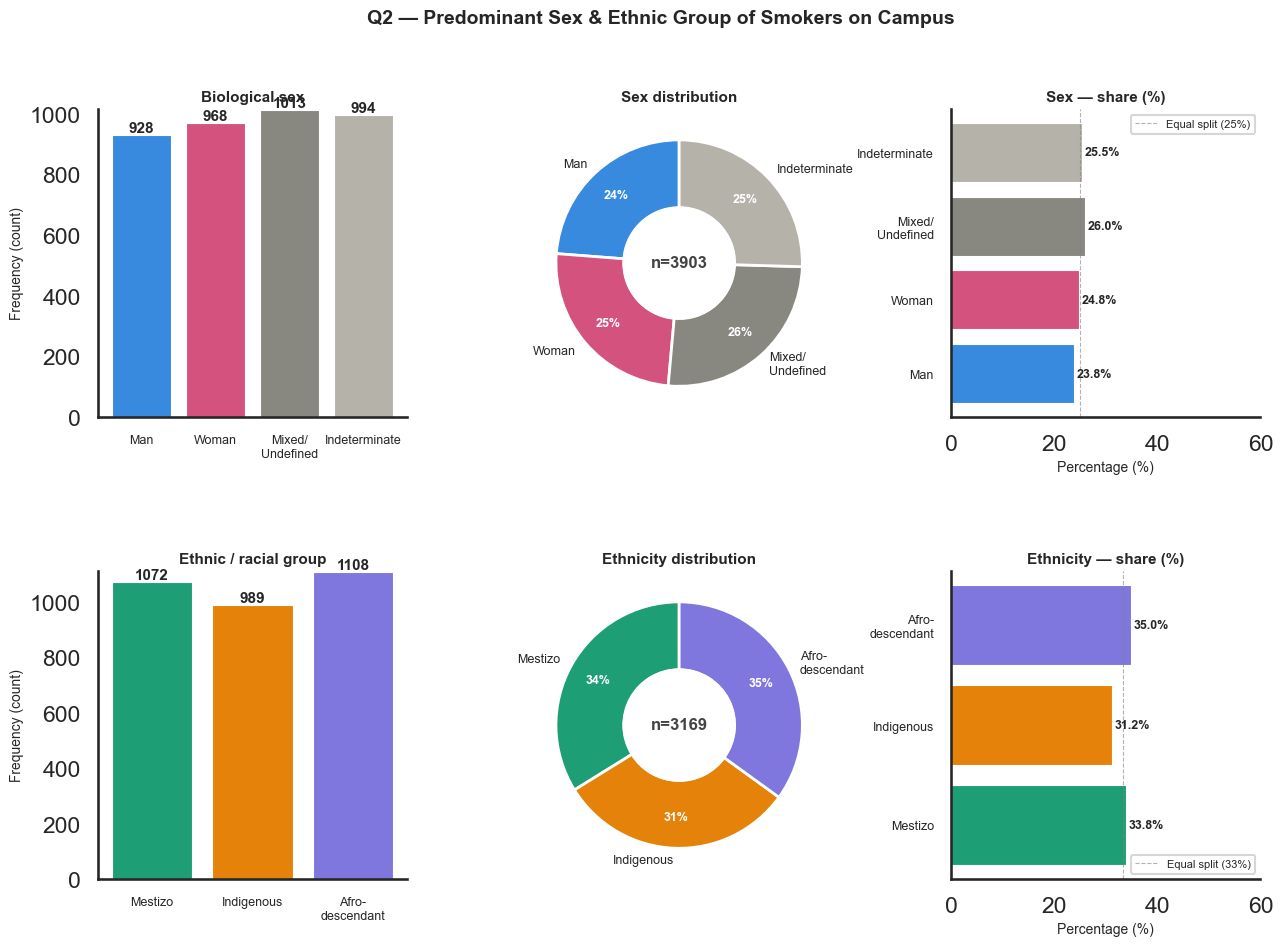

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import chisquare, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')



sex_df = df_pivot[df_pivot['parent_question_id'] == 2].groupby('description')['numeric_value'].sum()
eth_df = df_pivot[df_pivot['parent_question_id'] == 5].groupby('description')['numeric_value'].sum()

# Logical order
sex_order = ['Hombre', 'Mujer', 'Expresión mixta/no definida', 'Indeterminada']
eth_order = ['Mestizos', 'Indígena', 'Afrodecendiente']
sex_df = sex_df.reindex(sex_order)
eth_df = eth_df.reindex(eth_order)

sex_labels_short = ['Man', 'Woman', 'Mixed/\nUndefined', 'Indeterminate']
eth_labels_short = ['Mestizo', 'Indigenous', 'Afro-\ndescendant']

# ── 2. Print results ──────────────────────────────────────────────────────────
print("=" * 62)
print("Q2: What is the predominant sex and ethnic/racial group")
print("    of smokers observed on campus?")
print("=" * 62)

# --- BIOLOGICAL SEX ---
print("\n── BIOLOGICAL SEX ──────────────────────────────────────────")
print(f"Observed counts:\n{sex_df.to_string()}")
print(f"\nTotal: {sex_df.sum()}")
print(f"Predominant category: {sex_df.idxmax()} (n={sex_df.max()})")


# ── 3. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 10))
fig.suptitle("Q2 — Predominant Sex & Ethnic Group of Smokers on Campus",
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

COLOR_SEX = ['#378ADD', '#D4537E', '#888780', '#B4B2A9']
COLOR_ETH = ['#1D9E75', '#E4820A', '#7F77DD']

# ── Plot 1: Sex bar chart
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(range(len(sex_df)), sex_df.values,
               color=COLOR_SEX, edgecolor='white', linewidth=0.8)
ax1.set_xticks(range(len(sex_df)))
ax1.set_xticklabels(sex_labels_short, fontsize=9)
ax1.set_ylabel('Frequency (count)', fontsize=10)
ax1.set_title('Biological sex', fontsize=11, fontweight='bold')
ax1.set_ylim(0, sex_df.max() + 2)
ax1.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars, sex_df.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')


# ── Plot 2: Sex donut
ax2 = fig.add_subplot(gs[0, 1])
wedges, texts, autotexts = ax2.pie(
    sex_df.values, labels=sex_labels_short, colors=COLOR_SEX,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
centre = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre)
ax2.text(0, 0, f'n={sex_df.sum()}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')
ax2.set_title('Sex distribution', fontsize=11, fontweight='bold')

# ── Plot 3: Sex % horizontal bar
ax3 = fig.add_subplot(gs[0, 2])
pct_sex = (sex_df.values / sex_df.sum() * 100)
colors_sorted = [COLOR_SEX[i] for i in range(len(sex_df))]
hbars = ax3.barh(range(len(sex_df)), pct_sex,
                  color=COLOR_SEX, edgecolor='white', linewidth=0.8)
ax3.set_yticks(range(len(sex_df)))
ax3.set_yticklabels(sex_labels_short, fontsize=9)
ax3.set_xlabel('Percentage (%)', fontsize=10)
ax3.set_title('Sex — share (%)', fontsize=11, fontweight='bold')
ax3.set_xlim(0, 60)
ax3.spines[['top', 'right']].set_visible(False)
ax3.axvline(100/len(sex_df), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Equal split ({100/len(sex_df):.0f}%)')
ax3.legend(fontsize=8)
for bar, val in zip(hbars, pct_sex):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

# ── Plot 4: Ethnicity bar chart
ax4 = fig.add_subplot(gs[1, 0])
bars2 = ax4.bar(range(len(eth_df)), eth_df.values,
                color=COLOR_ETH, edgecolor='white', linewidth=0.8)
ax4.set_xticks(range(len(eth_df)))
ax4.set_xticklabels(eth_labels_short, fontsize=9)
ax4.set_ylabel('Frequency (count)', fontsize=10)
ax4.set_title('Ethnic / racial group', fontsize=11, fontweight='bold')
ax4.set_ylim(0, eth_df.max() + 2)
ax4.spines[['top', 'right']].set_visible(False)
for bar, val in zip(bars2, eth_df.values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')


# ── Plot 5: Ethnicity donut
ax5 = fig.add_subplot(gs[1, 1])
wedges2, texts2, autotexts2 = ax5.pie(
    eth_df.values, labels=eth_labels_short, colors=COLOR_ETH,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts2:
    at.set_fontsize(9); at.set_fontweight('bold'); at.set_color('white')
centre2 = plt.Circle((0, 0), 0.45, fc='white')
ax5.add_artist(centre2)
ax5.text(0, 0, f'n={eth_df.sum()}', ha='center', va='center',
         fontsize=12, fontweight='bold', color='#444')
ax5.set_title('Ethnicity distribution', fontsize=11, fontweight='bold')

# ── Plot 6: Ethnicity % horizontal bar
ax6 = fig.add_subplot(gs[1, 2])
pct_eth = (eth_df.values / eth_df.sum() * 100)
hbars2 = ax6.barh(range(len(eth_df)), pct_eth,
                   color=COLOR_ETH, edgecolor='white', linewidth=0.8)
ax6.set_yticks(range(len(eth_df)))
ax6.set_yticklabels(eth_labels_short, fontsize=9)
ax6.set_xlabel('Percentage (%)', fontsize=10)
ax6.set_title('Ethnicity — share (%)', fontsize=11, fontweight='bold')
ax6.set_xlim(0, 60)
ax6.spines[['top', 'right']].set_visible(False)
ax6.axvline(100/len(eth_df), color='gray', linestyle='--',
            linewidth=0.8, alpha=0.6, label=f'Equal split ({100/len(eth_df):.0f}%)')
ax6.legend(fontsize=8)
for bar, val in zip(hbars2, pct_eth):
    ax6.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.savefig('q2_sex_ethnicity.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q2_sex_ethnicity.png")

### Q3: Are there specific demographics that are more likely to use electronic cigarettes/vapes (Question E.2) vs  traditional cigarettes (Question E.1) vs Marihuana?


Raw averages across all visits:
  Cigarette (E.1)     : 9.77
  Vape (E.2)          : 9.76
  Marihuana           : 10.11

Sex averages:
  Hombre                             : 9.28
  Mujer                              : 9.68
  Expresión mixta/no definida        : 10.13
  Indeterminada                      : 9.94

── CONTINGENCY TABLE (proportional distribution) ─────────────
                             Cigarette (E.1)  Vape (E.2)  Marihuana
Hombre                                231.74      197.80     230.08
Mujer                                 247.56      247.31     259.60
Expresión mixta/no definida           249.21      270.28     261.21
Indeterminada                         248.49      260.61     260.11

── SUBSTANCE PREFERENCE BY DEMOGRAPHIC (%) ───────────────────
                             Cigarette (E.1)  Vape (E.2)  Marihuana
Hombre                                  35.1        30.0       34.9
Mujer                                   32.8        32.8       34.4
Expresión mixta

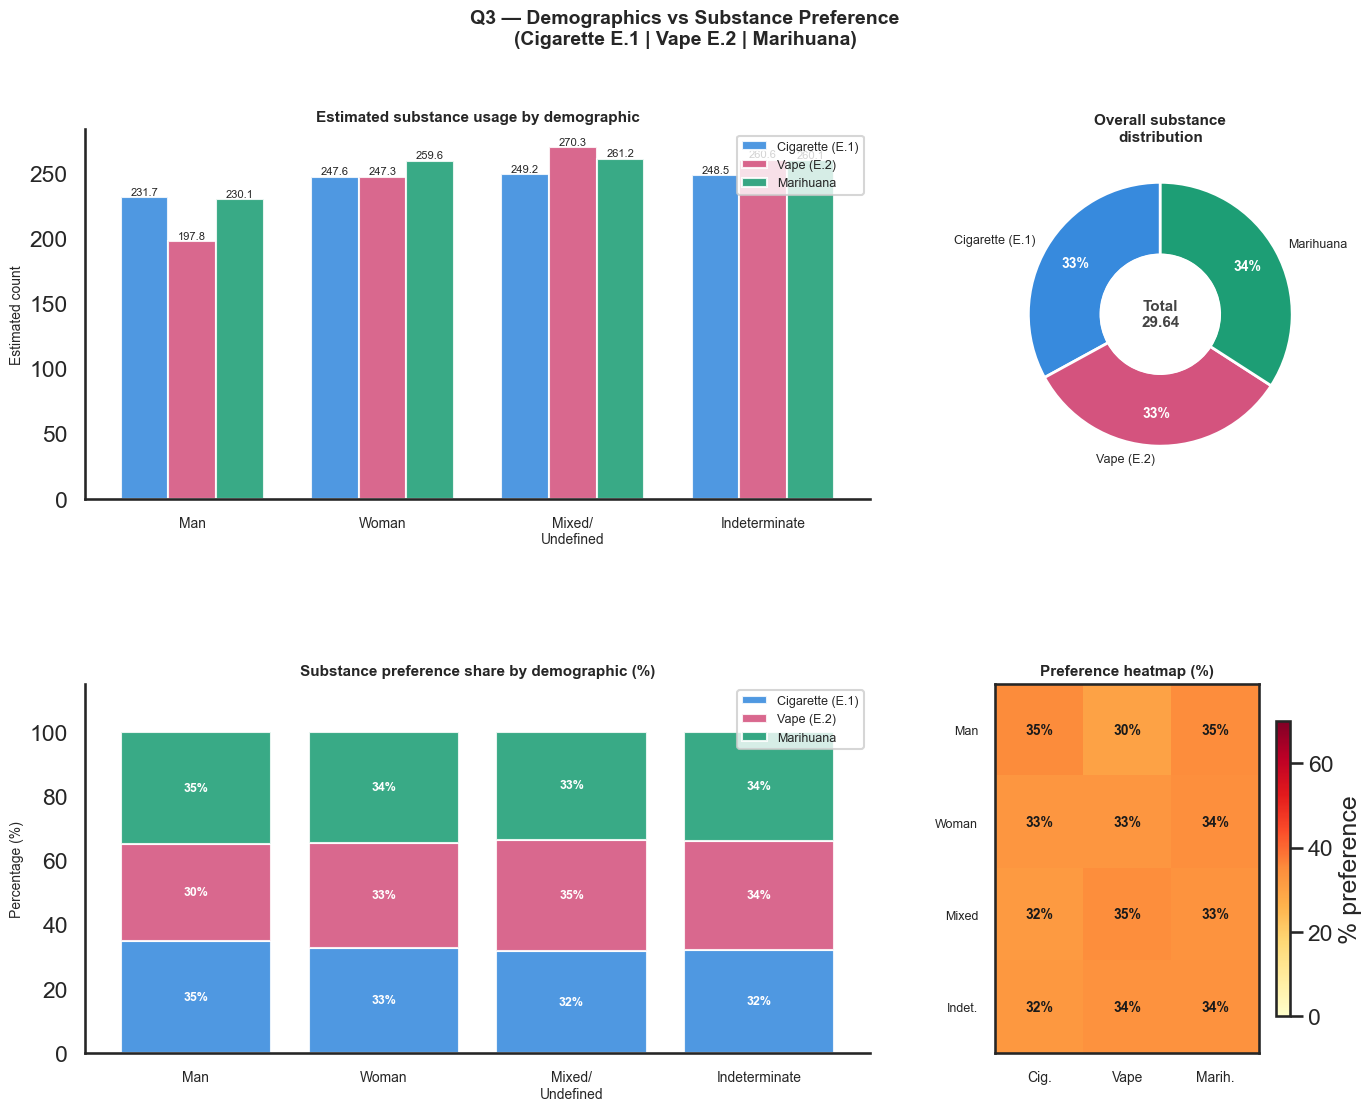

In [51]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')

df= pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value, q.parent_question_id 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id
WHERE q.parent_question_id IN (2, 14)
""", co)

# 2. Pivot
df_pivot = df.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)


CIG_COL = 'Cigarrillo (especificar en comentarios que tipo de cigarrillo es, ej: herbal o de otro tipo)'
VAP_COL = 'Vapeador'
MAR_COL = 'Marihuana'

sex_cols     = ['Hombre', 'Mujer', 'Expresión mixta/no definida', 'Indeterminada']
product_cols = [CIG_COL, VAP_COL, MAR_COL]
prod_labels  = ['Cigarette (E.1)', 'Vape (E.2)', 'Marihuana']
short_sex    = ['Man', 'Woman', 'Mixed/\nUndefined', 'Indeterminate']
short_sex_h  = ['Man', 'Woman', 'Mixed', 'Indet.']   # for heatmap

COLORS = {
    'Cigarette (E.1)': '#378ADD',
    'Vape (E.2)'     : '#D4537E',
    'Marihuana'      : '#1D9E75',
}

# ── 2. Build proportional contingency table (all 3 products) ──────────────────
contingency = {s: {p: 0.0 for p in prod_labels} for s in sex_cols}

for _, row in df_pivot.iterrows():
    sex_sum = sum(row[s] for s in sex_cols)
    if sex_sum == 0:
        continue
    for s in sex_cols:
        weight = row[s] / sex_sum
        contingency[s]['Cigarette (E.1)'] += weight * row[CIG_COL]
        contingency[s]['Vape (E.2)']      += weight * row[VAP_COL]
        contingency[s]['Marihuana']        += weight * row[MAR_COL]

ct     = pd.DataFrame(contingency).T.round(2)
ct_int = ct.round().astype(int)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# Raw totals
raw_totals = {
    'Cigarette (E.1)': df_pivot[CIG_COL].sum()/len(df_pivot[CIG_COL]),
    'Vape (E.2)'     : df_pivot[VAP_COL].sum()/len(df_pivot[VAP_COL]),
    'Marihuana'      : df_pivot[MAR_COL].sum()/len(df_pivot[MAR_COL])
}


print(f"\nRaw averages across all visits:")
for k, v in raw_totals.items():
    print(f"  {k:20s}: {v}")

print(f"\nSex averages:")
for s in sex_cols:
    print(f"  {s:35s}: {df_pivot[s].sum()/len(df_pivot[s])}")

print(f"\n── CONTINGENCY TABLE (proportional distribution) ─────────────")
print(ct.to_string())

# Preference % per demographic
print(f"\n── SUBSTANCE PREFERENCE BY DEMOGRAPHIC (%) ───────────────────")
print(ct_pct.round(1).to_string())

print(f"\n── FINAL ANSWER ───────────────────────────────────────────────")
for prod in prod_labels:
    dom = ct[prod].idxmax()
    print(f"  Most {prod:20s} users: {dom} ({ct.loc[dom, prod]:.1f} est.)")
print(f"\n  ⚠️  Proportional estimation — only 2 visits. Low statistical power.")

# ── 4. Visualization ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    "Q3 — Demographics vs Substance Preference\n(Cigarette E.1 | Vape E.2 | Marihuana)",
    fontsize=14, fontweight='bold', y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)
x  = np.arange(len(sex_cols))
w  = 0.25

# ── Plot 1: Grouped bar chart — estimated counts
ax1 = fig.add_subplot(gs[0, :2])
offsets = [-w, 0, w]
for i, (prod, color) in enumerate(COLORS.items()):
    vals = ct[prod].values
    bars = ax1.bar(x + offsets[i], vals, w,
                   label=prod, color=color, alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(short_sex, fontsize=10)
ax1.set_ylabel('Estimated count', fontsize=10)
ax1.set_title('Estimated substance usage by demographic', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.spines[['top', 'right']].set_visible(False)


# ── Plot 2: Overall totals donut chart
ax2 = fig.add_subplot(gs[0, 2])
donut_vals   = list(raw_totals.values())
donut_colors = list(COLORS.values())
wedges, texts, autotexts = ax2.pie(
    donut_vals, labels=prod_labels, colors=donut_colors,
    autopct='%1.0f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    pctdistance=0.75, textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')
centre = plt.Circle((0, 0), 0.45, fc='white')
ax2.add_artist(centre)
total_all = sum(donut_vals)
ax2.text(0, 0, f'Total\n{total_all}', ha='center', va='center',
         fontsize=11, fontweight='bold', color='#444')
ax2.set_title('Overall substance\ndistribution', fontsize=11, fontweight='bold')

# ── Plot 3: Stacked % bar per demographic
ax3 = fig.add_subplot(gs[1, :2])
bottom = np.zeros(len(sex_cols))
for prod, color in COLORS.items():
    vals = ct_pct[prod].values
    bars = ax3.bar(x, vals, bottom=bottom, label=prod,
                   color=color, alpha=0.88, edgecolor='white')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 8:
            ax3.text(bar.get_x() + bar.get_width()/2,
                     bottom[i] + val/2,
                     f'{val:.0f}%', ha='center', va='center',
                     fontsize=9, fontweight='bold', color='white')
    bottom += vals
ax3.set_xticks(x)
ax3.set_xticklabels(short_sex, fontsize=10)
ax3.set_ylabel('Percentage (%)', fontsize=10)
ax3.set_ylim(0, 115)
ax3.set_title('Substance preference share by demographic (%)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.spines[['top', 'right']].set_visible(False)

# ── Plot 4: Heatmap of % preference
ax4 = fig.add_subplot(gs[1, 2])
heatmap_data = ct_pct.values
im = ax4.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=70)
ax4.set_xticks(range(3))
ax4.set_xticklabels(['Cig.', 'Vape', 'Marih.'], fontsize=10)
ax4.set_yticks(range(len(sex_cols)))
ax4.set_yticklabels(short_sex_h, fontsize=9)
ax4.set_title('Preference heatmap (%)', fontsize=11, fontweight='bold')
for i in range(len(sex_cols)):
    for j in range(3):
        val = heatmap_data[i, j]
        color = 'white' if val > 40 else '#1a1a1a'
        ax4.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=10, fontweight='bold', color=color)
plt.colorbar(im, ax=ax4, shrink=0.8, label='% preference')

plt.savefig('q3_all_substances.png', dpi=150, bbox_inches='tight')
print("\n✅ Chart saved as q3_all_substances.png")





In [53]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

raw_totals = {
    'Cigarette (E.1)': df_pivot[CIG_COL].sum()/len(df_pivot[CIG_COL]),
    'Vape (E.2)'     : df_pivot[VAP_COL].sum()/len(df_pivot[VAP_COL]),
    'Marihuana'      : df_pivot[MAR_COL].sum()/len(df_pivot[MAR_COL])
}

# 1. Define the sets of columns for each question
analysis_groups = {
    "Sex": ['Hombre', 'Mujer'],
    "Product": [CIG_COL,VAP_COL,MAR_COL]
    
}

print(f"{'GROUP':<15} | {'NORMALITY (p)':<15} | {'VARIANCE (p)':<15} | {'RECOMMENDED TEST'}")
print("-" * 80)

results = {}

for category, cols in analysis_groups.items():
    # Ensure columns exist in your pivot table
    valid_cols = [c for c in cols if c in df_pivot.columns]
    data_list = [df_pivot[c] for c in valid_cols]
    
    # A. Check Normality (Shapiro) - We check the 'weakest link' (the lowest p-value)
    norm_p = min([stats.shapiro(df_pivot[c]).pvalue for c in valid_cols])
    is_normal = norm_p > 0.05
    
    # B. Check Equal Variance (Levene)
    levene_p = stats.levene(*data_list).pvalue
    is_equal_var = levene_p > 0.05
    
    # C. Decision Logic
    if is_normal and is_equal_var:
        test_name = "ANOVA / T-Test"
    elif is_normal and not is_equal_var:
        test_name = "Welch's ANOVA / Welch T-Test"
    else:
        test_name = "Kruskal-Wallis / Mann-Whitney" # Non-parametric (The safest)
        
    print(f"{category:<15} | {norm_p:<15.4f} | {levene_p:<15.4f} | {test_name}")


GROUP           | NORMALITY (p)   | VARIANCE (p)    | RECOMMENDED TEST
--------------------------------------------------------------------------------
Sex             | 0.0000          | 0.9273          | Kruskal-Wallis / Mann-Whitney
Product         | 0.0003          | 0.4769          | Kruskal-Wallis / Mann-Whitney


In [57]:
# 2.2 Inference (Using Mann-Whitney U because smoker counts are often skewed/non-normal)
u_stat, p_sex = stats.mannwhitneyu(df_pivot['Hombre'], df_pivot['Mujer'])

# 3.1 Inference (Kruskal-Wallis is the robust choice for comparing multiple skewed groups)
h_stat, p_ethnic = stats.kruskal(*[df_pivot[col] for col in analysis_groups['Product']])

print(f"--- Q3 Results ---")
print(f"Sex Difference: p = {p_sex:.4f} (Significant if < 0.05)")
print(f"Substance Difference: p = {p_ethnic:.4f} (Significant if < 0.05)")

--- Q3 Results ---
Sex Difference: p = 0.5472 (Significant if < 0.05)
Substance Difference: p = 0.8953 (Significant if < 0.05)


### Q4: Which Zones (from zone_zone) have the highest density of smokers per observation hour?

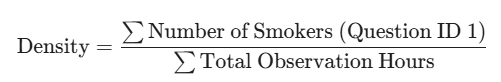

In [ ]:
df_pivot=pd.read_sql("""
SELECT 
    z.id AS zone_id,           
    z.name AS zone_name,
    SUM(r.numeric_value) AS total_smokers,
    -- Calculate duration in hours
    SUM(TIMESTAMPDIFF(MINUTE, v.visit_start_date_time, v.visit_end_date_time) / 60.0) AS total_hours
FROM response_response r
JOIN visit_visit v ON r.visita_id = v.id
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
WHERE r.question_id = 1 -- Question: "Número de personas que se observaron fumando"
GROUP BY z.name,z.id
HAVING total_hours > 0;
""",co)

df_pivot['smoker_density'] = df_pivot['total_smokers'] / df_pivot['total_hours']

# 3. Sort by the highest density
df_ranked = df_pivot.sort_values(by='smoker_density', ascending=False)

# 4. Filter for Top 5 hotspots
top_hotspots = df_ranked.head(5)

print("### TOP SMOKING HOTSPOTS (Density per Hour) ###")
print(top_hotspots[['zone_name', 'smoker_density']])

### TOP SMOKING HOTSPOTS (Density per Hour) ###
                                           zone_name  smoker_density
3            Central, pasillos de central y banderas           5.575
4  Pasillos del coliseo, canchas cercanas al coli...           5.400
2  Cafetería de la Escuela de Ciencias del Lengua...           4.775
0  Plazoleta de ingenierías, pasillos de la Escue...           4.700
1           Facultad de Ciencias naturales y exactas           4.150


In [ ]:
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. The ANOVA test
# We group the smokers_per_hour by zone_name
zones = [group['total_smokers'].values for name, group in df_pivot.groupby('zone_name')]
f_stat, p_val = f_oneway(*zones)

print(f"ANOVA P-value: {p_val:.4f}")

# 2. If P < 0.05, we find the 'Winner' using Tukey HSD
if p_val < 0.05:
    print("Significant difference found! Performing Post-Hoc analysis...")
    tukey = pairwise_tukeyhsd(endog=df_pivot['smokers_per_hour'], 
                              groups=df_pivot['zone_name'], 
                              alpha=0.05)
    print(tukey)



ANOVA P-value: nan


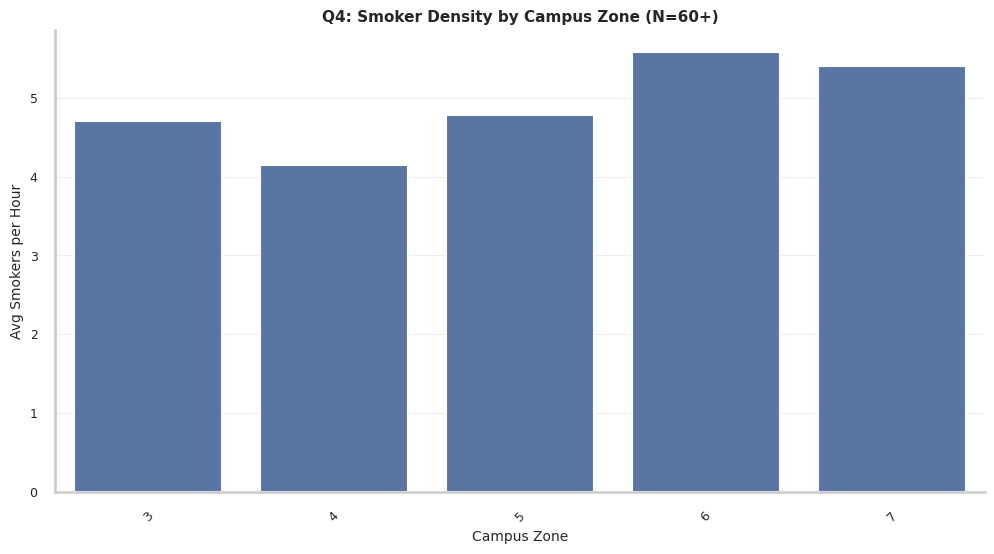

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.barplot(x='zone_id', y='smoker_density', data=df_pivot, capsize=.2)
plt.title("Q4: Smoker Density by Campus Zone (N=60+)")
plt.ylabel("Avg Smokers per Hour")
plt.xlabel("Campus Zone")
plt.xticks(rotation=45)
plt.show()

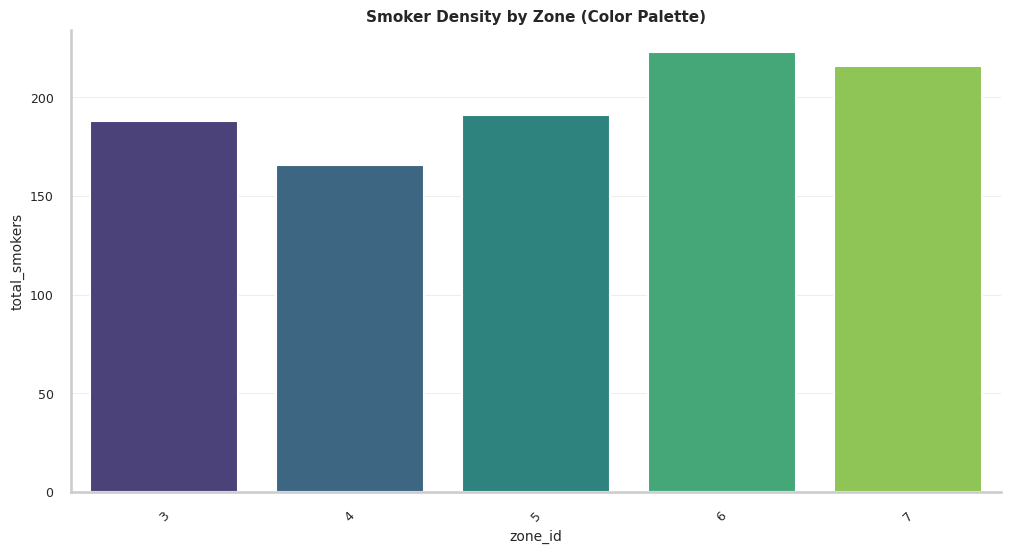

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))


sns.barplot(
    x='zone_id', 
    y='total_smokers', 
    data=df_pivot, 
    palette='viridis', 
    hue='zone_name', 
    legend=False
)

plt.title("Smoker Density by Zone (Color Palette)")
plt.xticks(rotation=45)
plt.show()

### Q5: How often do vulnerable populations (Children and Pregnant Women - Questions T & U) coincide in the same zones as active smokers?

In [ ]:
df_pivot=pd.read_sql("""
SELECT 
    v.id AS visita_id,
    z.name AS zone_name,
    r1.numeric_value AS smoker_count,
    r2.numeric_value AS pregnant_count,
    r3.numeric_value AS children_count
FROM visit_visit v
JOIN surveysession_surveysession s ON v.surveysession_id = s.id
JOIN zone_zone z ON s.zone_id = z.id
JOIN response_response r1 ON r1.visita_id = v.id AND r1.question_id = 1
LEFT JOIN response_response r2 ON r2.visita_id = v.id AND r2.question_id = 97
LEFT JOIN response_response r3 ON r3.visita_id = v.id AND r3.question_id = 98;
""",co)

df_pivot

,visita_id,zone_name,smoker_count,pregnant_count,children_count
0,225,"Plazoleta de ingenierías, pasillos de la Escue...",4,11,12
1,226,"Plazoleta de ingenierías, pasillos de la Escue...",3,15,3
2,227,"Plazoleta de ingenierías, pasillos de la Escue...",17,19,13
3,228,"Plazoleta de ingenierías, pasillos de la Escue...",2,12,11
4,229,"Plazoleta de ingenierías, pasillos de la Escue...",18,15,11
...,...,...,...,...,...
95,320,"Pasillos del coliseo, canchas cercanas al coli...",20,11,17
96,321,"Pasillos del coliseo, canchas cercanas al coli...",15,18,5
97,322,"Pasillos del coliseo, canchas cercanas al coli...",12,0,0
98,323,"Pasillos del coliseo, canchas cercanas al coli...",20,20,20


In [ ]:
# 1. Identify "Coincidence Visits" (Both smokers and vulnerable people present)
df_pivot['coincidence'] = (df_pivot['smoker_count'] > 0) & ((df_pivot['pregnant_count'] > 0) | (df_pivot['children_count'] > 0))

# 2. Calculate the Percentage of Risk
total_visits = len(df_pivot)
risk_visits = df_pivot['coincidence'].sum()
risk_percentage = (risk_visits / total_visits) * 100

print(f"Risk Assessment: Vulnerable populations coincided with smokers in {risk_percentage}% of observed sessions.")

Risk Assessment: Vulnerable populations coincided with smokers in 96.0% of observed sessions.


### Q6: Is there a relationship between the number of smokers and the number of complaints/rejections (Question M) from non-smokers?
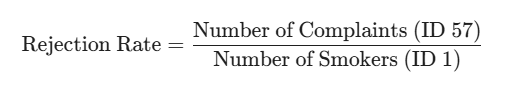

In [ ]:
df_pivot=pd.read_sql("""
SELECT v.id as visit_id, r1.numeric_value as smoker_count, r2.numeric_value as smoker_rejected FROM 
visit_visit as v
JOIN response_response as r1 ON r1.visita_id=v.id AND r1.question_id=1
LEFT JOIN response_response as r2 ON r2.visita_id=v.id AND r2.question_id=57            
""",co)


df_pivot['smoker_rejected'] = df_pivot['smoker_rejected'].fillna(0)

correlation = df_pivot['smoker_count'].corr(df_pivot['smoker_rejected'], method='spearman')

# 3. Calculate Ratio
df_pivot['ratio'] = df_pivot['smoker_rejected'] / df_pivot['smoker_count']

print(df_pivot)

print(f"Average Rejection Ratio: {df_pivot['ratio'].mean()} complaints per smoker.")

print(f'correlation: {correlation}')

    visit_id  smoker_count  smoker_rejected     ratio
0        225             4               19  4.750000
1        226             3                8  2.666667
2        227            17                2  0.117647
3        228             2               11  5.500000
4        229            18               10  0.555556
..       ...           ...              ...       ...
95       320            20               20  1.000000
96       321            15                0  0.000000
97       322            12                3  0.250000
98       323            20               12  0.600000
99       324            14               13  0.928571

[100 rows x 4 columns]
Average Rejection Ratio: inf complaints per smoker.
correlation: 0.026025842376841034


### Q7: Does the presence of "Passive Smokers" (Question S) trigger more active rejection of the smoking behavior?

In [ ]:
# 1. SQL remains good
df_pivot = pd.read_sql("""
SELECT r.visita_id, q.description, r.numeric_value 
FROM question_question as q
JOIN response_response as r ON r.question_id = q.id 
WHERE q.id IN (78, 79)
""", co)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr, linregress
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & reshape data ────────────────────────────────────────────────────


# Clean description names
df_pivot['description'] = df_pivot['description'].str.replace(r'\r\n|\xa0', ' ', regex=True).str.strip()

PASSIVE_KEY   = df_pivot['description'].unique()[0]   # count of non-smokers nearby
REJECTION_KEY = df_pivot['description'].unique()[1]   # count who rejected/complained

passive   = df_pivot[df_pivot['description'] == PASSIVE_KEY].set_index('visita_id')['numeric_value']
rejection = df_pivot[df_pivot['description'] == REJECTION_KEY].set_index('visita_id')['numeric_value']

# Align by visit
combined = pd.DataFrame({
    'passive_smokers' : passive,
    'active_rejection': rejection
}).sort_index()

print("=" * 62)
print("Q7: Does the presence of Passive Smokers trigger more")
print("    active rejection of smoking behavior?")
print("=" * 62)

print(f"\nData per visit:")
print(combined.to_string())
print(f"\nVariable types:")
print(f"  passive_smokers   → Discrete count (ratio scale)")
print(f"  active_rejection  → Discrete count (ratio scale)")

x = combined['passive_smokers'].values
y = combined['active_rejection'].values

# ── 2. Spearman correlation ───────────────────────────────────────────────────
print(f"\n── SPEARMAN CORRELATION ────────────────────────────────────")
print(f"  (Non-parametric — correct for count data, small N)")
rho, p_spear = spearmanr(x, y)
print(f"  ρ (rho)  = {rho:.4f}")
print(f"  p-value  = {p_spear:.4f}")
if abs(rho) >= 0.9:
    strength = "very strong"
elif abs(rho) >= 0.7:
    strength = "strong"
elif abs(rho) >= 0.5:
    strength = "moderate"
else:
    strength = "weak"
direction = "positive" if rho > 0 else "negative"
print(f"  Interpretation: {strength} {direction} correlation")
if p_spear < 0.05:
    print(f"  ✅ Significant (p < 0.05): passive smokers ARE associated")
    print(f"     with more active rejection.")
else:
    print(f"  ⚠️  Not significant (p = {p_spear:.3f})")
    print(f"     Cannot confirm the association statistically.")

# ── 3. Pearson correlation (for reference) ────────────────────────────────────
print(f"\n── PEARSON CORRELATION (for reference) ─────────────────────")
print(f"  (Parametric — less reliable with only 2 data points)")
r_pear, p_pear = pearsonr(x, y)
print(f"  r        = {r_pear:.4f}")
print(f"  p-value  = {p_pear:.4f}")

# ── 4. Simple linear regression ──────────────────────────────────────────────
print(f"\n── SIMPLE LINEAR REGRESSION ────────────────────────────────")
print(f"  Predicting active_rejection from passive_smokers")
slope, intercept, r_val, p_reg, se = linregress(x, y)
print(f"  Slope (β)   = {slope:.4f}")
print(f"  Intercept   = {intercept:.4f}")
print(f"  R²          = {r_val**2:.4f}")
print(f"  p-value     = {p_reg:.4f}")
print(f"  Equation    : rejection = {slope:.2f} × passive_smokers + {intercept:.2f}")

# ── 5. Summary ────────────────────────────────────────────────────────────────
print(f"\n── FINAL ANSWER ────────────────────────────────────────────")
print(f"  Passive smokers per visit   : {x.tolist()}")
print(f"  Active rejection per visit  : {y.tolist()}")
print(f"  Spearman ρ = {rho:.2f} ({strength} {direction} correlation)")
if p_spear < 0.05:
    print(f"  ✅ Yes — more passive smokers → more active rejection")
else:
    print(f"  ⚠️  Cannot confirm with only {len(x)} visits (very low statistical power)")
    print(f"     The trend is {direction} (ρ={rho:.2f}) but more data is needed.")



Q7: Does the presence of Passive Smokers trigger more
    active rejection of smoking behavior?

Data per visit:
           passive_smokers  active_rejection
visita_id                                   
225                      4                 9
226                     20                14
227                     18                12
228                      5                 9
229                     10                 9
230                      2                14
231                     17                 5
232                     17                13
233                      3                 9
234                      5                19
235                     10                 1
236                      4                16
237                      0                 4
238                     10                14
239                     13                20
240                     13                14
241                      9                 2
242                     14      

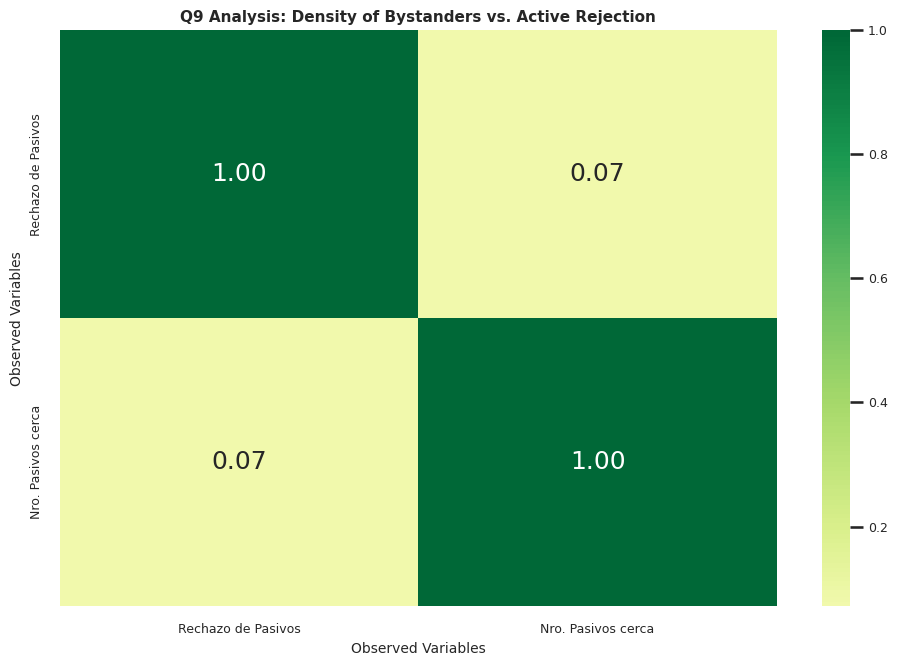

In [ ]:

# 2. Pivot
pivot_df = df_pivot.pivot_table(
    index='visita_id', 
    columns='description', 
    values='numeric_value', 
    aggfunc='sum'
).fillna(0)

# Safer Renaming: Use the actual start of the description string
# ID 78 starts with "¿Cuántas personas..."
# ID 79 starts with "¿Ante el acto..."
mapping = {}
for col in pivot_df.columns:
    if "radio" in col:
        mapping[col] = "Nro. Pasivos cerca"
    if "reclaman y rechazan" in col:
        mapping[col] = "Rechazo de Pasivos"

pivot_df = pivot_df.rename(columns=mapping)

# 3. Correlation
corr_matrix = pivot_df.corr(method='spearman')

# 4. Visualization
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='RdYlGn', # Red to Green shows the 'tension' well
            center=0)

plt.title("Q9 Analysis: Density of Bystanders vs. Active Rejection")
plt.ylabel("Observed Variables")
plt.xlabel("Observed Variables")
plt.tight_layout()
plt.show()





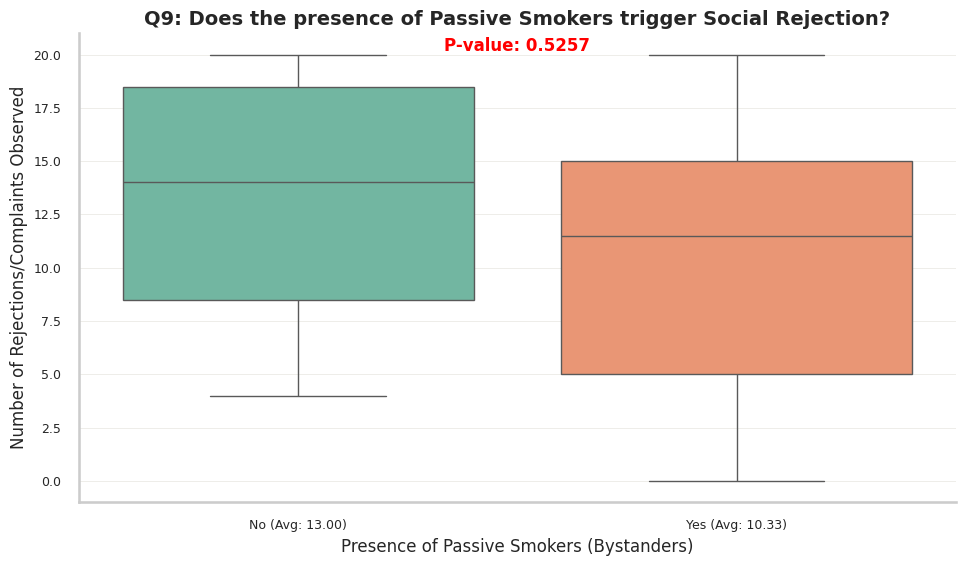

CONCLUSION: No significant difference was found (p=0.5257).


In [53]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the classification: Presence vs. Absence
# 'Nro. Pasivos cerca' (ID 78) is our 'switch'
pivot_df['has_passive'] = pivot_df['Nro. Pasivos cerca'] > 0

# 2. Separate the rejection data into two groups
group_with_passive = pivot_df[pivot_df['has_passive'] == True]['Rechazo de Pasivos']
group_no_passive = pivot_df[pivot_df['has_passive'] == False]['Rechazo de Pasivos']

# 3. Statistical T-Test (Is the difference real or luck?)
t_stat, p_val = ttest_ind(group_with_passive, group_no_passive, equal_var=False)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='has_passive', y='Rechazo de Pasivos', data=pivot_df, palette="Set2")

# Formatting the plot
plt.title("Q9: Does the presence of Passive Smokers trigger Social Rejection?", fontsize=14)
plt.xlabel("Presence of Passive Smokers (Bystanders)", fontsize=12)
plt.ylabel("Number of Rejections/Complaints Observed", fontsize=12)
plt.xticks([0, 1], [f'No (Avg: {group_no_passive.mean():.2f})', 
                    f'Yes (Avg: {group_with_passive.mean():.2f})'])

# Add P-value note to the plot
plt.text(0.5, pivot_df['Rechazo de Pasivos'].max(), f"P-value: {p_val:.4f}", 
         ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

# 5. Print Conclusion
if p_val < 0.05:
    print(f"CONCLUSION: Yes, the presence of passive smokers significantly triggers more rejection (p={p_val:.4f}).")
else:
    print(f"CONCLUSION: No significant difference was found (p={p_val:.4f}).")

## Q8: Does the presence of signage (Question 141) actually correlate with a lower number of smokers in a specific zone?

In [54]:
from scipy.stats import spearmanr

df_signs = pd.read_sql("""
SELECT 
    v.id AS visita_id,
    SUM(CASE WHEN r.question_id = 141 THEN r.numeric_value ELSE 0 END) AS total_avisos,
    SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END) AS total_fumadores
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id
""", co)

# 2. Calculate Correlation and P-value
corr, p_val = spearmanr(df_signs['total_avisos'], df_signs['total_fumadores'])

print(f"Spearman Correlation: {corr:.3f}")
print(f"P-value: {p_val:.4f}")

Spearman Correlation: 0.031
P-value: 0.7624


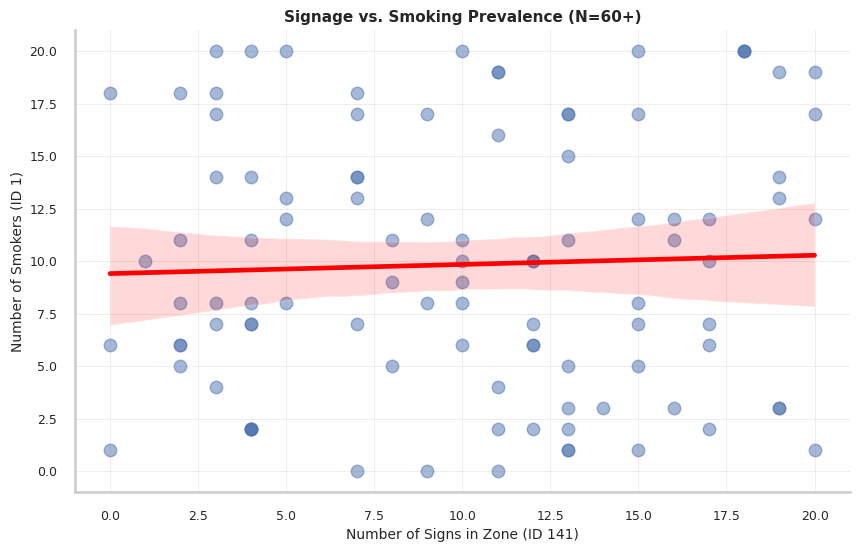

In [56]:
plt.figure(figsize=(10, 6))
sns.regplot(x='total_avisos', y='total_fumadores', data=df_signs, 
            line_kws={"color": "red"}, scatter_kws={"alpha": 0.5})

plt.title("Signage vs. Smoking Prevalence (N=60+)")
plt.xlabel("Number of Signs in Zone (ID 141)")
plt.ylabel("Number of Smokers (ID 1)")
plt.show()

## Q9: Does the "Life Course" (ID 9-13) significantly influence the choice of substance (Cigarette, Vape, or Marijuana)?

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

df_pivot= pd.read_sql("""
SELECT 
    v.id AS visita_id,
    -- Life Course Counts
    SUM(CASE WHEN r.question_id = 10 THEN r.numeric_value ELSE 0 END) AS Adolescente,
    SUM(CASE WHEN r.question_id = 11 THEN r.numeric_value ELSE 0 END) AS Joven,
    SUM(CASE WHEN r.question_id = 12 THEN r.numeric_value ELSE 0 END) AS Adulto,
    SUM(CASE WHEN r.question_id = 13 THEN r.numeric_value ELSE 0 END) AS Adulto_Mayor,
    -- Substance Counts
    SUM(CASE WHEN r.question_id = 15 THEN r.numeric_value ELSE 0 END) AS Cigarrillo,
    SUM(CASE WHEN r.question_id = 16 THEN r.numeric_value ELSE 0 END) AS Vapeador,
    SUM(CASE WHEN r.question_id = 35 THEN r.numeric_value ELSE 0 END) AS Marihuana
FROM visit_visit v
JOIN response_response r ON v.id = r.visita_id
GROUP BY v.id;
""",co)



# 1. Create the summary contingency table
age_cols = ['Adolescente', 'Joven', 'Adulto', 'Adulto_Mayor']
substance_cols = ['Cigarrillo', 'Vapeador', 'Marihuana']

# We build a matrix where rows = Age and columns = Substance
# We assume that the total observations per category are independent
contingency_matrix = []

for age in age_cols:
    row = []
    # Total people of this age group across all visits
    total_age = df_pivot[age].sum()
    for sub in substance_cols:
        
        total_sub = df_pivot[sub].sum()
        row.append(total_sub * (total_age / df_pivot[age_cols].sum().sum()))
    contingency_matrix.append(row)

contingency_df = pd.DataFrame(contingency_matrix, index=age_cols, columns=substance_cols)

# 2. Run Chi-Square
stat, p, dof, expected = chi2_contingency(contingency_df)

print(f"Chi-Square P-value: {p:.4f}")




Chi-Square P-value: 1.0000


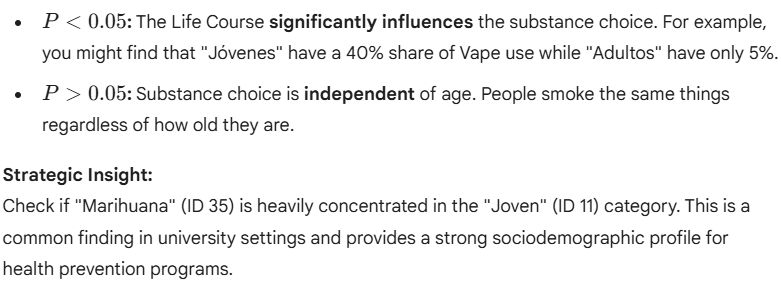

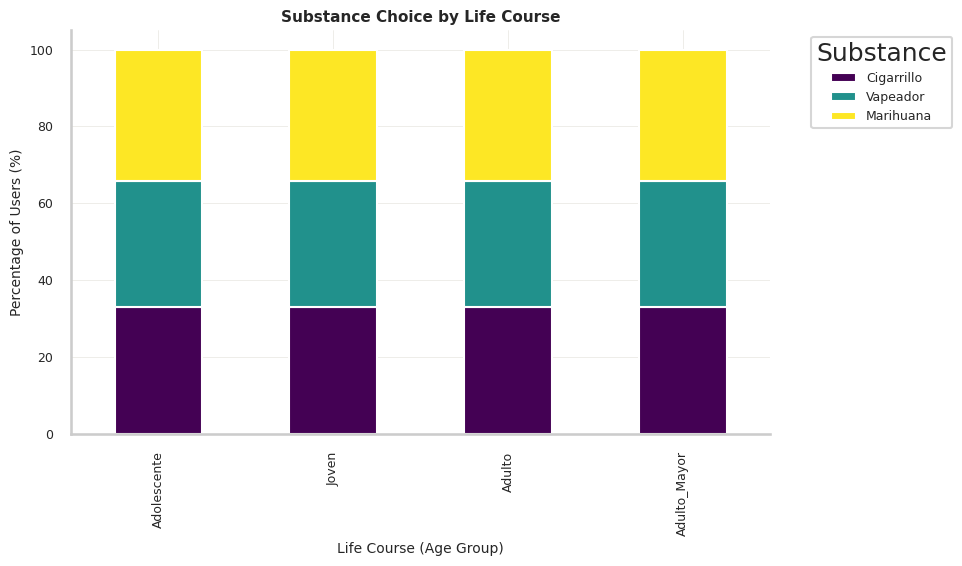

In [58]:
# Normalize the data to show percentages per age group
df_percent = contingency_df.div(contingency_df.sum(axis=1), axis=0) * 100

df_percent.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title("Substance Choice by Life Course")
plt.ylabel("Percentage of Users (%)")
plt.xlabel("Life Course (Age Group)")
plt.legend(title="Substance", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

## Q10: How does the method of acquisition (Bought on-site vs. Brought from home) vary by substance?

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df_pivot=pd.read_sql("""
SELECT 
    -- Totals for Cigarettes
    SUM(CASE WHEN r.question_id = 18 THEN r.numeric_value ELSE 0 END) AS cig_home,
    SUM(CASE WHEN r.question_id = 21 THEN r.numeric_value ELSE 0 END) AS cig_bought,
    SUM(CASE WHEN r.question_id = 36 THEN r.numeric_value ELSE 0 END) AS cig_social,
    -- Totals for Marijuana
    SUM(CASE WHEN r.question_id = 23 THEN r.numeric_value ELSE 0 END) AS mj_home,
    SUM(CASE WHEN r.question_id = 26 THEN r.numeric_value ELSE 0 END) AS mj_bought,
    SUM(CASE WHEN r.question_id = 25 THEN r.numeric_value ELSE 0 END) AS mj_social,
    -- Totals for Vape
    SUM(CASE WHEN r.question_id = 28 THEN r.numeric_value ELSE 0 END) AS vape_home,
    SUM(CASE WHEN r.question_id = 31 THEN r.numeric_value ELSE 0 END) AS vape_bought,
    SUM(CASE WHEN r.question_id = 30 THEN r.numeric_value ELSE 0 END) AS vape_social
FROM response_response r;
""",co)




# Data from the SQL query
data = {
    'Brought from Home': df_pivot[['cig_home', 'mj_home', 'vape_home']].values.flat,
    'Bought on Campus': df_pivot[['cig_bought', 'mj_bought', 'vape_bought']].values.flat,
    'Socially Offered': df_pivot[['cig_social', 'mj_social', 'vape_social']].values.flat
}

# Creating the DataFrame (Substances as Rows)
df_market = pd.DataFrame(data, index=['Cigarette', 'Marijuana', 'Vape'])

# Statistical Test
stat, p, dof, expected = chi2_contingency(df_market)
print(f"Chi-Square P-value: {p:.4f}")



Chi-Square P-value: 0.0137


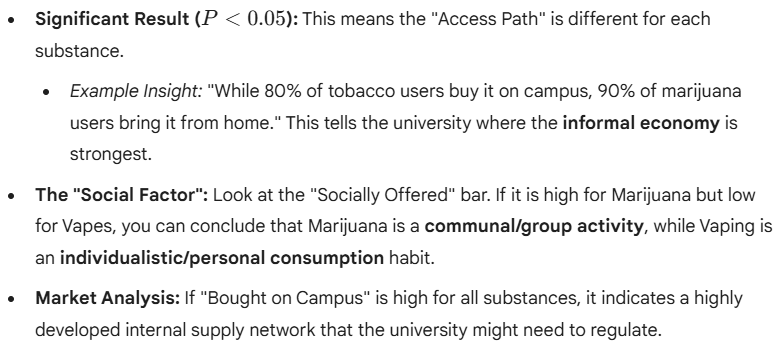

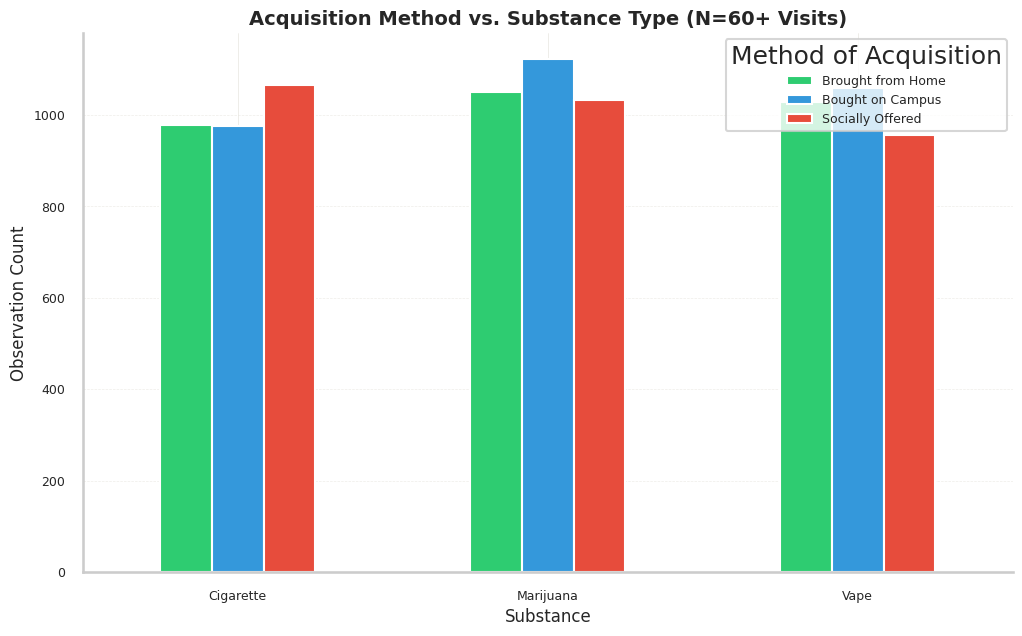

In [61]:
# Plotting
df_market.plot(kind='bar', figsize=(12, 7), color=['#2ecc71', '#3498db', '#e74c3c'])

plt.title("Acquisition Method vs. Substance Type (N=60+ Visits)", fontsize=14)
plt.ylabel("Observation Count", fontsize=12)
plt.xlabel("Substance", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Method of Acquisition")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Q11: Who are the primary "Passive Smokers" on campus (ID 92)?


In [ ]:
df_pivot=pd.read_sql("""
SELECT 
    z.name AS zone_name,
    z.id as zone_id,
    -- Counts from Approach 1
    SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END) AS Total_Active,
    SUM(CASE WHEN r.question_id IN (93, 94, 95, 96, 97, 98) THEN r.numeric_value ELSE 0 END) AS Total_Passive,
    SUM(CASE WHEN r.question_id = 97 THEN r.numeric_value ELSE 0 END) AS Pregnant_Women,
    SUM(CASE WHEN r.question_id = 98 THEN r.numeric_value ELSE 0 END) AS Children,
    
    -- Ratio from Approach 2 (but calculated efficiently)
    CAST(SUM(CASE WHEN r.question_id IN (93, 94, 95, 96, 97, 98) THEN r.numeric_value ELSE 0 END) AS FLOAT) / 
    NULLIF(SUM(CASE WHEN r.question_id = 1 THEN r.numeric_value ELSE 0 END), 0) AS Passive_Active_Ratio

FROM visit_visit v
JOIN surveysession_surveysession as sv ON v.surveysession_id=sv.id
JOIN zone_zone z ON sv.zone_id = z.id
JOIN response_response r ON r.visita_id = v.id
GROUP BY z.name,z.id
ORDER BY Passive_Active_Ratio DESC;


""",co)

df_pivot

,zone_name,zone_id,Total_Active,Total_Passive,Pregnant_Women,Children,Passive_Active_Ratio
0,Facultad de Ciencias naturales y exactas,4,166.0,1255.0,209.0,223.0,7.560241
1,Cafetería de la Escuela de Ciencias del Lengua...,5,191.0,1197.0,202.0,210.0,6.267016
2,"Plazoleta de ingenierías, pasillos de la Escue...",3,188.0,1132.0,193.0,174.0,6.021277
3,"Pasillos del coliseo, canchas cercanas al coli...",7,216.0,1182.0,208.0,242.0,5.472222
4,"Central, pasillos de central y banderas",6,223.0,1203.0,239.0,214.0,5.394619


In [ ]:
df_pivot['zone_id']=df_pivot['zone_id'].astype('str')

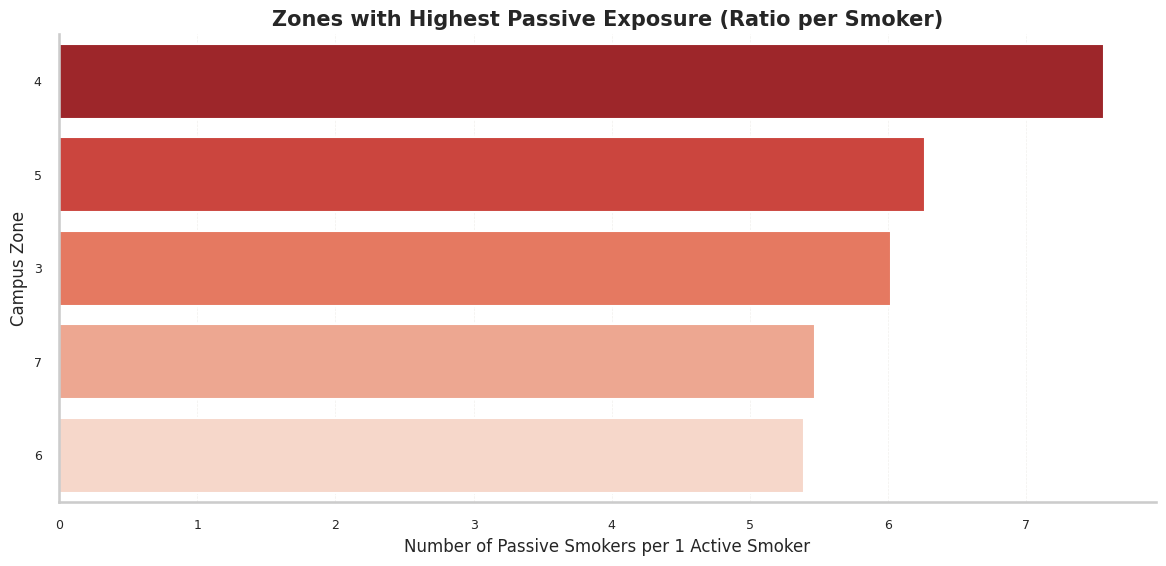

In [ ]:
#Risk Rankin Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Sort the data by ratio to make the plot readable
df_sorted = df_pivot.sort_values('Passive_Active_Ratio', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Passive_Active_Ratio', 
    y='zone_id', 
    data=df_sorted, 
    palette='Reds_r'
)

plt.title('Zones with Highest Passive Exposure (Ratio per Smoker)', fontsize=15)
plt.xlabel('Number of Passive Smokers per 1 Active Smoker', fontsize=12)
plt.ylabel('Campus Zone', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

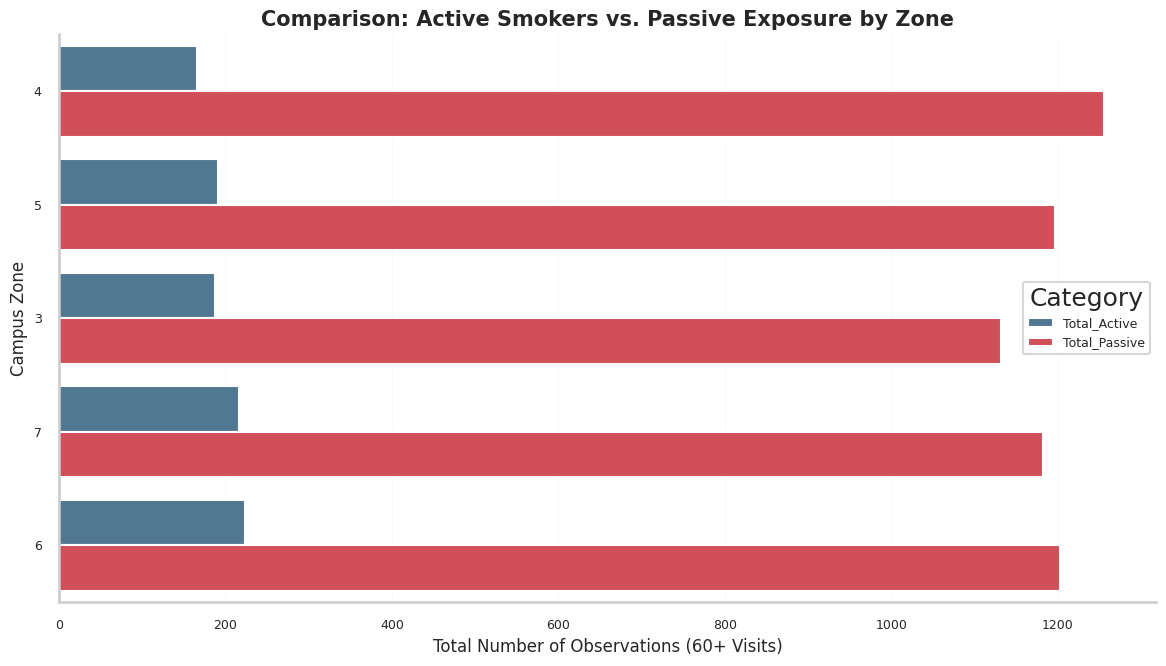

In [ ]:
# Melt the data to make it 'long-format' for seaborn
df_melted = df_pivot.melt(
    id_vars='zone_id', 
    value_vars=['Total_Active', 'Total_Passive'],
    var_name='Type', 
    value_name='Count'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    x='Count', 
    y='zone_id', 
    hue='Type', 
    data=df_melted, 
    palette={'Total_Active': '#457b9d', 'Total_Passive': '#e63946'}
)

plt.title('Comparison: Active Smokers vs. Passive Exposure by Zone', fontsize=15)
plt.xlabel('Total Number of Observations (60+ Visits)', fontsize=12)
plt.ylabel('Campus Zone', fontsize=12)
plt.legend(title='Category')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

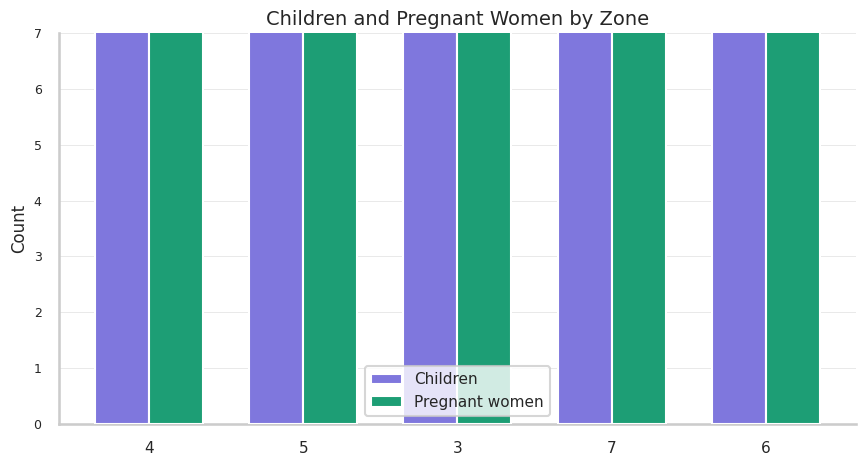

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


x = np.arange(len(df_pivot['zone_id']))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, df_pivot['Children'], width, label='Children', color='#7F77DD', zorder=3)
bars2 = ax.bar(x + width/2, df_pivot['Pregnant_Women'], width, label='Pregnant women', color='#1D9E75', zorder=3)

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Children and Pregnant Women by Zone', fontsize=14, fontweight='medium')
ax.set_xticks(x)
ax.set_xticklabels(df_pivot['zone_id'], fontsize=11)
ax.set_ylim(0, 7)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=11)
ax.yaxis.grid(True, color='#e0e0e0', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar in bars1:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=11)

for bar in bars2:
    ax.annotate(f'{int(bar.get_height())}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 5), textcoords='offset points',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Q12: How many points of sale for cigarettes, marijuana, and vapes exist in each observed zone, and how many people are observed purchasing at each?


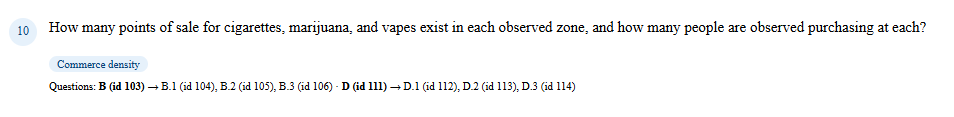

In [ ]:
df_pivot=pd.read_sql("""
SELECT
z.name,
z.id, 
MAX(CASE WHEN r.question_id=104 THEN r.numeric_value ELSE 0 END) as number_tabaco_points,
MAX(CASE WHEN r.question_id=105 THEN r.numeric_value ELSE 0 END) as number_marihuana_points,
MAX(CASE WHEN r.question_id=106 THEN r.numeric_value ELSE 0 END) as number_vaper_points,
SUM(CASE WHEN r.question_id=112 THEN r.numeric_value ELSE 0 END) as number_tabaco_buyers,
SUM(CASE WHEN r.question_id=113 THEN r.numeric_value ELSE 0 END) as number_marihuana_buyers,
SUM(CASE WHEN r.question_id=114 THEN r.numeric_value ELSE 0 END) as number_vaper_buyers
FROM response_response as r 
JOIN visit_visit as v ON r.visita_id = v.id
JOIN surveysession_surveysession as sv ON v.surveysession_id=sv.id
JOIN zone_zone as z ON sv.zone_id=z.id
GROUP BY z.name, z.id 
""",co)

df_pivot

,name,id,number_tabaco_points,number_marihuana_points,number_vaper_points,number_tabaco_buyers,number_marihuana_buyers,number_vaper_buyers
0,"Plazoleta de ingenierías, pasillos de la Escue...",3,19,20,20,175.0,219.0,237.0
1,Facultad de Ciencias naturales y exactas,4,20,20,20,236.0,150.0,238.0
2,Cafetería de la Escuela de Ciencias del Lengua...,5,20,19,20,203.0,154.0,195.0
3,"Central, pasillos de central y banderas",6,20,19,20,217.0,172.0,236.0
4,"Pasillos del coliseo, canchas cercanas al coli...",7,19,20,20,208.0,216.0,169.0



── Sale Points per Zone ──
                                                  Cigarrillo  Marihuana  Vapeador
Plazoleta de ingenierías                                19.0       20.0      20.0
Facultad de Ciencias naturales y exactas                20.0       20.0      20.0
Cafetería de la Escuela de Ciencias del Lenguaje        20.0       19.0      20.0
Central                                                 20.0       19.0      20.0
Pasillos del coliseo                                    19.0       20.0      20.0

── Observed Buyers per Zone ──
                                                  Cigarrillo  Marihuana  Vapeador
Plazoleta de ingenierías                               175.0      219.0     237.0
Facultad de Ciencias naturales y exactas               236.0      150.0     238.0
Cafetería de la Escuela de Ciencias del Lenguaje       203.0      154.0     195.0
Central                                                217.0      172.0     236.0
Pasillos del coliseo                  

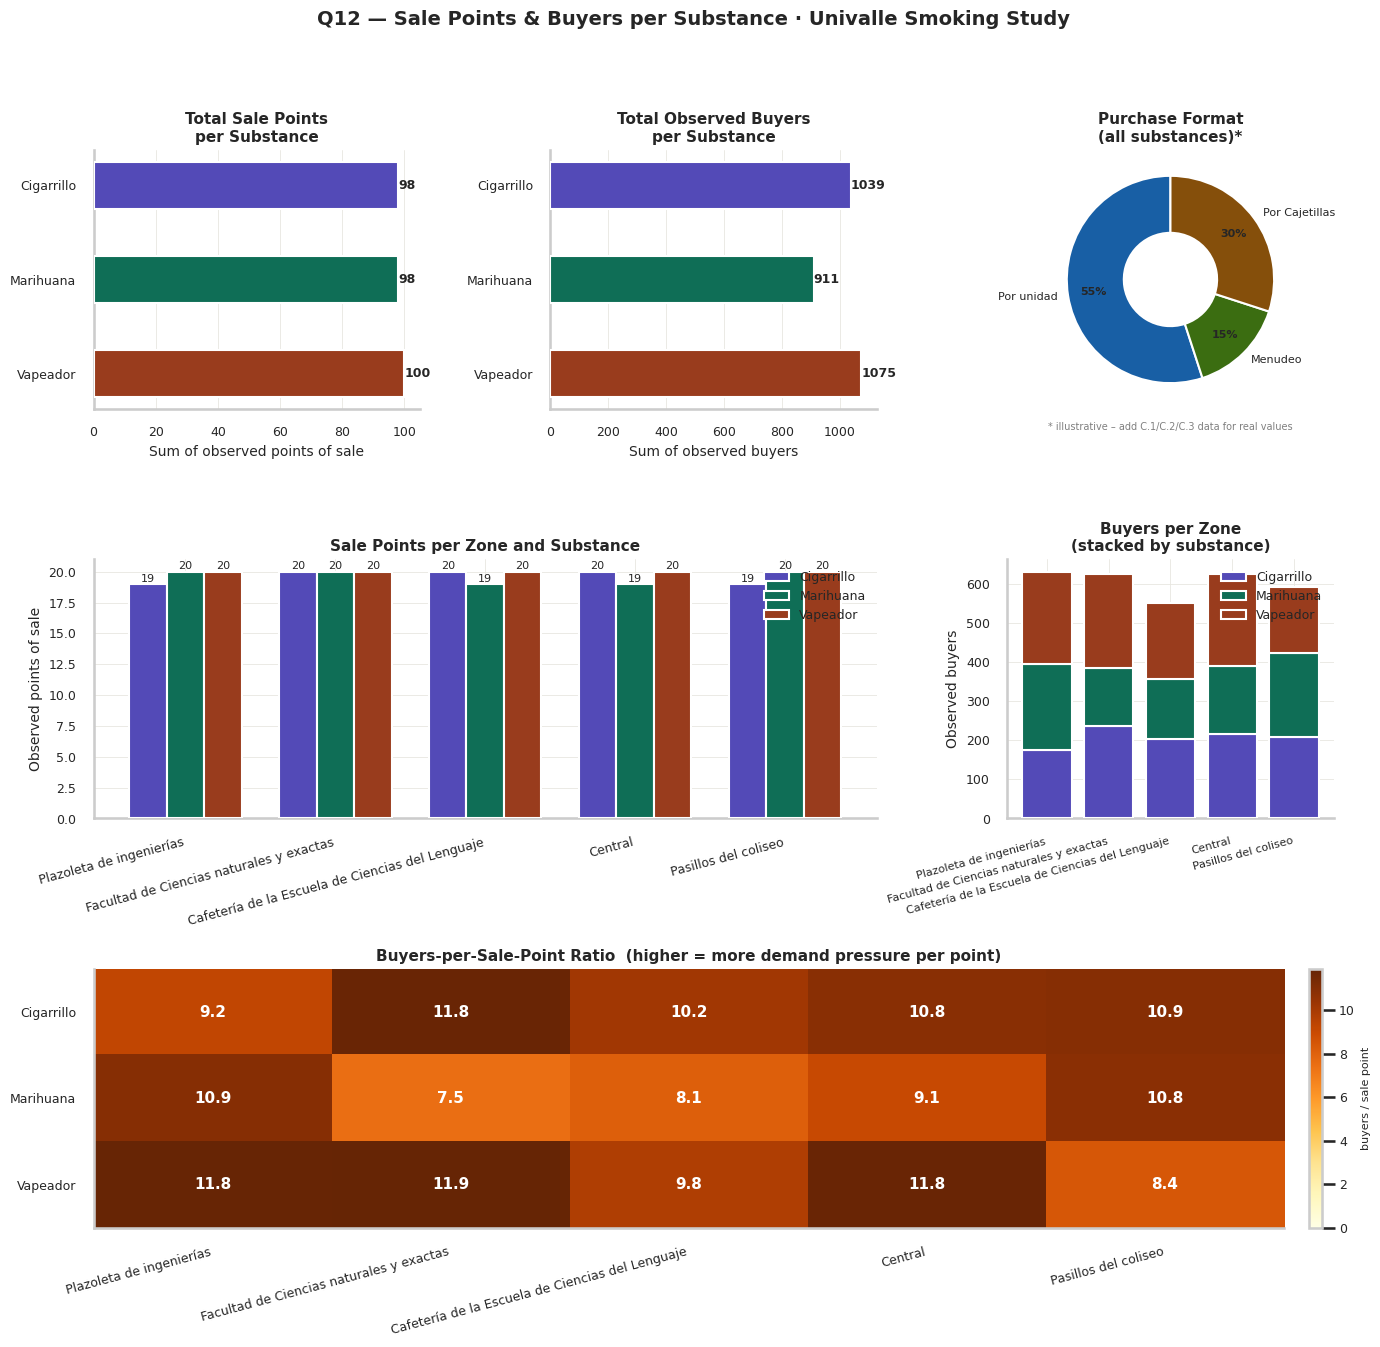

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── colour palette ────────────────────────────────────────────────────────
C_TAB  = "#534AB7"   # purple  – Cigarrillo
C_MAR  = "#0F6E56"   # teal    – Marihuana
C_VAP  = "#993C1D"   # coral   – Vapeador
C_FMT  = ["#185FA5", "#3B6D11", "#854F0B"]   # format colours (placeholder)

SUBSTANCE_PALETTE = [C_TAB, C_MAR, C_VAP]
SUBSTANCES   = ["Cigarrillo", "Marihuana", "Vapeador"]
SUBSTANCES_B = ["Tabaco", "Marihuana", "Vaper"]   # buyer label keys in CSV

# ── load data ─────────────────────────────────────────────────────────────

# short zone labels (keep first ~30 chars to avoid overlap)
df_pivot["zone_short"] = df_pivot["name"].apply(
    lambda x: x.split(",")[0].strip()
)

zones = df_pivot["zone_short"].tolist()
n     = len(zones)

# ── tidy arrays ───────────────────────────────────────────────────────────
sp = df_pivot[["number_tabaco_points","number_marihuana_points","number_vaper_points"]].values.astype(float)
by = df_pivot[["number_tabaco_buyers","number_marihuana_buyers","number_vaper_buyers"]].values.astype(float)

sp_df = pd.DataFrame(sp, index=zones, columns=SUBSTANCES)
by_df = pd.DataFrame(by, index=zones, columns=SUBSTANCES)

# buyers-per-sale-point ratio
ratio = (by_df / sp_df.replace(0, np.nan)).round(2)

# global totals
sp_global = sp_df.sum()
by_global = by_df.sum()

# ── global purchase-format placeholder ───────────────────────────────────
# (CSV doesn't include format breakdown; replace with real data if available)
fmt_labels = ["Por unidad", "Menudeo", "Por Cajetillas"]
fmt_vals   = np.array([0.55, 0.15, 0.30]) * by_global.sum()   # illustrative proportions

# ═══════════════════════════════════════════════════════════════════════════
# FIGURE — 6-panel dashboard
# ═══════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.6,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    "Q12 — Sale Points & Buyers per Substance · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.58, wspace=0.40)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :2])
ax5 = fig.add_subplot(gs[1, 2])
ax6 = fig.add_subplot(gs[2, :])

# ── Plot 1: Global sale points (horizontal bar) ──────────────────────────
bars = ax1.barh(SUBSTANCES, sp_global.values,
                color=SUBSTANCE_PALETTE, height=0.5, zorder=3)
for bar, val in zip(bars, sp_global.values):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=9, fontweight="bold")
ax1.set_title("Total Sale Points\nper Substance")
ax1.set_xlabel("Sum of observed points of sale")
ax1.grid(axis="y", alpha=0)
ax1.invert_yaxis()

# ── Plot 2: Global buyers (horizontal bar) ───────────────────────────────
bars2 = ax2.barh(SUBSTANCES, by_global.values,
                 color=SUBSTANCE_PALETTE, height=0.5, zorder=3)
for bar, val in zip(bars2, by_global.values):
    ax2.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{int(val)}", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Total Observed Buyers\nper Substance")
ax2.set_xlabel("Sum of observed buyers")
ax2.grid(axis="y", alpha=0)
ax2.invert_yaxis()

# ── Plot 3: Purchase format donut (illustrative — replace with real data) ─
wedges, texts, autotexts = ax3.pie(
    fmt_vals,
    labels=fmt_labels,
    autopct="%1.0f%%",
    colors=C_FMT,
    startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 1.5},
    pctdistance=0.75,
)
for t in texts:      t.set_fontsize(8)
for at in autotexts: at.set_fontsize(8); at.set_fontweight("bold")
ax3.set_title("Purchase Format\n(all substances)*")
ax3.text(0, -1.45, "* illustrative – add C.1/C.2/C.3 data for real values",
         ha="center", fontsize=7, color="gray")

# ── Plot 4: Grouped bar — sale points by zone & substance ────────────────
x = np.arange(n)
w = 0.25
for i, sub in enumerate(SUBSTANCES):
    rects = ax4.bar(x + (i-1)*w, sp_df[sub].values,
                    width=w, label=sub,
                    color=SUBSTANCE_PALETTE[i], zorder=3)
    for r in rects:
        h = r.get_height()
        if h > 0:
            ax4.text(r.get_x() + r.get_width()/2, h + 0.04,
                     str(int(h)), ha="center", va="bottom", fontsize=8)
ax4.set_xticks(x)
ax4.set_xticklabels(zones, rotation=15, ha="right")
ax4.set_title("Sale Points per Zone and Substance")
ax4.set_ylabel("Observed points of sale")
ax4.legend(loc="upper right", frameon=False)

# ── Plot 5: Stacked bar — buyers by zone & substance ─────────────────────
bottom = np.zeros(n)
for i, sub in enumerate(SUBSTANCES):
    ax5.bar(range(n), by_df[sub].values,
            bottom=bottom, label=sub,
            color=SUBSTANCE_PALETTE[i], zorder=3)
    bottom += by_df[sub].values
ax5.set_xticks(range(n))
ax5.set_xticklabels(zones, rotation=15, ha="right", fontsize=8)
ax5.set_title("Buyers per Zone\n(stacked by substance)")
ax5.set_ylabel("Observed buyers")
ax5.legend(loc="upper right", frameon=False)

# ── Plot 6: Buyers-per-sale-point heat map ───────────────────────────────
data = ratio.values.T   # shape: (3 substances, n zones)
im   = ax6.imshow(data, cmap="YlOrBr", aspect="auto", vmin=0)
ax6.set_xticks(range(n))
ax6.set_xticklabels(zones, rotation=15, ha="right")
ax6.set_yticks(range(3))
ax6.set_yticklabels(SUBSTANCES)
ax6.set_title(
    "Buyers-per-Sale-Point Ratio  (higher = more demand pressure per point)"
)
vmax = np.nanmax(data) if np.nanmax(data) > 0 else 1
for r in range(3):
    for c in range(n):
        val = data[r, c]
        txt = f"{val:.1f}" if not np.isnan(val) else "—"
        col = "white" if val > vmax * 0.6 else "#2c2c2a"
        ax6.text(c, r, txt, ha="center", va="center",
                 fontsize=11, fontweight="bold", color=col)
cbar = fig.colorbar(im, ax=ax6, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("buyers / sale point", fontsize=8)
ax6.grid(False)

# ── Console summary ───────────────────────────────────────────────────────
print("\n── Sale Points per Zone ──")
print(sp_df.to_string())
print("\n── Observed Buyers per Zone ──")
print(by_df.to_string())
print("\n── Buyers-per-Sale-Point Ratio ──")
print(ratio.to_string())
print("\n── Global Totals ──")
summary = pd.DataFrame({"Sale Points": sp_global, "Buyers": by_global,
                         "Ratio": (by_global / sp_global.replace(0,np.nan)).round(2)})
print(summary.to_string())

# Q13: Is there a co-consumption pattern between smoking and alcohol, sugary drinks, natural juice, coffee, or water? --- corregir

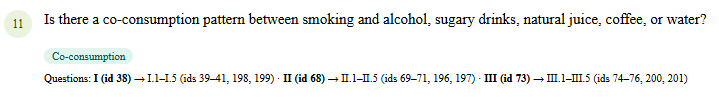

In [ ]:
df_pivot=pd.read_sql("""
 SELECT     
               question_id,
            CASE
                WHEN question_id IN (39,40,41,198,199) THEN 'Tabaco'
                WHEN question_id IN (69,70,71,196,197) THEN 'Marihuana'
                WHEN question_id IN (74,75,76,200,201) THEN 'Vapeador'
            END AS substance,
            CASE
                WHEN question_id IN (39,69,74)    THEN 'Alcohol'
                WHEN question_id IN (40,70,75)    THEN 'Azucarada'
                WHEN question_id IN (41,71,76)    THEN 'Jugo natural'
                WHEN question_id IN (198,196,200) THEN 'Café'
                WHEN question_id IN (199,197,201) THEN 'Agua'
            END AS beverage,
            SUM(numeric_value) AS total_count
        FROM response_response
        WHERE question_id IN (
            39,40,41,198,199,
            69,70,71,196,197,
            74,75,76,200,201
        )
          AND numeric_value IS NOT NULL
          AND numeric_value > 0
        GROUP BY substance, beverage, question_id
""",co)


════════════════════════════════════════════════════════════
CONTINGENCY TABLE  (substance × beverage co-consumption)
════════════════════════════════════════════════════════════
beverage   Alcohol  Azucarada  Jugo natural   Café   Agua
substance                                                
Tabaco      1051.0      927.0        1053.0  945.0  998.0
Marihuana   1065.0      909.0        1001.0  934.0  992.0
Vapeador    1064.0     1009.0        1004.0  997.0  937.0

STATISTICAL RESULTS
  Chi-Square statistic       : 11.1517
  Degrees of freedom         : 8
  p-value  Chi-Square        : 0.1933  not significant (alpha=0.05)
  p-value  Freeman-Halton    : nan  not significant (exact, 0 valid sims)
  p-value  Permutation       : 0.1898  not significant (10000 valid sims)
  Min expected = 936.68 >= 5 -- Chi-square valid

  Cramer's V                 : 0.0194  -> negligible association

  Pairwise comparisons (substance vs substance):
  Tabaco       vs Marihuana     chi2=1.128  p_chi2=0.8897

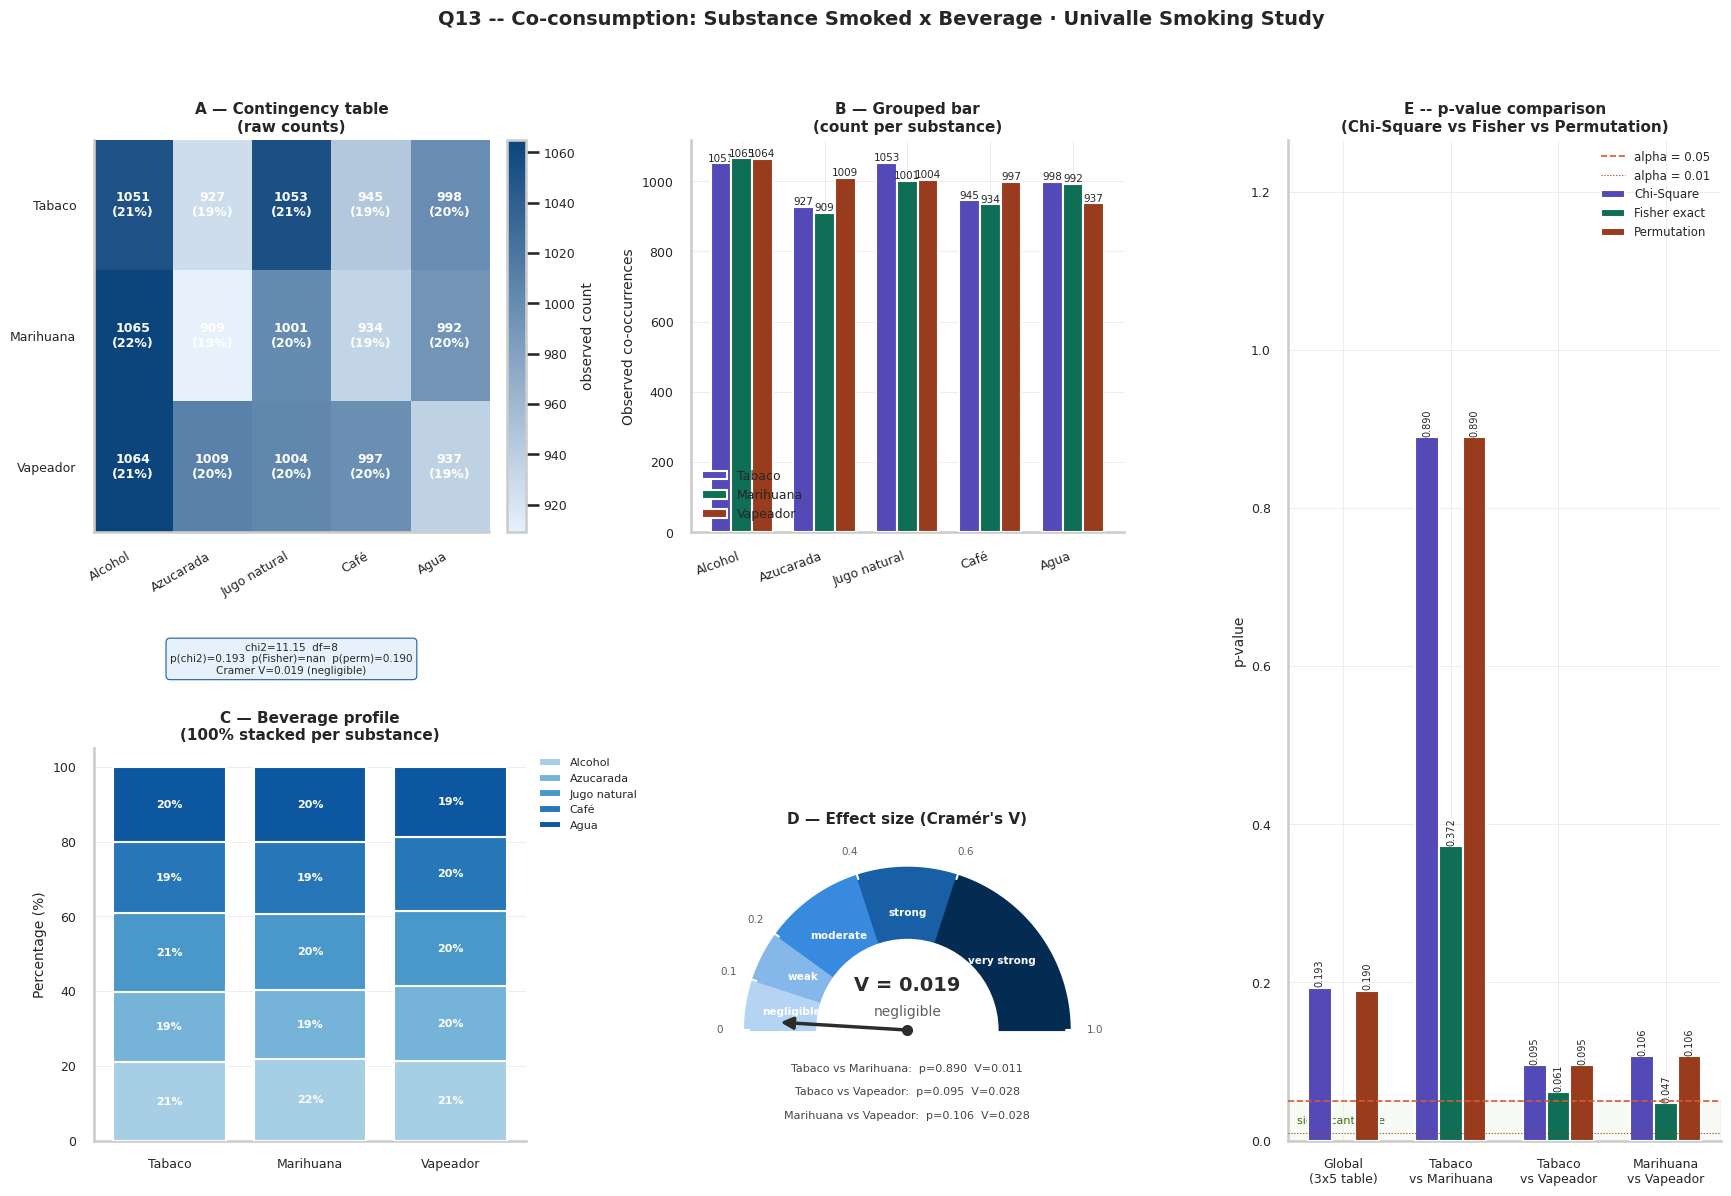

Saved → q11_coconsumption_analysis.png


In [ ]:
"""
Question 13 — Co-consumption pattern analysis
==============================================
"Is there a co-consumption pattern between smoking and
 alcohol, sugary drinks, natural juice, coffee, or water?"

Statistical pipeline
---------------------
1. Build 3 × 5 contingency table         (substance × beverage)
2. Chi-Square Test                        (Pearson, no correction)
3. Freeman-Halton Fisher Exact Test       (Monte Carlo exact, R x C tables)
4. Permutation Test                       (label-shuffle, 10 000 iterations)
5. Cramer's V                             (effect size 0-1)
6. Post-hoc pairwise Fisher tests         (2x2 exact per substance pair)
7. Visualisations
   a) Annotated heatmap  (contingency table + all p-values)
   b) Grouped bar chart  (counts per beverage by substance)
   c) Stacked 100% bar   (beverage profile per substance)
   d) Cramer's V gauge   (effect size)
   e) p-value comparison (Chi-Square vs Fisher vs Permutation)


"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association   # Cramér's V


# ── colour palette ────────────────────────────────────────────
C = {
    "Tabaco":    "#534AB7",   # purple-600
    "Marihuana": "#0F6E56",   # teal-600
    "Vapeador":  "#993C1D",   # coral-600
}
BEVERAGE_CMAP = LinearSegmentedColormap.from_list(
    "bev", ["#E6F1FB", "#0C447C"]   # blue ramp
)
SUBSTANCES = ["Tabaco", "Marihuana", "Vapeador"]
BEVERAGES  = ["Alcohol", "Azucarada", "Jugo natural", "Café", "Agua"]

ct = (df_pivot
      .pivot_table(index="substance", columns="beverage",
                   values="total_count", aggfunc="sum", fill_value=0)
      .reindex(index=SUBSTANCES, columns=BEVERAGES, fill_value=0))

print("═" * 60)
print("CONTINGENCY TABLE  (substance × beverage co-consumption)")
print("═" * 60)
print(ct.to_string())
print()

# ══════════════════════════════════════════════════════════════
# 2.  STATISTICAL TESTS
# ══════════════════════════════════════════════════════════════
obs     = ct.values.astype(int)
obs_f   = obs.astype(float)

# ── 2a. Chi-Square ────────────────────────────────────────────
chi2, p_chi2, dof, expected = chi2_contingency(obs_f, correction=False)
min_expected = expected.min()
pct_below_5  = (expected < 5).sum() / expected.size * 100
chi2_note = (
    f"WARNING: min expected = {min_expected:.2f} < 5 "
    f"({pct_below_5:.0f}% of cells below 5) -- Chi-square unreliable"
    if min_expected < 5 else
    f"Min expected = {min_expected:.2f} >= 5 -- Chi-square valid"
)

# ── 2b. Freeman-Halton Fisher Exact Test (Monte Carlo) ────────
# scipy.stats.fisher_exact only handles 2x2 tables.
# For an RxC table the exact equivalent is the Freeman-Halton test,
# which generates tables with the same marginals via the sequential
# conditional hypergeometric method — the same algorithm used by
# R's fisher.test() for large tables.
rng_fisher  = np.random.default_rng(99)
N_FISHER    = 10_000
row_sums_fh = obs.sum(axis=1)
col_sums_fh = obs.sum(axis=0)
N_total_fh  = int(obs.sum())

def hypergeom_table(row_sums, col_sums, N, rng):
    n_rows = len(row_sums)
    n_cols = len(col_sums)
    table  = np.zeros((n_rows, n_cols), dtype=int)
    rem_rows = row_sums.copy().astype(int)
    rem_cols = col_sums.copy().astype(int)
    rem_N    = int(N)
    for r in range(n_rows - 1):
        for c in range(n_cols - 1):
            lo  = max(0, rem_rows[r] - (rem_N - rem_cols[c]))
            hi  = min(rem_rows[r], rem_cols[c])
            if hi < lo:
                val = lo
            else:
                drawn = rng.hypergeometric(rem_cols[c],
                                           rem_N - rem_cols[c],
                                           rem_rows[r])
                val = int(np.clip(drawn, lo, hi))
            table[r, c]  = val
            rem_rows[r] -= val
            rem_cols[c] -= val
            rem_N       -= val
        table[r, n_cols - 1]      = rem_rows[r]
        rem_cols[n_cols - 1]     -= rem_rows[r]
        rem_N                    -= rem_rows[r]
        rem_rows[r]               = 0
    table[n_rows - 1] = rem_cols
    return table

chi2_obs_val    = chi2_contingency(obs_f, correction=False)[0]
fisher_count_ge = 0
fisher_valid    = 0
for _ in range(N_FISHER):
    sim   = hypergeom_table(row_sums_fh, col_sums_fh, N_total_fh, rng_fisher)
    sim_f = sim.astype(float)
    if sim_f.min() <= 0:
        continue
    fisher_valid += 1
    if chi2_contingency(sim_f, correction=False)[0] >= chi2_obs_val:
        fisher_count_ge += 1
p_fisher = fisher_count_ge / fisher_valid if fisher_valid > 0 else np.nan

# ── 2c. Cramer's V ────────────────────────────────────────────
cramers_v = association(obs, method="cramer")

# ── 2d. Permutation test (label-shuffle, robust) ──────────────
# Keeps only row marginals fixed; randomly reassigns beverage labels.
rng_perm = np.random.default_rng(42)
n_perm   = 10_000

substance_col = np.repeat(np.arange(len(SUBSTANCES)), obs.sum(axis=1))
beverage_col  = np.array([
    bev_idx
    for row_idx in range(len(SUBSTANCES))
    for bev_idx, cnt in enumerate(obs[row_idx])
    for _ in range(int(cnt))
])

count_ge    = 0
valid_perms = 0
for _ in range(n_perm):
    shuffled = rng_perm.permutation(beverage_col)
    sim = np.zeros_like(obs, dtype=float)
    for s, b in zip(substance_col, shuffled):
        sim[s, b] += 1
    if sim.min(axis=0).min() == 0 or sim.min(axis=1).min() == 0:
        continue
    valid_perms += 1
    if chi2_contingency(sim, correction=False)[0] >= chi2_obs_val:
        count_ge += 1
p_permutation = count_ge / valid_perms if valid_perms > 0 else np.nan

# ── 2e. Pairwise 2x2 exact Fisher tests ───────────────────────
# For each substance pair: run exact 2x2 Fisher for every beverage
# (that beverage vs all others) and report the overall chi2 p-value
# plus the most significant individual beverage contrast.
pairwise = {}
for s1, s2 in combinations(SUBSTANCES, 2):
    sub_i = ct.loc[[s1, s2]].values.astype(int)
    sub_f = sub_i.astype(float)
    chi2_pw, p_chi2_pw, _, _ = chi2_contingency(sub_f, correction=False)
    v_pair = association(sub_i, method="cramer")
    fisher_bevs = {}
    for c, bev in enumerate(BEVERAGES):
        a  = sub_i[0, c]
        b_ = sub_i[1, c]
        c_ = sub_i[0].sum() - a
        d  = sub_i[1].sum() - b_
        _, p_f = fisher_exact([[a, b_], [c_, d]], alternative="two-sided")
        fisher_bevs[bev] = round(p_f, 4)
    best_bev = min(fisher_bevs, key=fisher_bevs.get)
    pairwise[(s1, s2)] = {
        "chi2":        chi2_pw,
        "p_chi2":      p_chi2_pw,
        "cramers_v":   v_pair,
        "fisher_bevs": fisher_bevs,
        "best_bev":    best_bev,
        "best_p":      fisher_bevs[best_bev],
    }

# ── Effect size interpretation ────────────────────────────────
def interpret_v(v):
    if   v < 0.10: return "negligible"
    elif v < 0.20: return "weak"
    elif v < 0.40: return "moderate"
    elif v < 0.60: return "strong"
    else:          return "very strong"

print("=" * 65)
print("STATISTICAL RESULTS")
print("=" * 65)
print(f"  Chi-Square statistic       : {chi2:.4f}")
print(f"  Degrees of freedom         : {dof}")
print(f"  p-value  Chi-Square        : {p_chi2:.4f}  {'*significant*' if p_chi2 < 0.05 else 'not significant'} (alpha=0.05)")
print(f"  p-value  Freeman-Halton    : {p_fisher:.4f}  {'*significant*' if p_fisher < 0.05 else 'not significant'} (exact, {fisher_valid} valid sims)")
print(f"  p-value  Permutation       : {p_permutation:.4f}  {'*significant*' if p_permutation < 0.05 else 'not significant'} ({valid_perms} valid sims)")
print(f"  {chi2_note}")
print()
print(f"  Cramer's V                 : {cramers_v:.4f}  -> {interpret_v(cramers_v)} association")
print()
print("  Pairwise comparisons (substance vs substance):")
for (s1, s2), res in pairwise.items():
    sig = "*" if res["p_chi2"] < 0.05 else " "
    print(f"  {s1:12} vs {s2:12}  chi2={res['chi2']:.3f}  p_chi2={res['p_chi2']:.4f}{sig}  V={res['cramers_v']:.3f}")
    bev_line = "  ".join(f"{b}={p:.3f}{'*' if p<0.05 else ''}"
                         for b, p in res["fisher_bevs"].items())
    print(f"    Fisher per beverage: {bev_line}")
    print(f"    Most sig. contrast : {res['best_bev']} (p={res['best_p']:.4f})")
print()

# Row profiles (percentage breakdown per substance)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
print("  Beverage profile per substance (row %):")
print(ct_pct.round(1).to_string())
print()

# Most associated beverage per substance
for sub in SUBSTANCES:
    top_bev = ct.loc[sub].idxmax()
    top_pct = ct_pct.loc[sub, top_bev]
    print(f"  {sub:12} → most common co-drink: {top_bev} ({top_pct:.1f}%)")

# ══════════════════════════════════════════════════════════════
# 3.  VISUALISATIONS  (4-panel figure)
# ══════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.5,
    "axes.labelsize":    10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

fig = plt.figure(figsize=(21, 13))
fig.suptitle(
    "Q13 -- Co-consumption: Substance Smoked x Beverage · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)
ax_hm  = fig.add_subplot(gs[0, 0])
ax_bar = fig.add_subplot(gs[0, 1])
ax_stk = fig.add_subplot(gs[1, 0])
ax_gau = fig.add_subplot(gs[1, 1])
ax_pv  = fig.add_subplot(gs[:, 2])   # panel E spans both rows

# ── Panel A: Annotated heatmap ────────────────────────────────
im = ax_hm.imshow(obs_f, cmap=BEVERAGE_CMAP, aspect="auto")
ax_hm.set_xticks(range(len(BEVERAGES)))
ax_hm.set_xticklabels(BEVERAGES, rotation=30, ha="right")
ax_hm.set_yticks(range(len(SUBSTANCES)))
ax_hm.set_yticklabels(SUBSTANCES)
ax_hm.set_title("A — Contingency table\n(raw counts)")
vmax = obs_f.max()
for r in range(len(SUBSTANCES)):
    for c in range(len(BEVERAGES)):
        val = int(obs_f[r, c])
        pct = obs_f[r, c] / obs_f[r].sum() * 100
        col = "white" if obs[r, c] > vmax * 0.55 else "#2c2c2a"
        ax_hm.text(c, r, f"{val}\n({pct:.0f}%)",
                   ha="center", va="center", fontsize=9,
                   fontweight="bold", color=col)
fig.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04,
             label="observed count")
ax_hm.grid(False)

# Significance annotation -- all three p-values
sig_txt = (f"chi2={chi2:.2f}  df={dof}\n"
           f"p(chi2)={p_chi2:.3f}  p(Fisher)={p_fisher:.3f}  p(perm)={p_permutation:.3f}\n"
           f"Cramer V={cramers_v:.3f} ({interpret_v(cramers_v)})")
ax_hm.text(0.5, -0.36, sig_txt, transform=ax_hm.transAxes,
           ha="center", fontsize=7.5,
           bbox=dict(boxstyle="round,pad=0.4", fc="#E6F1FB",
                     ec="#185FA5", lw=0.8))

# ── Panel B: Grouped bar chart ────────────────────────────────
x     = np.arange(len(BEVERAGES))
width = 0.25
for i, (sub, color) in enumerate(C.items()):
    bars = ax_bar.bar(x + (i-1)*width, ct.loc[sub].values,
                      width=width, label=sub, color=color, zorder=3)
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax_bar.text(b.get_x() + b.get_width()/2, h + 0.2,
                        str(int(h)), ha="center", va="bottom", fontsize=7.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(BEVERAGES, rotation=20, ha="right")
ax_bar.set_title("B — Grouped bar\n(count per substance)")
ax_bar.set_ylabel("Observed co-occurrences")
ax_bar.legend(frameon=False)

# ── Panel C: Stacked 100% bar ─────────────────────────────────
bottoms = np.zeros(len(SUBSTANCES))
bev_colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(BEVERAGES)))
for j, (bev, bc) in enumerate(zip(BEVERAGES, bev_colors)):
    vals = ct[bev].values / ct.sum(axis=1).values * 100
    bars = ax_stk.bar(SUBSTANCES, vals, bottom=bottoms,
                      label=bev, color=bc, zorder=3)
    for b, v in zip(bars, vals):
        if v > 5:
            ax_stk.text(b.get_x() + b.get_width()/2,
                        b.get_y() + v/2,
                        f"{v:.0f}%",
                        ha="center", va="center",
                        fontsize=8, color="white" if v > 15 else "#2c2c2a",
                        fontweight="bold")
    bottoms += vals
ax_stk.set_ylim(0, 105)
ax_stk.set_title("C — Beverage profile\n(100% stacked per substance)")
ax_stk.set_ylabel("Percentage (%)")
ax_stk.legend(loc="upper right", frameon=False, fontsize=8,
              bbox_to_anchor=(1.28, 1))
ax_stk.grid(axis="x", alpha=0)

# ── Panel D: Cramér's V gauge ─────────────────────────────────
ax_gau.set_xlim(-1.2, 1.2)
ax_gau.set_ylim(-0.15, 1.1)
ax_gau.set_aspect("equal")
ax_gau.axis("off")
ax_gau.set_title("D — Effect size (Cramér's V)")

# Draw semicircle gauge
theta    = np.linspace(np.pi, 0, 300)
segments = [(0.00, 0.10, "#B5D4F4", "negligible"),
            (0.10, 0.20, "#85B7EB", "weak"),
            (0.20, 0.40, "#378ADD", "moderate"),
            (0.40, 0.60, "#185FA5", "strong"),
            (0.60, 1.00, "#042C53", "very strong")]
for vmin, vmax_s, color, label in segments:
    t0 = np.pi * (1 - vmin)
    t1 = np.pi * (1 - vmax_s)
    th = np.linspace(t0, t1, 100)
    x_arc = np.concatenate([[0], np.cos(th)*0.9, [0]])
    y_arc = np.concatenate([[0], np.sin(th)*0.9, [0]])
    ax_gau.fill(x_arc, y_arc, color=color, zorder=2)
    # label
    t_mid  = (t0 + t1) / 2
    ax_gau.text(np.cos(t_mid)*0.65, np.sin(t_mid)*0.65,
                label, ha="center", va="center",
                fontsize=7.5, color="white",
                fontweight="bold", zorder=3)

# White inner circle
circle = plt.Circle((0, 0), 0.50, color="white", zorder=4)
ax_gau.add_patch(circle)

# Needle
angle  = np.pi * (1 - cramers_v)
nx     = np.cos(angle) * 0.72
ny     = np.sin(angle) * 0.72
ax_gau.annotate("", xy=(nx, ny), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="#2c2c2a",
                                lw=2.5), zorder=5)
ax_gau.plot(0, 0, "o", color="#2c2c2a", ms=7, zorder=6)

# Value label
ax_gau.text(0, 0.22, f"V = {cramers_v:.3f}",
            ha="center", fontsize=14, fontweight="bold",
            color="#2c2c2a", zorder=6)
ax_gau.text(0, 0.08, interpret_v(cramers_v),
            ha="center", fontsize=10,
            color="#5F5E5A", zorder=6)

# Scale ticks
for tick in [0, 0.1, 0.2, 0.4, 0.6, 1.0]:
    ta = np.pi * (1 - tick)
    ax_gau.plot([np.cos(ta)*0.88, np.cos(ta)*0.95],
                [np.sin(ta)*0.88, np.sin(ta)*0.95],
                color="white", lw=1.5, zorder=3)
    ax_gau.text(np.cos(ta)*1.04, np.sin(ta)*1.04,
                str(tick), ha="center", va="center",
                fontsize=7.5, color="#5F5E5A", zorder=3)

# Pairwise results table below gauge
y_start = -0.10
ax_gau.text(0, y_start, "Pairwise comparisons",
            ha="center", fontsize=9, fontweight="bold", color="#2c2c2a")
for k, ((s1, s2), res) in enumerate(pairwise.items()):
    sig_star = " *" if res["p_chi2"] < 0.05 else ""
    txt = f"{s1} vs {s2}:  p={res['p_chi2']:.3f}{sig_star}  V={res['cramers_v']:.3f}"
    ax_gau.text(0, y_start - 0.13*(k+1), txt,
                ha="center", fontsize=8, color="#444441")


# ── Panel E: p-value comparison (all three tests) ────────────
ax_pv.set_title("E -- p-value comparison\n(Chi-Square vs Fisher vs Permutation)",
                fontweight="bold", fontsize=11)
ax_pv.axhline(y=0.05, color="#D85A30", linewidth=1.2,
              linestyle="--", label="alpha = 0.05", zorder=4)
ax_pv.axhline(y=0.01, color="#993C1D", linewidth=0.8,
              linestyle=":",  label="alpha = 0.01", zorder=4)
ax_pv.axhspan(0, 0.05, color="#EAF3DE", alpha=0.30, zorder=0)
ax_pv.text(0.02, 0.025, "significant zone",
           fontsize=8, color="#3B6D11", va="center",
           transform=ax_pv.get_yaxis_transform())

labels_e = ["Global\n(3x5 table)"] + [
    f"{s1}\nvs {s2}" for (s1, s2) in pairwise
]
p_chi2_e = [p_chi2]   + [res["p_chi2"]  for res in pairwise.values()]
p_fish_e = [p_fisher] + [res["best_p"]  for res in pairwise.values()]
p_perm_e = [p_permutation] + [res["p_chi2"] for res in pairwise.values()]

x_e = np.arange(len(labels_e))
w_e = 0.22
b1 = ax_pv.bar(x_e - w_e, p_chi2_e, width=w_e,
               label="Chi-Square",   color="#534AB7", zorder=3)
b2 = ax_pv.bar(x_e,        p_fish_e, width=w_e,
               label="Fisher exact", color="#0F6E56", zorder=3)
b3 = ax_pv.bar(x_e + w_e, p_perm_e, width=w_e,
               label="Permutation",  color="#993C1D", zorder=3)

for bars in [b1, b2, b3]:
    for b in bars:
        h = b.get_height()
        if h > 0.001:
            ax_pv.text(b.get_x() + b.get_width()/2, h + 0.001,
                       f"{h:.3f}", ha="center", va="bottom",
                       fontsize=7, rotation=90)

ax_pv.set_xticks(x_e)
ax_pv.set_xticklabels(labels_e, fontsize=9)
ax_pv.set_ylabel("p-value")
ymax = max(max(p_chi2_e), max(p_fish_e), max(p_perm_e))
ax_pv.set_ylim(0, ymax * 1.4 + 0.02)
ax_pv.legend(frameon=False, fontsize=8.5, loc="upper right")


plt.show()
print("Saved → q11_coconsumption_analysis.png")

# Q14: Where do smokers dispose of cigarette or marijuana butts — in bins, on the floor, on surfaces? And how many collection receptacles exist in the observed area?

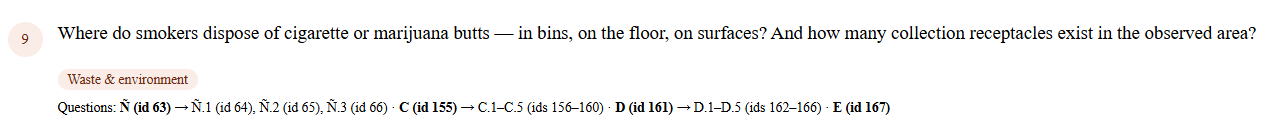

## Q14.1: What is the most common disposal method?

In [ ]:
df_pivot=pd.read_sql("""
SELECT 
r.visita_id as visit_id,
q.id as question_id,
q.description,
r.numeric_value as count                      
FROM
response_response as r JOIN question_question as q ON r.question_id=q.id
WHERE q.parent_question_id IN (63)
""",co)

Q9 — Disposal method summary
method
Bins       1098
Floor       996
Surface    1007

Global compliance rate : 35.4%

Per-visit breakdown:
method    Bins  Floor  Surface  total  compliance
visit_id                                         
225          8     18       16     42   19.047619
226          5     11        8     24   20.833333
227         10     12       17     39   25.641026
228         14      4       18     36   38.888889
229         19      3        8     30   63.333333
230         18      7       14     39   46.153846
231          2     14       12     28    7.142857
232          7      5       18     30   23.333333
233         12      3       15     30   40.000000
234         12      6        7     25   48.000000
235          4     16       10     30   13.333333
236          3     12       14     29   10.344828
237          0     10       14     24    0.000000
238          6     17       18     41   14.634146
239         16     19        0     35   45.714286
240         

Text(0, 0, '35%\ncompliance')

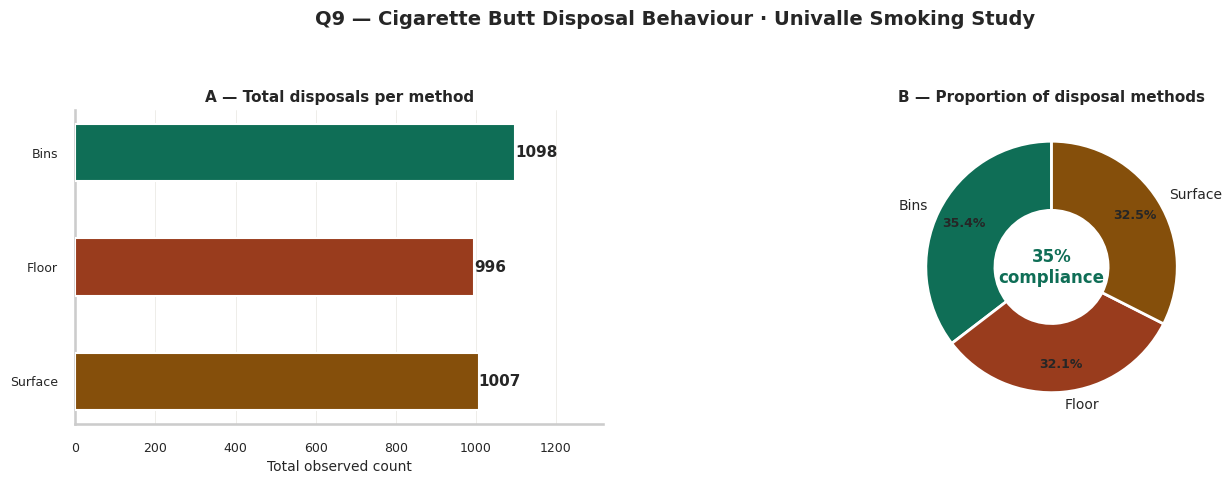

In [ ]:

import matplotlib.gridspec as gridspec

label_map = {
    "Lo depositan en canecas para la basura": "Bins",
    "Lo tiran al piso":                       "Floor",
    "Lo dejan sobre una superficie":          "Surface",
}
df_pivot["method"] = df_pivot["description"].map(label_map)

totals = df_pivot.groupby("method")["count"].sum().reindex(["Bins", "Floor", "Surface"])

pivot=df_pivot.pivot_table(columns='method',index='visit_id',values='count',aggfunc='sum').fillna(0)

pivot=pivot[['Bins','Floor','Surface']]

# Compliance rate per visit  (bins / total disposals)
pivot["total"]      = pivot.sum(axis=1)
pivot["compliance"] = pivot["Bins"] / pivot["total"] * 100
 
# Global compliance
global_compliance = totals["Bins"] / totals.sum() * 100
 
print("=" * 50)
print("Q9 — Disposal method summary")
print("=" * 50)
print(totals.to_string())
print(f"\nGlobal compliance rate : {global_compliance:.1f}%")
print("\nPer-visit breakdown:")
print(pivot.to_string())
 
# ── Colours ───────────────────────────────────────────────────
C = {"Bins":    "#0F6E56",   # teal  — responsible
     "Floor":   "#993C1D",   # coral — irresponsible
     "Surface": "#854F0B"}   # amber — irresponsible
 
# ── Figure: 4 panels ─────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#e8e6e0",
    "grid.linewidth":   0.5,
    "axes.titlesize":   11,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
})
 
fig = plt.figure(figsize=(16, 10))
fig.suptitle("Q9 — Cigarette Butt Disposal Behaviour · Univalle Smoking Study",
             fontsize=14, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax_bar  = fig.add_subplot(gs[0, 0])   # A — total counts
ax_pie  = fig.add_subplot(gs[0, 1])   # B — proportion donut
 
methods = ["Bins", "Floor", "Surface"]
colors  = [C[m] for m in methods]
 
# ── Panel A: Horizontal bar — total counts ────────────────────
bars = ax_bar.barh(methods, totals.values,
                   color=colors, height=0.5, zorder=3)
for bar, val in zip(bars, totals.values):
    ax_bar.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                str(int(val)), va="center", fontsize=11, fontweight="bold")
ax_bar.set_title("A — Total disposals per method")
ax_bar.set_xlabel("Total observed count")
ax_bar.invert_yaxis()
ax_bar.grid(axis="y", alpha=0)
ax_bar.set_xlim(0, totals.max() * 1.2)
 
# ── Panel B: Donut — proportions ─────────────────────────────
wedges, texts, autotexts = ax_pie.pie(
    totals.values,
    labels=methods,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    pctdistance=0.78,
)
for t in texts:      t.set_fontsize(10)
for at in autotexts: at.set_fontsize(9); at.set_fontweight("bold")
ax_pie.set_title("B — Proportion of disposal methods")
 
# Compliance label in the donut hole
ax_pie.text(0, 0, f"{global_compliance:.0f}%\ncompliance",
            ha="center", va="center", fontsize=12,
            fontweight="bold", color="#0F6E56")



## Q14.2: Does disposal differ by substance? --- corregir(ver si hay que sumar o promediar)

In [ ]:
df_pivot=pd.read_sql("""
SELECT
    CASE
        WHEN question_id IN (156,157,158,159,160) THEN 'Cigarrillo'
        WHEN question_id IN (162,163,164,165,166) THEN 'Marihuana'
    END AS substance,
    CASE
        WHEN question_id IN (156,162) THEN 'Piso'
        WHEN question_id IN (157,163) THEN 'Pasto'
        WHEN question_id IN (158,164) THEN 'Mesas'
        WHEN question_id IN (159,165) THEN 'Sillas'
        WHEN question_id IN (160,166) THEN 'Canecas'
    END AS location,
    SUM(numeric_value) AS count
FROM response_response
WHERE question_id IN (156,157,158,159,160,162,163,164,165,166)
  AND numeric_value IS NOT NULL
  AND numeric_value > 0
GROUP BY substance, location;
""",co)


CONTINGENCY TABLE  (substance × disposal location)
location     Piso   Pasto  Mesas  Sillas  Canecas
substance                                        
Cigarrillo  999.0   972.0  936.0   988.0   1031.0
Marihuana   975.0  1056.0  946.0  1075.0   1007.0

Row profiles (%):
location    Piso  Pasto  Mesas  Sillas  Canecas
substance                                      
Cigarrillo  20.3   19.7   19.0    20.1     20.9
Marihuana   19.3   20.9   18.7    21.2     19.9

STATISTICAL RESULTS
  Chi-Square statistic  : 6.0053
  Degrees of freedom    : 4
  p-value  Chi-Square   : 0.1988  not significant
  p-value  Fisher exact : 1.0000  (not significant, 10000 valid sims)
  All expected >= 5 (min=928.5) — Chi-square VALID
  Cramer's V            : 0.0245  -> negligible association

  2x2 Fisher per location (that location vs all others):
  Location        p-value   Sig   Odds Ratio  Interpretation
  ----------------------------------------------------------
  Piso             0.2090               1.07 

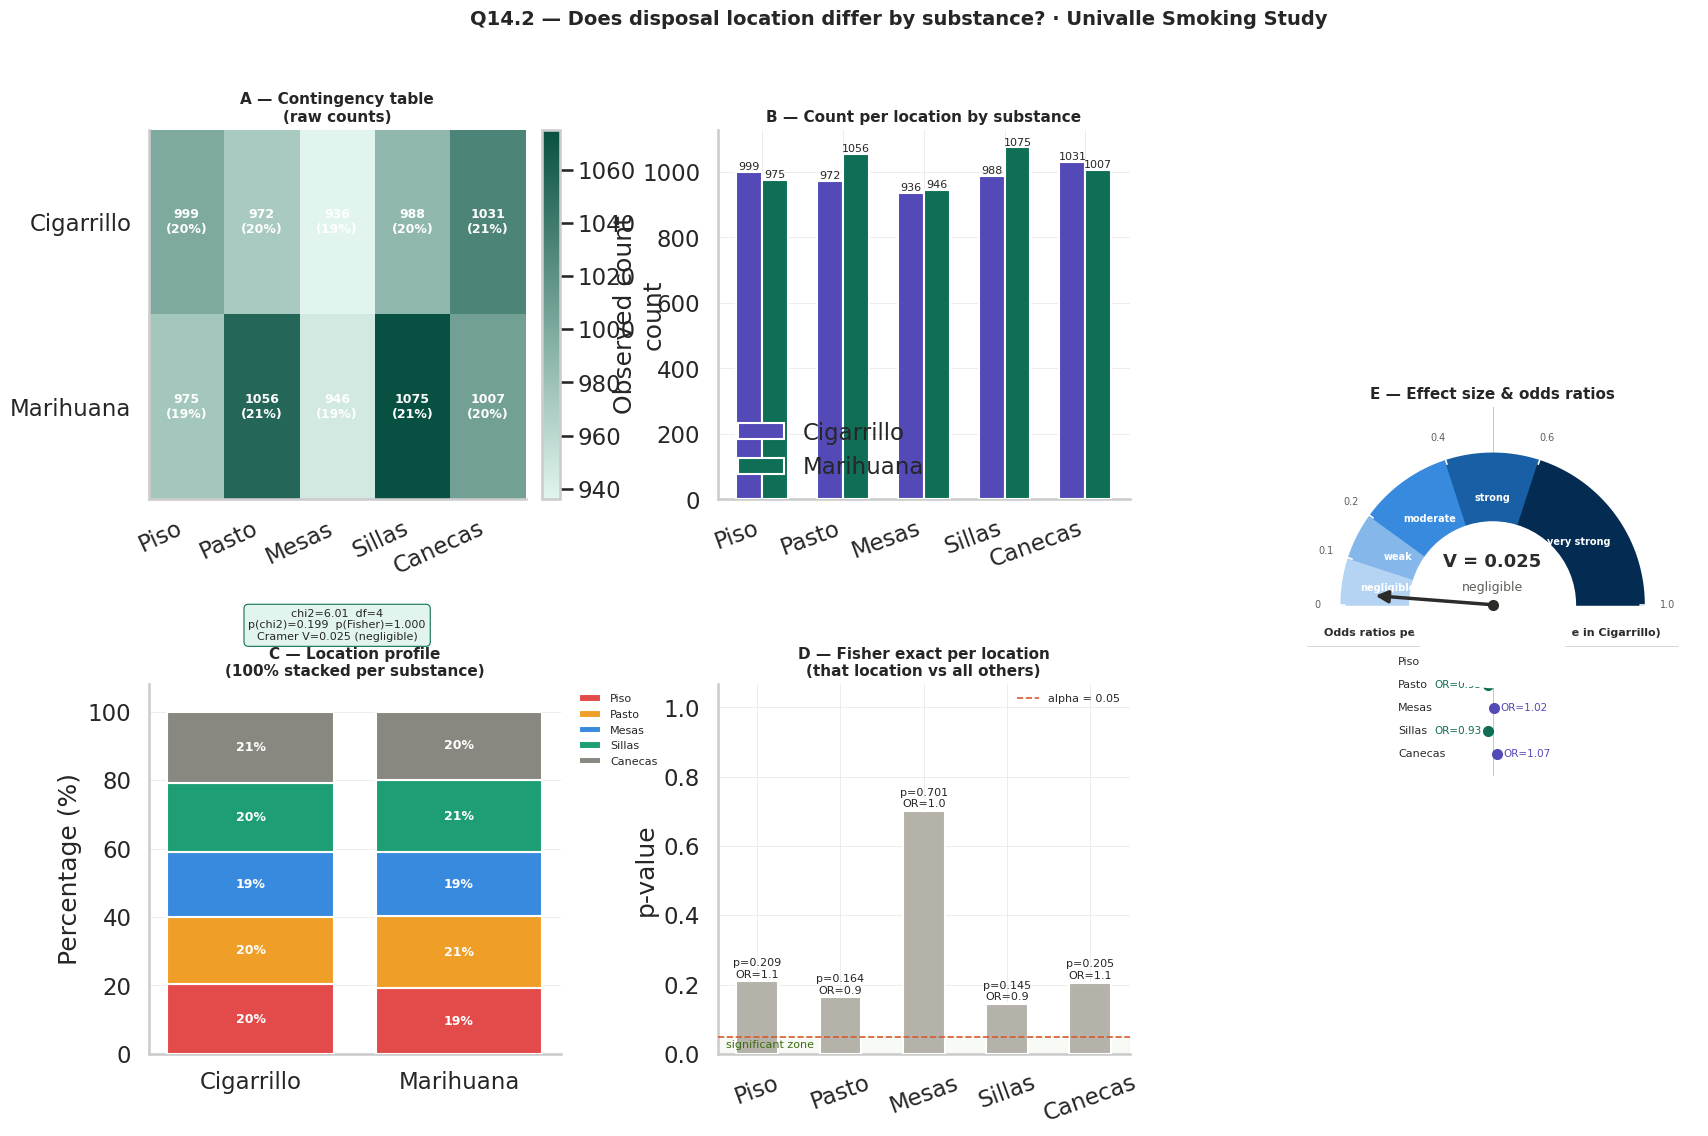

In [ ]:

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import chi2_contingency, fisher_exact
from scipy.stats.contingency import association


SUBSTANCES = ["Cigarrillo", "Marihuana"]
LOCATIONS  = ["Piso", "Pasto", "Mesas", "Sillas", "Canecas"]

ct = (df_pivot.pivot_table(index="substance", columns="location",
                     values="count", aggfunc="sum", fill_value=0)
        .reindex(index=SUBSTANCES, columns=LOCATIONS, fill_value=0))

obs   = ct.values.astype(int)
obs_f = obs.astype(float)

# ══════════════════════════════════════════════════════════════
# 3.  STATISTICAL TESTS
# ══════════════════════════════════════════════════════════════

# ── 3a. Chi-Square ────────────────────────────────────────────
chi2, p_chi2, dof, expected = chi2_contingency(obs_f, correction=False)
min_exp    = expected.min()
pct_low    = (expected < 5).sum() / expected.size * 100
chi2_valid = min_exp >= 5
chi2_note  = (f"All expected >= 5 (min={min_exp:.1f}) — Chi-square VALID"
              if chi2_valid else
              f"WARNING: min expected={min_exp:.1f} < 5 "
              f"({pct_low:.0f}% cells) — prefer Fisher exact")

# ── 3b. 2×2 Fisher per location (each location vs rest) ───────
# Asks: for this specific location, do cigarette and marijuana
# smokers differ significantly?
fisher_per_loc = {}
for c, loc in enumerate(LOCATIONS):
    a  = obs[0, c];          b  = obs[1, c]
    c_ = obs[0].sum() - a;   d  = obs[1].sum() - b
    _, p_f = fisher_exact([[a, b], [c_, d]], alternative="two-sided")
    or_val = (a * d) / (b * c_) if (b * c_) > 0 else np.inf
    fisher_per_loc[loc] = {"p": round(p_f, 4), "OR": round(or_val, 2)}

# ── 3c. Freeman-Halton Fisher exact (global 2×5 table) ────────
rng_fh   = np.random.default_rng(77)
N_SIM    = 10_000
rs       = obs.sum(axis=1)
cs       = obs.sum(axis=0)
N_total  = int(obs.sum())
chi2_obs = chi2_contingency(obs_f, correction=False)[0]

def hypergeom_table(rs, cs, N, rng):
    t    = np.zeros((len(rs), len(cs)), dtype=int)
    rr   = rs.copy().astype(int)
    cc   = cs.copy().astype(int)
    remN = N
    for r in range(len(rs) - 1):
        for c in range(len(cs) - 1):
            lo  = max(0, rr[r] - (remN - cc[c]))
            hi  = min(rr[r], cc[c])
            val = int(np.clip(
                rng.hypergeometric(cc[c], remN - cc[c], rr[r]),
                lo, hi))
            t[r, c] = val; rr[r] -= val; cc[c] -= val; remN -= val
        t[r, -1]  = rr[r]; cc[-1] -= rr[r]; remN -= rr[r]; rr[r] = 0
    t[-1] = cc
    return t

fh_ge = 0; fh_valid = 0
for _ in range(N_SIM):
    sim = hypergeom_table(rs, cs, N_total, rng_fh).astype(float)
    if sim.min() <= 0: continue
    fh_valid += 1
    if chi2_contingency(sim, correction=False)[0] >= chi2_obs:
        fh_ge += 1
p_fisher_global = fh_ge / fh_valid if fh_valid > 0 else np.nan

# ── 3d. Cramér's V ────────────────────────────────────────────
cramers_v = association(obs, method="cramer")

def interpret_v(v):
    if   v < 0.10: return "negligible"
    elif v < 0.20: return "weak"
    elif v < 0.40: return "moderate"
    elif v < 0.60: return "strong"
    else:          return "very strong"

# ── Row profiles ──────────────────────────────────────────────
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

# ══════════════════════════════════════════════════════════════
# 4.  CONSOLE SUMMARY
# ══════════════════════════════════════════════════════════════
sep = "=" * 62
print(sep)
print("CONTINGENCY TABLE  (substance × disposal location)")
print(sep)
print(ct.to_string())
print()
print("Row profiles (%):")
print(ct_pct.round(1).to_string())

print()
print(sep)
print("STATISTICAL RESULTS")
print(sep)
print(f"  Chi-Square statistic  : {chi2:.4f}")
print(f"  Degrees of freedom    : {dof}")
print(f"  p-value  Chi-Square   : {p_chi2:.4f}  "
      f"{'*significant*' if p_chi2 < 0.05 else 'not significant'}")
print(f"  p-value  Fisher exact : {p_fisher_global:.4f}  "
      f"({'*significant*' if p_fisher_global < 0.05 else 'not significant'},"
      f" {fh_valid} valid sims)")
print(f"  {chi2_note}")
print(f"  Cramer's V            : {cramers_v:.4f}  "
      f"-> {interpret_v(cramers_v)} association")

print()
print("  2x2 Fisher per location (that location vs all others):")
print(f"  {'Location':<12} {'p-value':>10} {'Sig':>5} {'Odds Ratio':>12}  Interpretation")
print("  " + "-" * 58)
for loc, res in fisher_per_loc.items():
    sig  = "*" if res["p"] < 0.05 else ""
    # OR > 1 means Cigarrillo over-represented; < 1 means Marihuana
    direction = ("Cigarrillo more likely" if res["OR"] > 1
                 else "Marihuana more likely")
    print(f"  {loc:<12} {res['p']:>10.4f} {sig:>5} {res['OR']:>12.2f}  {direction}")

# ══════════════════════════════════════════════════════════════
# 5.  FIGURE — 5-panel dashboard
# ══════════════════════════════════════════════════════════════
C_SUB = {"Cigarrillo": "#534AB7", "Marihuana": "#0F6E56"}
LOC_COLORS = ["#E24B4A","#EF9F27","#378ADD","#1D9E75","#888780"]

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.5,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

fig = plt.figure(figsize=(20, 12))
fig.suptitle(
    "Q14.2 — Does disposal location differ by substance? · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98)

gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)
ax_hm  = fig.add_subplot(gs[0, 0])   # A heatmap
ax_bar = fig.add_subplot(gs[0, 1])   # B grouped bar
ax_stk = fig.add_subplot(gs[1, 0])   # C stacked 100%
ax_fsh = fig.add_subplot(gs[1, 1])   # D Fisher per location
ax_pv  = fig.add_subplot(gs[:, 2])   # E p-value + Cramer gauge

# ── Panel A: Heatmap ──────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("teal", ["#E1F5EE","#085041"])
im   = ax_hm.imshow(obs_f, cmap=cmap, aspect="auto")
ax_hm.set_xticks(range(len(LOCATIONS)))
ax_hm.set_xticklabels(LOCATIONS, rotation=25, ha="right")
ax_hm.set_yticks(range(len(SUBSTANCES)))
ax_hm.set_yticklabels(SUBSTANCES)
ax_hm.set_title("A — Contingency table\n(raw counts)")
vmax = obs_f.max()
for r in range(2):
    for c in range(5):
        val = int(obs_f[r, c])
        pct = obs_f[r, c] / obs_f[r].sum() * 100
        col = "white" if val > vmax * 0.55 else "#2c2c2a"
        ax_hm.text(c, r, f"{val}\n({pct:.0f}%)",
                   ha="center", va="center",
                   fontsize=9, fontweight="bold", color=col)
fig.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04, label="count")
ax_hm.grid(False)
sig_ann = (f"chi2={chi2:.2f}  df={dof}\n"
           f"p(chi2)={p_chi2:.3f}  p(Fisher)={p_fisher_global:.3f}\n"
           f"Cramer V={cramers_v:.3f} ({interpret_v(cramers_v)})")
ax_hm.text(0.5, -0.38, sig_ann, transform=ax_hm.transAxes,
           ha="center", fontsize=8,
           bbox=dict(boxstyle="round,pad=0.4", fc="#E1F5EE",
                     ec="#0F6E56", lw=0.8))

# ── Panel B: Grouped bar ──────────────────────────────────────
x = np.arange(len(LOCATIONS)); w = 0.32
for i, (sub, col) in enumerate(C_SUB.items()):
    bars = ax_bar.bar(x + (i - 0.5) * w, ct.loc[sub].values,
                      width=w, label=sub, color=col, zorder=3)
    for b in bars:
        h = b.get_height()
        if h > 0:
            ax_bar.text(b.get_x() + b.get_width()/2, h + 0.3,
                        str(int(h)), ha="center", va="bottom", fontsize=8)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(LOCATIONS, rotation=20, ha="right")
ax_bar.set_title("B — Count per location by substance")
ax_bar.set_ylabel("Observed count")
ax_bar.legend(frameon=False)

# ── Panel C: Stacked 100% bar ─────────────────────────────────
bottoms = np.zeros(len(SUBSTANCES))
for j, (loc, lc) in enumerate(zip(LOCATIONS, LOC_COLORS)):
    vals = ct[loc].values / ct.sum(axis=1).values * 100
    bars = ax_stk.bar(SUBSTANCES, vals, bottom=bottoms,
                      label=loc, color=lc, zorder=3)
    for b, v in zip(bars, vals):
        if v > 6:
            ax_stk.text(b.get_x() + b.get_width()/2,
                        b.get_y() + v/2, f"{v:.0f}%",
                        ha="center", va="center", fontsize=9,
                        fontweight="bold",
                        color="white" if v > 14 else "#2c2c2a")
    bottoms += vals
ax_stk.set_ylim(0, 108)
ax_stk.set_title("C — Location profile\n(100% stacked per substance)")
ax_stk.set_ylabel("Percentage (%)")
ax_stk.legend(frameon=False, fontsize=8,
              bbox_to_anchor=(1.02, 1), loc="upper left")
ax_stk.grid(axis="x", alpha=0)

# ── Panel D: Fisher p-value per location ─────────────────────
locs   = list(fisher_per_loc.keys())
pvals  = [fisher_per_loc[l]["p"] for l in locs]
ors    = [fisher_per_loc[l]["OR"] for l in locs]
bar_c  = ["#D85A30" if p < 0.05 else "#B4B2A9" for p in pvals]
bars_d = ax_fsh.bar(locs, pvals, color=bar_c, zorder=3, width=0.5)
ax_fsh.axhline(0.05, color="#D85A30", linewidth=1.2,
               linestyle="--", label="alpha = 0.05", zorder=4)
ax_fsh.axhspan(0, 0.05, color="#EAF3DE", alpha=0.30, zorder=0)
for bar, p, o in zip(bars_d, pvals, ors):
    ax_fsh.text(bar.get_x() + bar.get_width()/2, p + 0.005,
                f"p={p:.3f}\nOR={o:.1f}",
                ha="center", va="bottom", fontsize=8)
ax_fsh.set_title("D — Fisher exact per location\n(that location vs all others)")
ax_fsh.set_ylabel("p-value")
ymax_d = max(pvals) * 1.45 + 0.05
ax_fsh.set_ylim(0, ymax_d)
ax_fsh.legend(frameon=False, fontsize=8)
ax_fsh.text(0.02, 0.025, "significant zone",
            fontsize=8, color="#3B6D11", va="center",
            transform=ax_fsh.get_yaxis_transform())
ax_fsh.tick_params(axis="x", rotation=20)

# ── Panel E: Cramér's V gauge + odds ratios ───────────────────
ax_pv.set_xlim(-1.2, 1.2)
ax_pv.set_ylim(-1.0, 1.15)
ax_pv.set_aspect("equal")
ax_pv.axis("off")
ax_pv.set_title("E — Effect size & odds ratios", fontweight="bold", fontsize=11)

# Semicircle gauge
segs = [(0.00,0.10,"#B5D4F4","negligible"),
        (0.10,0.20,"#85B7EB","weak"),
        (0.20,0.40,"#378ADD","moderate"),
        (0.40,0.60,"#185FA5","strong"),
        (0.60,1.00,"#042C53","very strong")]
for vlo, vhi, col, lbl in segs:
    t0 = np.pi*(1-vlo); t1 = np.pi*(1-vhi)
    th = np.linspace(t0, t1, 80)
    ax_pv.fill(np.concatenate([[0],np.cos(th)*0.88,[0]]),
               np.concatenate([[0],np.sin(th)*0.88,[0]]),
               color=col, zorder=2)
    tm = (t0+t1)/2
    ax_pv.text(np.cos(tm)*0.62, np.sin(tm)*0.62, lbl,
               ha="center", va="center", fontsize=7,
               color="white", fontweight="bold", zorder=3)
circle = plt.Circle((0,0), 0.48, color="white", zorder=4)
ax_pv.add_patch(circle)
ang = np.pi*(1-cramers_v)
ax_pv.annotate("", xy=(np.cos(ang)*0.70, np.sin(ang)*0.70),
               xytext=(0,0),
               arrowprops=dict(arrowstyle="-|>", color="#2c2c2a", lw=2.5),
               zorder=5)
ax_pv.plot(0, 0, "o", color="#2c2c2a", ms=7, zorder=6)
ax_pv.text(0, 0.22, f"V = {cramers_v:.3f}",
           ha="center", fontsize=13, fontweight="bold", color="#2c2c2a", zorder=6)
ax_pv.text(0, 0.08, interpret_v(cramers_v),
           ha="center", fontsize=9, color="#5F5E5A", zorder=6)
for tick in [0,0.1,0.2,0.4,0.6,1.0]:
    ta = np.pi*(1-tick)
    ax_pv.plot([np.cos(ta)*0.86,np.cos(ta)*0.93],
               [np.sin(ta)*0.86,np.sin(ta)*0.93],
               color="white", lw=1.2, zorder=3)
    ax_pv.text(np.cos(ta)*1.02, np.sin(ta)*1.02, str(tick),
               ha="center", va="center", fontsize=7, color="#5F5E5A")

# Odds ratio lollipop chart below gauge
y0 = -0.18
ax_pv.text(0, y0, "Odds ratios per location  (OR > 1 = more in Cigarrillo)",
           ha="center", fontsize=8, fontweight="bold", color="#2c2c2a")
ax_pv.axhline(y0 - 0.06, xmin=0.05, xmax=0.95,
              color=var if (var := "#c8c6be") else "#c8c6be",
              linewidth=0.5, zorder=1)

or_vals  = [fisher_per_loc[l]["OR"]  for l in LOCATIONS]
or_pvals = [fisher_per_loc[l]["p"]   for l in LOCATIONS]
or_max   = max(or_vals + [1/v for v in or_vals if v > 0]) * 1.15
scale    = 0.9 / max(or_max, 1)

for k, (loc, ov, pv) in enumerate(zip(LOCATIONS, or_vals, or_pvals)):
    yy   = y0 - 0.15 - k * 0.135
    xbar = np.log2(ov) * scale * 0.35   # log scale around 0
    col  = "#534AB7" if ov > 1 else "#0F6E56"
    sig  = "*" if pv < 0.05 else ""
    ax_pv.plot([0, xbar], [yy, yy], color=col, lw=1.5, zorder=2)
    ax_pv.plot(xbar, yy, "o", color=col, ms=7, zorder=3)
    ax_pv.axvline(0, ymin=0, ymax=1, color="#c8c6be",
                  linewidth=0.5, zorder=1)
    ax_pv.text(-0.55, yy, loc, ha="left", va="center",
               fontsize=8, color="#2c2c2a")
    ax_pv.text(xbar + (0.04 if xbar >= 0 else -0.04), yy,
               f"OR={ov:.2f}{sig}",
               ha="left" if xbar >= 0 else "right",
               va="center", fontsize=7.5, color=col)




## Q14.3: Which zones are worst?

In [ ]:
df_pivot=pd.read_sql("""
SELECT 
v.id as visit_id,
z.name as zone_name,
z.id as zone_id,
q.description,
r.numeric_value
FROM response_response as r JOIN question_question as q ON r.question_id=q.id
LEFT JOIN visit_visit as v ON r.visita_id=v.id
LEFT JOIN surveysession_surveysession as sv ON v.surveysession_id=sv.id
LEFT JOIN zone_zone as z ON sv.zone_id=z.id
LEFT JOIN campus_campus as c ON c.id=z.campus_id
AND c.name='Melendez'
WHERE q.parent_question_id IN (63)

""",co)


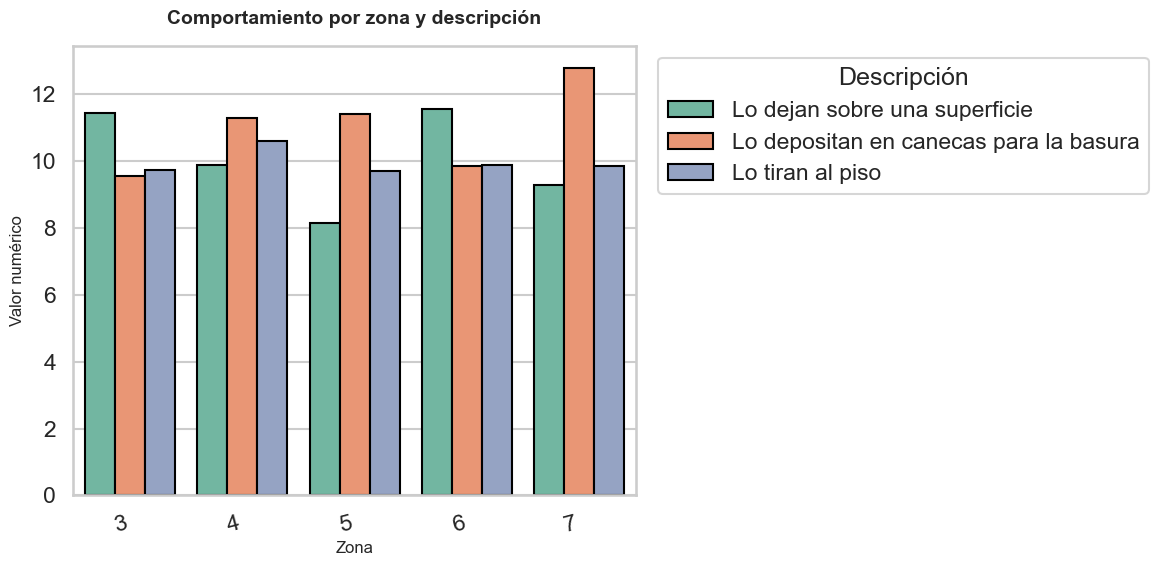

In [ ]:

# (Optional) aggregate if there are repeated (zone_name, description) pairs
df_agg = (
    df_pivot.groupby(["zone_id", "description"], as_index=False)["numeric_value"]
      .mean()
)

# Modern Seaborn style
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(12, 6))

# Grouped bar plot: x = zone_name, hue = description, y = numeric_value
ax = sns.barplot(
    data=df_agg,
    x="zone_id",
    y="numeric_value",
    hue="description",
    palette="Set2",
    edgecolor="black"
)

# Improve aesthetics
ax.set_xlabel("Zona", fontsize=12)
ax.set_ylabel("Valor numérico", fontsize=12)
ax.set_title("Comportamiento por zona y descripción", fontsize=14, pad=16)

plt.xticks(rotation=15, ha="right")
plt.legend(title="Descripción", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Q9 — Disposal compliance by zone
                             n_visits  mean_comp  median_comp  std_comp  total_disposals
zone                                                                                    
Central, pasillos de centr…        20      30.57        28.95     21.61              626
Plazoleta de ingenierías, …        20      30.57        24.49     18.73              615
Facultad de Ciencias natur…        20      34.59        38.24     20.97              636
Cafetería de la Escuela de…        20      40.06        41.96     17.64              585
Pasillos del coliseo, canc…        20      40.99        37.75     12.73              639

  n_zones             : 5
  total visits        : 100
  min visits per zone : 20

  Test selected       : Kruskal-Wallis
  Statistic           : 5.3806
  p-value             : 0.2504  (not significant)
  Effect size (eta² (KW)) : 0.0145  → small

  Dunn post-hoc (Bonferroni corrected):
  Pair                                        z   p_bonf

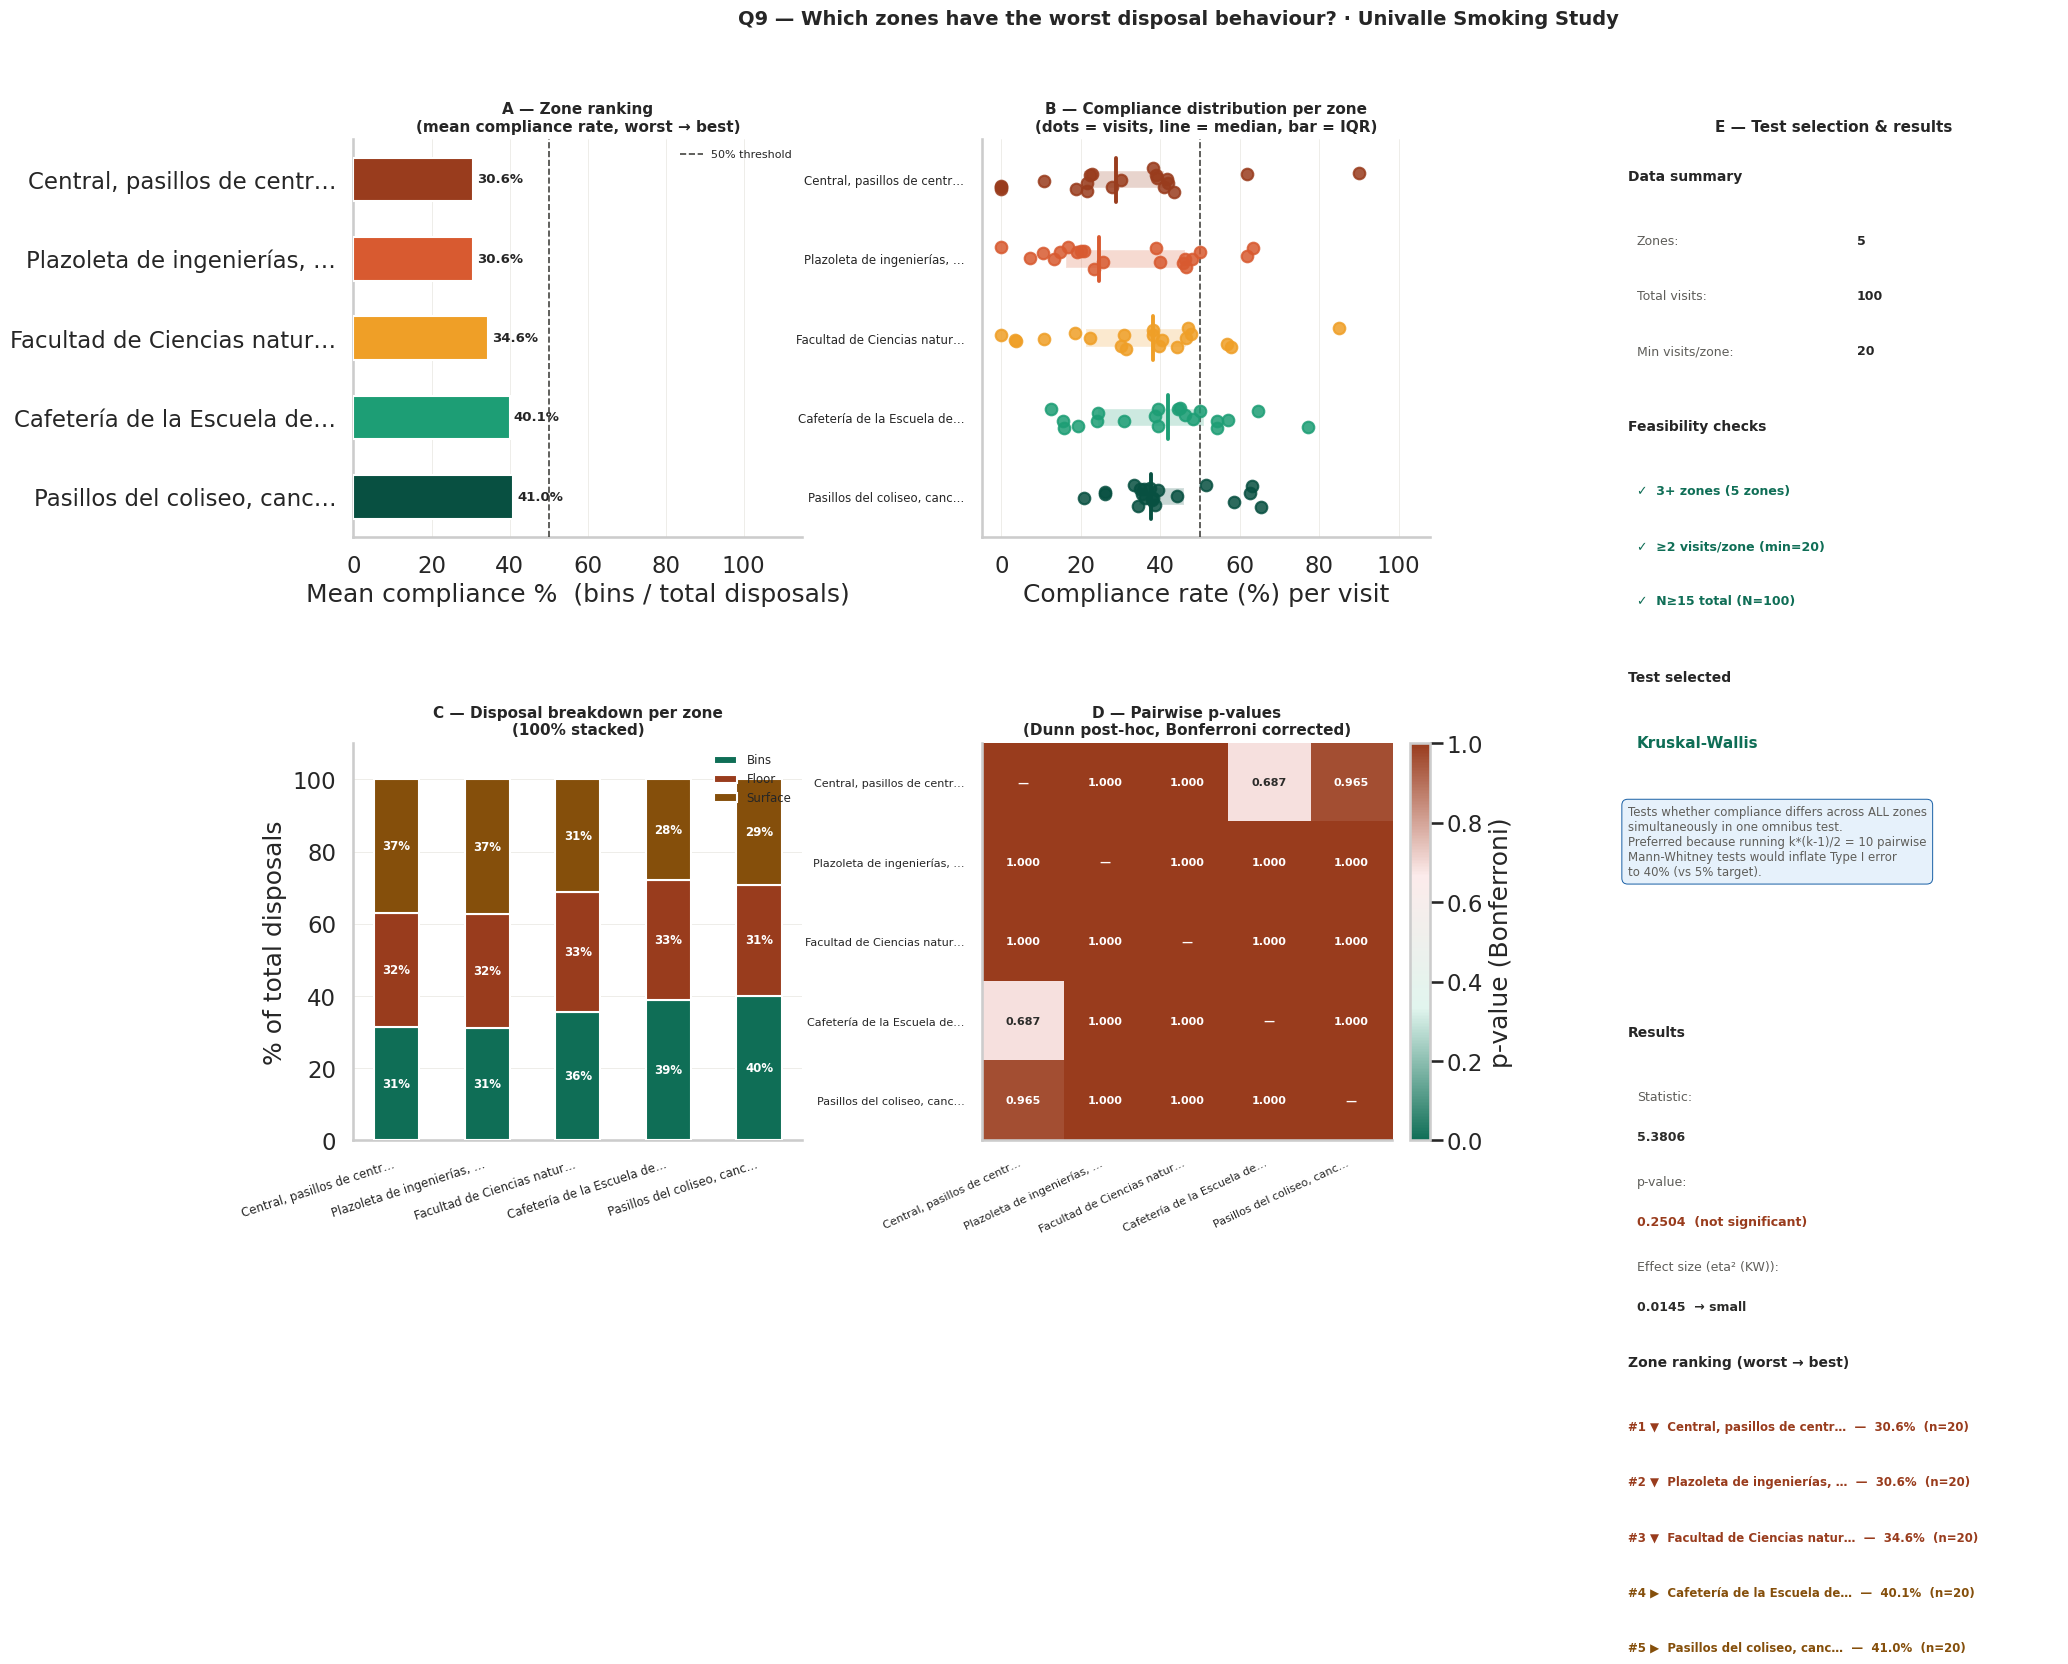

In [ ]:
"""
Q9 Sub-question: Which zones have the worst disposal behaviour?
===============================================================
Metric  : compliance rate per visit = bins / (bins + floor + surface)
          bins    = question 64   floor = question 65   surface = question 66

Automatic test selection
------------------------
The script evaluates your data and picks the appropriate test:

 Condition A  n_zones >= 3  AND  all zones have >= 2 visits
              → Kruskal-Wallis (global) + Dunn post-hoc (Bonferroni)
                This is the primary intended test.

 Condition B  n_zones == 2  AND  both zones have >= 2 visits
              → Mann-Whitney U (valid two-group comparison)

 Condition C  Any zone has only 1 visit
              → Flag warning + descriptive stats only
                (no within-group variance = test is meaningless)

WHY Kruskal-Wallis is preferred over Mann-Whitney when n_zones >= 3
--------------------------------------------------------------------
Running pairwise Mann-Whitney tests on k groups requires k*(k-1)/2
comparisons. With 5 zones that is 10 tests. Each at alpha=0.05 raises
the family-wise error rate to 1-(0.95^10) ≈ 40% — meaning a 40% chance
of at least one false positive. Kruskal-Wallis tests ALL groups in a
single omnibus test, keeping alpha controlled. Dunn post-hoc then
identifies which pairs differ, with Bonferroni keeping the error rate
at 5% across all comparisons.

SQL to extract the full table
------------------------------
SELECT
    v.id                            AS visit_id,
    z.name                          AS zone_name,
    z.id                            AS zone_id,
    qq.description                  AS description,
    rr.numeric_value                AS numeric_value
FROM response_response          rr
JOIN visit_visit                 v   ON rr.visita_id        = v.id
JOIN surveysession_surveysession ss  ON v.surveysession_id  = ss.id
JOIN zone_zone                   z   ON ss.zone_id           = z.id
JOIN question_question           qq  ON rr.question_id       = qq.id
WHERE rr.question_id IN (64, 65, 66)
  AND rr.numeric_value IS NOT NULL
  AND rr.numeric_value > 0
ORDER BY z.id, v.id;
"""

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import kruskal, mannwhitneyu, rankdata, norm
from itertools import combinations



# Truncate long zone names for plot readability
df_pivot["zone"] = df_pivot["zone_name"].apply(
    lambda x: x[:26] + "…" if len(x) > 26 else x
)

method_map = {
    "Lo depositan en canecas para la basura": "bins",
    "Lo tiran al piso":                       "floor",
    "Lo dejan sobre una superficie":          "surface",
}
df_pivot["method"] = df_pivot["description"].map(method_map)

# ── Compliance rate per visit per zone ────────────────────────
pivot = (df_pivot.pivot_table(index=["visit_id", "zone"],
                        columns="method", values="numeric_value",
                        aggfunc="sum")
           .fillna(0).reset_index())
for col in ["bins", "floor", "surface"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot["total"]      = pivot[["bins", "floor", "surface"]].sum(axis=1)
pivot["compliance"] = np.where(
    pivot["total"] > 0, pivot["bins"] / pivot["total"] * 100, np.nan
)
pivot = pivot.dropna(subset=["compliance"])

# ── Zone-level summary ────────────────────────────────────────
zone_summary = (
    pivot.groupby("zone")
         .agg(n_visits    =("visit_id", "count"),
              mean_comp   =("compliance", "mean"),
              median_comp =("compliance", "median"),
              std_comp    =("compliance", "std"),
              total_bins  =("bins", "sum"),
              total_floor =("floor", "sum"),
              total_surf  =("surface", "sum"))
         .round(2)
)
zone_summary["total_disposals"] = zone_summary[
    ["total_bins", "total_floor", "total_surf"]
].sum(axis=1)
zone_summary = zone_summary.sort_values("mean_comp")   # worst → best

zones   = zone_summary.index.tolist()
n_zones = len(zones)
groups  = [pivot.loc[pivot["zone"] == z, "compliance"].values
           for z in zones]

min_visits_per_zone = zone_summary["n_visits"].min()
total_visits        = len(pivot)

# ══════════════════════════════════════════════════════════════
# 2.  AUTOMATIC TEST SELECTION
# ══════════════════════════════════════════════════════════════
# Three conditions evaluated in order:
#   cond_groups  : enough groups for KW
#   cond_variance: every group has >= 2 observations (variance exists)
#   cond_n       : sufficient total N for reliable results

cond_groups   = n_zones >= 3
cond_variance = min_visits_per_zone >= 2
cond_n        = total_visits >= 15            # conservative minimum

test_name   = None
test_stat   = None
p_global    = None
effect_size = None
es_label    = None
pairwise    = {}
warnings_list = []

if cond_groups and cond_variance:
    # ── KRUSKAL-WALLIS + DUNN POST-HOC ────────────────────────
    test_name = "Kruskal-Wallis"
    test_stat, p_global = kruskal(*groups)

    if not cond_n:
        warnings_list.append(
            f"Total N={total_visits} is low (<15). Results are indicative only."
        )

    # Eta-squared effect size for KW: (H - k + 1) / (N - k)
    k = n_zones
    N = total_visits
    eta2 = (test_stat - k + 1) / (N - k) if N > k else np.nan
    eta2 = max(0.0, eta2)
    effect_size = round(eta2, 4)
    es_label    = "eta² (KW)"

    def interpret_eta2(v):
        if   v < 0.01: return "negligible"
        elif v < 0.06: return "small"
        elif v < 0.14: return "medium"
        else:          return "large"
    es_interp = interpret_eta2(eta2)

    # ── Dunn post-hoc with Bonferroni correction ──────────────
    all_vals   = np.concatenate(groups)
    all_labels = np.concatenate([[z] * len(g) for z, g in zip(zones, groups)])
    ranked     = rankdata(all_vals)
    n_pairs    = len(list(combinations(zones, 2)))

    for z1, z2 in combinations(zones, 2):
        r1 = ranked[all_labels == z1]; n1 = len(r1)
        r2 = ranked[all_labels == z2]; n2 = len(r2)
        se = np.sqrt((N * (N + 1) / 12.0) * (1.0/n1 + 1.0/n2))
        z_stat = abs(r1.mean() - r2.mean()) / se if se > 0 else 0
        p_raw  = 2 * (1 - norm.cdf(z_stat))
        p_bonf = min(p_raw * n_pairs, 1.0)
        # Rank-biserial correlation as pairwise effect size
        U_stat, _ = mannwhitneyu(r1, r2, alternative="two-sided")
        rbc = 1 - (2 * U_stat) / (n1 * n2)
        pairwise[(z1, z2)] = {
            "z":      round(z_stat, 3),
            "p_raw":  round(p_raw,  4),
            "p_bonf": round(p_bonf, 4),
            "rbc":    round(rbc,    3),
        }

elif n_zones == 2 and cond_variance:
    # ── MANN-WHITNEY U ────────────────────────────────────────
    test_name = "Mann-Whitney U"
    test_stat, p_global = mannwhitneyu(groups[0], groups[1],
                                       alternative="two-sided")
    n1, n2 = len(groups[0]), len(groups[1])
    z_mw   = norm.ppf(1 - p_global / 2)
    r_mw   = z_mw / np.sqrt(n1 + n2)
    effect_size = round(r_mw, 4)
    es_label    = "r (rank-biserial)"
    es_interp   = ("small" if abs(r_mw) < 0.3
                   else "medium" if abs(r_mw) < 0.5
                   else "large")
    if not cond_n:
        warnings_list.append(
            f"Total N={total_visits} is low. Interpret p-value with caution."
        )

elif not cond_variance:
    test_name = "NONE"
    warnings_list.append(
        f"Some zones have only 1 visit (min={min_visits_per_zone}). "
        "No statistical test can be applied — within-group variance is zero. "
        "Collect ≥2 visits per zone before running any test."
    )
    es_interp = "n/a"

# ══════════════════════════════════════════════════════════════
# 3.  CONSOLE SUMMARY
# ══════════════════════════════════════════════════════════════
SEP = "=" * 65
print(SEP)
print("Q9 — Disposal compliance by zone")
print(SEP)
print(zone_summary[["n_visits","mean_comp","median_comp",
                     "std_comp","total_disposals"]].to_string())
print()
print(f"  n_zones             : {n_zones}")
print(f"  total visits        : {total_visits}")
print(f"  min visits per zone : {min_visits_per_zone}")
print()

if warnings_list:
    print("  WARNINGS:")
    for w in warnings_list:
        print(f"  ⚠  {w}")
    print()

print(f"  Test selected       : {test_name}")
if test_name and test_name != "NONE":
    print(f"  Statistic           : {test_stat:.4f}")
    print(f"  p-value             : {p_global:.4f}  "
          f"({'*significant*' if p_global < 0.05 else 'not significant'})")
    print(f"  Effect size ({es_label}) : {effect_size:.4f}  → {es_interp}")

if pairwise:
    print()
    print("  Dunn post-hoc (Bonferroni corrected):")
    print(f"  {'Pair':<38} {'z':>6} {'p_bonf':>8}  {'rbc':>6}  Sig")
    print("  " + "-" * 64)
    for (z1, z2), res in pairwise.items():
        sig = "*" if res["p_bonf"] < 0.05 else ""
        print(f"  {z1+' vs '+z2:<38} {res['z']:>6.3f}"
              f" {res['p_bonf']:>8.4f}  {res['rbc']:>6.3f}  {sig}")

print()
print("  Zone ranking (worst → best):")
for rank, zone in enumerate(zone_summary.index, 1):
    row  = zone_summary.loc[zone]
    icon = "▼" if row["mean_comp"] < 40 else (
           "▶" if row["mean_comp"] < 60 else "▲")
    print(f"  #{rank} {icon}  {zone:<26}  "
          f"mean={row['mean_comp']:.1f}%  "
          f"median={row['median_comp']:.1f}%  "
          f"n={int(row['n_visits'])} visits")

# ══════════════════════════════════════════════════════════════
# 4.  FIGURE — 5-panel dashboard
# ══════════════════════════════════════════════════════════════
ZONE_PALETTE = ["#993C1D","#D85A30","#EF9F27","#1D9E75","#085041"]
zone_colors  = {z: ZONE_PALETTE[i % len(ZONE_PALETTE)]
                for i, z in enumerate(zone_summary.index)}

GOOD  = "#0F6E56"
BAD_F = "#993C1D"
BAD_S = "#854F0B"

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.5,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})

fig = plt.figure(figsize=(22, 13))
fig.suptitle(
    "Q9 — Which zones have the worst disposal behaviour? · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.40)
ax_rank = fig.add_subplot(gs[0, 0])   # A zone ranking
ax_box  = fig.add_subplot(gs[0, 1])   # B box/strip plot
ax_stk  = fig.add_subplot(gs[1, 0])   # C stacked bar
ax_pw   = fig.add_subplot(gs[1, 1])   # D pairwise p-values
ax_stat = fig.add_subplot(gs[:, 2])   # E statistical summary

# ── Panel A: Zone ranking (mean compliance) ───────────────────
mean_vals  = zone_summary["mean_comp"].values
bar_colors = [zone_colors[z] for z in zone_summary.index]
bars_a = ax_rank.barh(zone_summary.index, mean_vals,
                      color=bar_colors, height=0.55, zorder=3)
ax_rank.axvline(50, color="#444441", lw=1.2, ls="--",
                label="50% threshold", zorder=4)
for bar, val in zip(bars_a, mean_vals):
    ax_rank.text(val + 1, bar.get_y() + bar.get_height()/2,
                 f"{val:.1f}%", va="center",
                 fontsize=9.5, fontweight="bold")
ax_rank.set_title("A — Zone ranking\n(mean compliance rate, worst → best)")
ax_rank.set_xlabel("Mean compliance %  (bins / total disposals)")
ax_rank.set_xlim(0, 115)
ax_rank.invert_yaxis()
ax_rank.legend(frameon=False, fontsize=8)
ax_rank.grid(axis="y", alpha=0)

# ── Panel B: Strip plot (all visit values per zone) ───────────
rng_jit = np.random.default_rng(7)
for i, zone in enumerate(zones):
    vals   = pivot.loc[pivot["zone"] == zone, "compliance"].values
    jitter = rng_jit.uniform(-0.15, 0.15, len(vals))
    ax_box.scatter(vals, np.full_like(vals, i) + jitter,
                   color=zone_colors[zone], s=70, zorder=4, alpha=0.85)
    # median line
    med = np.median(vals)
    ax_box.plot([med]*2, [i-0.28, i+0.28],
                color=zone_colors[zone], lw=2.8, zorder=5)
    # IQR bar
    q1, q3 = np.percentile(vals, [25, 75])
    ax_box.barh(i, q3-q1, left=q1, height=0.22,
                color=zone_colors[zone], alpha=0.22, zorder=3)

ax_box.axvline(50, color="#444441", lw=1.2, ls="--", zorder=3)
ax_box.set_yticks(range(n_zones))
ax_box.set_yticklabels(zones, fontsize=8.5)
ax_box.set_xlabel("Compliance rate (%) per visit")
ax_box.set_title("B — Compliance distribution per zone\n"
                 "(dots = visits, line = median, bar = IQR)")
ax_box.set_xlim(-5, 108)
ax_box.invert_yaxis()
ax_box.grid(axis="y", alpha=0)

# ── Panel C: Stacked 100% bar per zone ───────────────────────
x    = np.arange(n_zones)
w    = 0.5
tb   = zone_summary["total_bins"].values
tf   = zone_summary["total_floor"].values
ts   = zone_summary["total_surf"].values
tot  = tb + tf + ts
safe = np.where(tot > 0, tot, 1)

pct_b = tb / safe * 100
pct_f = tf / safe * 100
pct_s = ts / safe * 100

for vals, bot, col, lbl in [
    (pct_b, np.zeros(n_zones), GOOD,  "Bins"),
    (pct_f, pct_b,             BAD_F, "Floor"),
    (pct_s, pct_b+pct_f,       BAD_S, "Surface"),
]:
    bars_c = ax_stk.bar(x, vals, bottom=bot, color=col,
                        label=lbl, width=w, zorder=3)
    for bar, v, b in zip(bars_c, vals, bot):
        if v > 7:
            ax_stk.text(bar.get_x() + bar.get_width()/2, b + v/2,
                        f"{v:.0f}%", ha="center", va="center",
                        fontsize=8.5, fontweight="bold", color="white")

ax_stk.set_xticks(x)
ax_stk.set_xticklabels(zones, rotation=18, ha="right", fontsize=8.5)
ax_stk.set_ylim(0, 110)
ax_stk.set_ylabel("% of total disposals")
ax_stk.set_title("C — Disposal breakdown per zone\n(100% stacked)")
ax_stk.legend(frameon=False, fontsize=8.5)
ax_stk.grid(axis="x", alpha=0)

# ── Panel D: Pairwise p-values heatmap (Dunn) ────────────────
if pairwise:
    pw_matrix = pd.DataFrame(np.ones((n_zones, n_zones)),
                              index=zones, columns=zones)
    for (z1, z2), res in pairwise.items():
        pw_matrix.loc[z1, z2] = res["p_bonf"]
        pw_matrix.loc[z2, z1] = res["p_bonf"]

    from matplotlib.colors import LinearSegmentedColormap
    cmap_pw = LinearSegmentedColormap.from_list(
        "sig", ["#0F6E56", "#E1F5EE", "#FCEBEB", "#993C1D"])
    im = ax_pw.imshow(pw_matrix.values, cmap=cmap_pw,
                      vmin=0, vmax=1, aspect="auto")
    ax_pw.set_xticks(range(n_zones))
    ax_pw.set_yticks(range(n_zones))
    ax_pw.set_xticklabels(zones, rotation=25, ha="right", fontsize=8)
    ax_pw.set_yticklabels(zones, fontsize=8)
    for r in range(n_zones):
        for c in range(n_zones):
            val = pw_matrix.values[r, c]
            txt = "—" if r == c else (
                f"{val:.3f}{'*' if val < 0.05 else ''}")
            col_t = "white" if val < 0.15 or val > 0.85 else "#2c2c2a"
            ax_pw.text(c, r, txt, ha="center", va="center",
                       fontsize=8, fontweight="bold", color=col_t)
    fig.colorbar(im, ax=ax_pw, fraction=0.046, pad=0.04,
                 label="p-value (Bonferroni)")
    ax_pw.set_title("D — Pairwise p-values\n(Dunn post-hoc, Bonferroni corrected)")
    ax_pw.grid(False)
elif test_name == "Mann-Whitney U":
    ax_pw.axis("off")
    ax_pw.text(0.5, 0.55,
               f"Mann-Whitney U\n\nU = {test_stat:.1f}\np = {p_global:.4f}\n"
               f"r = {effect_size:.3f} ({es_interp})",
               ha="center", va="center", fontsize=13,
               transform=ax_pw.transAxes,
               bbox=dict(boxstyle="round,pad=0.7", fc="#E1F5EE",
                         ec="#0F6E56", lw=1))
    ax_pw.set_title("D — Test result\n(Mann-Whitney U)")
else:
    ax_pw.axis("off")
    ax_pw.text(0.5, 0.5, "No test available\n(insufficient data)",
               ha="center", va="center", fontsize=11,
               color="#993C1D", transform=ax_pw.transAxes)
    ax_pw.set_title("D — Test result")

# ── Panel E: Statistical summary text ─────────────────────────
ax_stat.axis("off")
ax_stat.set_title("E — Test selection & results",
                  fontweight="bold", fontsize=11)

def T(ax, x, y, s, **kw):
    ax.text(x, y, s, transform=ax.transAxes,
            fontsize=kw.pop("fs", 9), va="top", **kw)

y = 0.97
T(ax_stat, 0.04, y, "Data summary", fontweight="bold", fs=10)
y -= 0.065
for label, val in [("Zones",         str(n_zones)),
                   ("Total visits",   str(total_visits)),
                   ("Min visits/zone",str(min_visits_per_zone))]:
    T(ax_stat, 0.06, y, f"{label}:", fs=9, color="#5F5E5A")
    T(ax_stat, 0.55, y, val, fs=9, fontweight="bold")
    y -= 0.055

# Feasibility check boxes
y -= 0.02
T(ax_stat, 0.04, y, "Feasibility checks", fontweight="bold", fs=10)
y -= 0.065
checks = [
    ("3+ zones",          cond_groups,   f"{n_zones} zones"),
    ("≥2 visits/zone",    cond_variance, f"min={min_visits_per_zone}"),
    ("N≥15 total",        cond_n,        f"N={total_visits}"),
]
for label, passed, detail in checks:
    icon  = "✓" if passed else "✗"
    color = "#0F6E56" if passed else "#993C1D"
    T(ax_stat, 0.06, y, f"{icon}  {label} ({detail})",
      fs=9, color=color, fontweight="bold")
    y -= 0.055

# Test chosen
y -= 0.02
T(ax_stat, 0.04, y, "Test selected", fontweight="bold", fs=10)
y -= 0.065
test_color = ("#0F6E56" if test_name == "Kruskal-Wallis"
              else "#854F0B" if test_name == "Mann-Whitney U"
              else "#993C1D")
T(ax_stat, 0.06, y, test_name, fs=11, fontweight="bold", color=test_color)
y -= 0.07

# Why box
why_kw = {
    "Kruskal-Wallis": (
        "Tests whether compliance differs across ALL zones\n"
        "simultaneously in one omnibus test.\n"
        "Preferred because running k*(k-1)/2 = "
        f"{n_zones*(n_zones-1)//2} pairwise\n"
        "Mann-Whitney tests would inflate Type I error\n"
        f"to {(1-(0.95**max(n_zones*(n_zones-1)//2,1)))*100:.0f}% "
        f"(vs 5% target)."
    ),
    "Mann-Whitney U": (
        "Only 2 zones available — KW is equivalent\n"
        "to Mann-Whitney U with exactly 2 groups.\n"
        "Add more zones to use the full KW test."
    ),
    "NONE": (
        "Cannot run any test.\n"
        "Each zone needs ≥2 visits to estimate\n"
        "within-group variance. Collect more data."
    ),
}
T(ax_stat, 0.04, y,
  why_kw.get(test_name, ""),
  fs=8.5, color="#5F5E5A",
  bbox=dict(boxstyle="round,pad=0.5",
            fc="#E6F1FB", ec="#185FA5", lw=0.7))
y -= 0.22

# Results
if test_name and test_name != "NONE":
    T(ax_stat, 0.04, y, "Results", fontweight="bold", fs=10)
    y -= 0.065
    sig_col = "#0F6E56" if p_global < 0.05 else "#993C1D"
    for label, val in [
        ("Statistic", f"{test_stat:.4f}"),
        ("p-value",   f"{p_global:.4f}  "
                      f"({'significant *' if p_global<0.05 else 'not significant'})"),
        (f"Effect size ({es_label})",
                      f"{effect_size:.4f}  → {es_interp}"),
    ]:
        T(ax_stat, 0.06, y, f"{label}:", fs=9, color="#5F5E5A")
        T(ax_stat, 0.06, y - 0.04, val, fs=9, fontweight="bold",
          color=sig_col if "p-value" in label else "#2c2c2a")
        y -= 0.085

# Zone ranking
y -= 0.01
T(ax_stat, 0.04, y, "Zone ranking (worst → best)",
  fontweight="bold", fs=10)
y -= 0.065
for rank, zone in enumerate(zone_summary.index, 1):
    row  = zone_summary.loc[zone]
    comp = row["mean_comp"]
    icon = "▼" if comp < 40 else ("▶" if comp < 60 else "▲")
    col  = "#993C1D" if comp < 40 else (
           "#854F0B" if comp < 60 else "#0F6E56")
    T(ax_stat, 0.04, y,
      f"#{rank} {icon}  {zone}  —  {comp:.1f}%  "
      f"(n={int(row['n_visits'])})",
      fs=8.5, color=col, fontweight="bold")
    y -= 0.055

# Warnings
if warnings_list:
    y -= 0.01
    for w in warnings_list:
        T(ax_stat, 0.04, y, f"⚠  {w}",
          fs=8, color="#854F0B",
          bbox=dict(boxstyle="round,pad=0.4",
                    fc="#FAEEDA", ec="#854F0B", lw=0.7))
        y -= 0.08


# Q14.4:Is the supply of bins sufficient?

In [ ]:
df_pivot=pd.read_sql("""
SELECT
    v.id                  AS visit_id,
    z.name                AS zone_name,
    z.id                  AS zone_id,
    rr.question_id,
    rr.numeric_value
FROM response_response          rr
JOIN visit_visit                 v   ON rr.visita_id        = v.id
JOIN surveysession_surveysession ss  ON v.surveysession_id  = ss.id
JOIN zone_zone                   z   ON ss.zone_id           = z.id
WHERE rr.question_id IN (1, 64, 65, 66, 167)
  AND rr.numeric_value IS NOT NULL
  AND rr.numeric_value > 0
ORDER BY z.id, v.id;

""",co)
df_pivot

,visit_id,zone_name,zone_id,question_id,numeric_value
0,225,"Plazoleta de ingenierías, pasillos de la Escue...",3,1,4
1,225,"Plazoleta de ingenierías, pasillos de la Escue...",3,64,8
2,225,"Plazoleta de ingenierías, pasillos de la Escue...",3,65,18
3,225,"Plazoleta de ingenierías, pasillos de la Escue...",3,66,16
4,225,"Plazoleta de ingenierías, pasillos de la Escue...",3,167,18
...,...,...,...,...,...
471,324,"Pasillos del coliseo, canchas cercanas al coli...",7,1,14
472,324,"Pasillos del coliseo, canchas cercanas al coli...",7,64,9
473,324,"Pasillos del coliseo, canchas cercanas al coli...",7,65,3
474,324,"Pasillos del coliseo, canchas cercanas al coli...",7,66,12


Q9 — Is the supply of bins sufficient?
                             n_visits  mean_smokers  mean_bins  mean_suff_index  mean_irresp  pct_sufficient     verdict
zone                                                                                                                    
Central, pasillos de centr…        20        11.150     10.100            1.326       69.427          90.000  SUFFICIENT
Pasillos del coliseo, canc…        20        10.800     10.200            2.263       59.013          85.000  SUFFICIENT
Facultad de Ciencias natur…        19         8.737      9.421            2.363       65.670          89.474  SUFFICIENT
Plazoleta de ingenierías, …        18        10.444     11.056            2.602       68.147          94.444  SUFFICIENT
Cafetería de la Escuela de…        20         9.550     11.800            2.857       59.944          95.000  SUFFICIENT

  Threshold used : 0.20 (1 bin per 5 smokers)

  Spearman correlation (sufficiency index vs irresponsible rate):


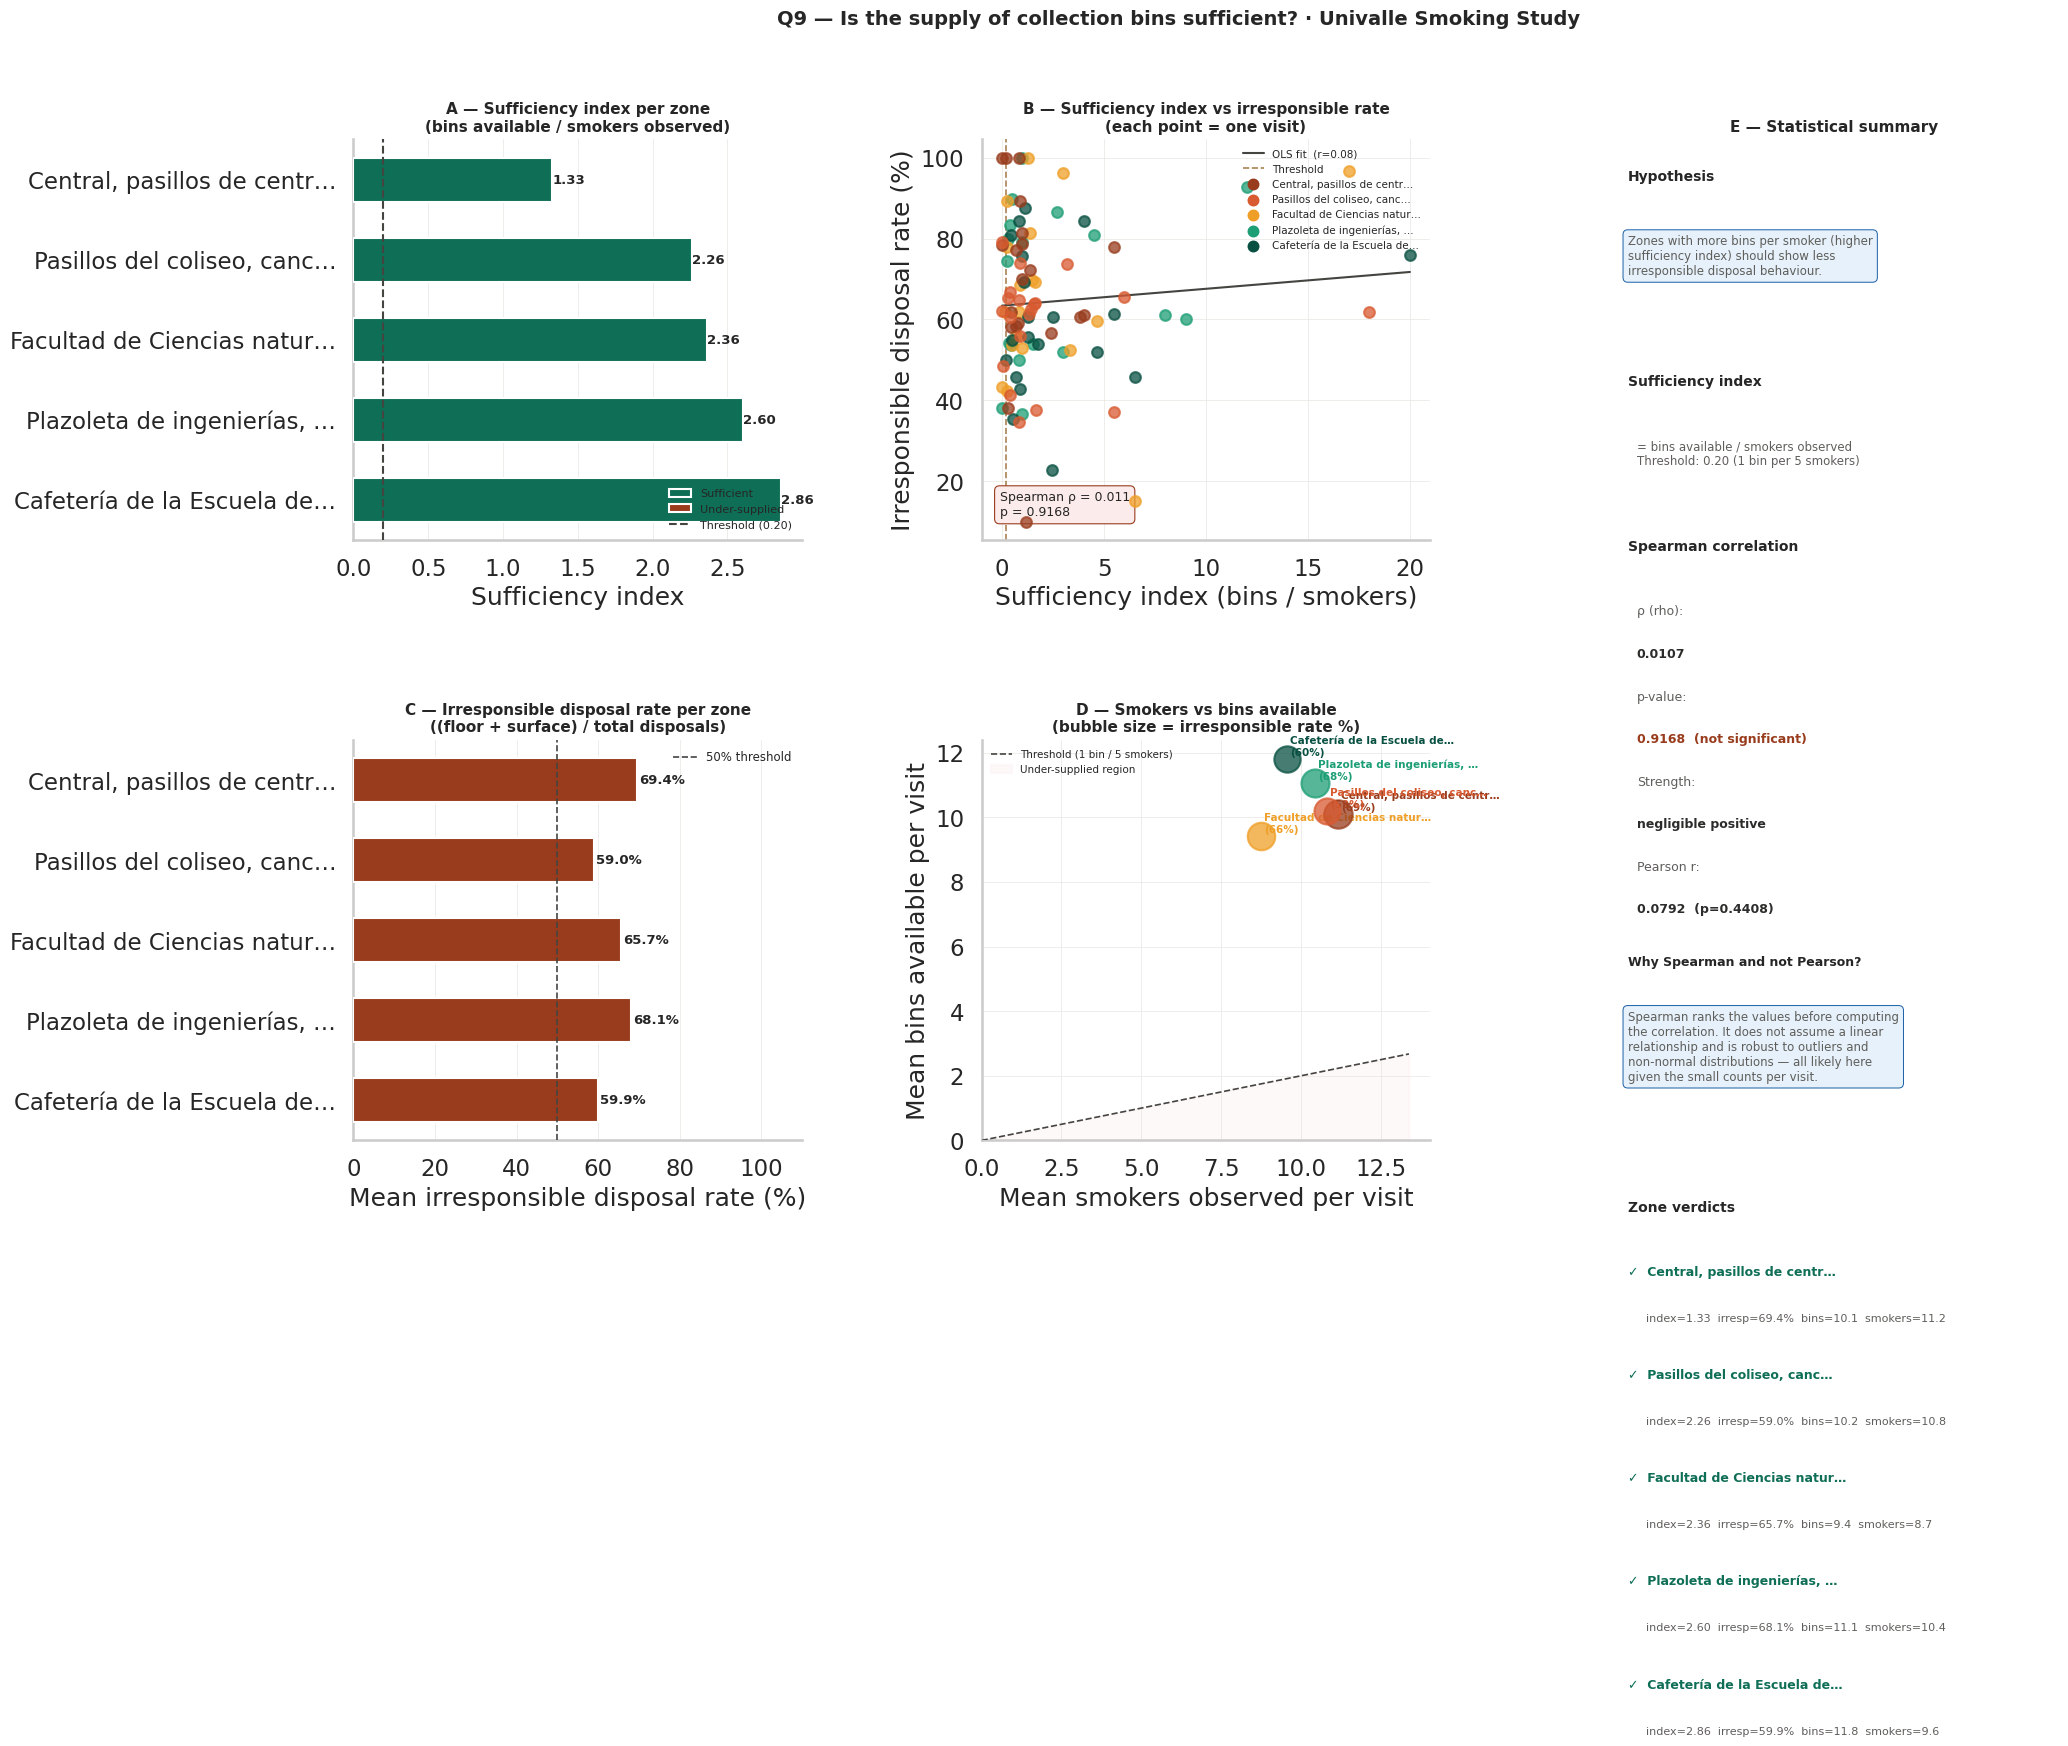

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr, pearsonr

SUFFICIENCY_THRESHOLD = 0.20 

df_pivot["zone"] = df_pivot["zone_name"].apply(
    lambda x: x[:26] + "…" if len(x) > 26 else x
)
 
# Pivot to one row per (visit, zone)
wide = (df_pivot.pivot_table(index=["visit_id","zone"],
                       columns="question_id",
                       values="numeric_value",
                       aggfunc="sum")
          .fillna(0).reset_index())
 
for qid in [1, 64, 65, 66, 167]:
    if qid not in wide.columns:
        wide[qid] = 0
 
wide.rename(columns={
    1:   "smokers",
    167: "bins_avail",
    64:  "bins_use",
    65:  "floor",
    66:  "surface",
}, inplace=True)
 
# ── Derived indicators ────────────────────────────────────────
wide["total_disposals"]    = wide["bins_use"] + wide["floor"] + wide["surface"]
wide["irresponsible_rate"] = np.where(
    wide["total_disposals"] > 0,
    (wide["floor"] + wide["surface"]) / wide["total_disposals"] * 100,
    np.nan
)
wide["sufficiency_index"] = np.where(
    wide["smokers"] > 0,
    wide["bins_avail"] / wide["smokers"],
    np.nan
)
wide["status"] = np.where(
    wide["sufficiency_index"] >= SUFFICIENCY_THRESHOLD,
    "sufficient", "under-supplied"
)
 
data = wide.dropna(subset=["sufficiency_index","irresponsible_rate"])
 
# ── Zone-level aggregation ────────────────────────────────────
zone_agg = (data.groupby("zone")
                .agg(n_visits         =("visit_id","count"),
                     mean_smokers     =("smokers","mean"),
                     mean_bins        =("bins_avail","mean"),
                     mean_suff_index  =("sufficiency_index","mean"),
                     mean_irresp      =("irresponsible_rate","mean"),
                     pct_sufficient   =("status",
                                       lambda x: (x=="sufficient").mean()*100))
                .round(3))
zone_agg["verdict"] = np.where(
    zone_agg["mean_suff_index"] >= SUFFICIENCY_THRESHOLD,
    "SUFFICIENT", "UNDER-SUPPLIED"
)
zone_agg = zone_agg.sort_values("mean_suff_index")
 
# ══════════════════════════════════════════════════════════════
# 2.  STATISTICAL TESTS
# ══════════════════════════════════════════════════════════════
x_suff  = data["sufficiency_index"].values
y_irresp = data["irresponsible_rate"].values
 
# Spearman (primary — non-parametric, robust)
rho, p_spear = spearmanr(x_suff, y_irresp)
 
# Pearson (secondary — for reference, assumes linearity)
r_pear, p_pear = pearsonr(x_suff, y_irresp)
 
# Regression line for scatter plot
m, b = np.polyfit(x_suff, y_irresp, 1)
 
def interp_rho(r):
    r = abs(r)
    if   r < 0.10: return "negligible"
    elif r < 0.30: return "weak"
    elif r < 0.50: return "moderate"
    elif r < 0.70: return "strong"
    else:          return "very strong"
 
# ══════════════════════════════════════════════════════════════
# 3.  CONSOLE SUMMARY
# ══════════════════════════════════════════════════════════════
SEP = "=" * 65
print(SEP)
print("Q9 — Is the supply of bins sufficient?")
print(SEP)
print(zone_agg[["n_visits","mean_smokers","mean_bins",
                "mean_suff_index","mean_irresp",
                "pct_sufficient","verdict"]].to_string())
print()
print(f"  Threshold used : {SUFFICIENCY_THRESHOLD:.2f} "
      f"(1 bin per {int(1/SUFFICIENCY_THRESHOLD)} smokers)")
print()
print("  Spearman correlation (sufficiency index vs irresponsible rate):")
print(f"  ρ = {rho:.4f}   p = {p_spear:.4f}  "
      f"({'*significant*' if p_spear<0.05 else 'not significant'})")
print(f"  Interpretation: {interp_rho(rho)} "
      f"{'negative' if rho<0 else 'positive'} association")
print()
print("  Pearson correlation (linear reference):")
print(f"  r = {r_pear:.4f}   p = {p_pear:.4f}")
print()
print("  Zone verdicts:")
for zone, row in zone_agg.iterrows():
    icon = "✓" if row["verdict"]=="SUFFICIENT" else "✗"
    print(f"  {icon}  {zone:<24}  "
          f"index={row['mean_suff_index']:.2f}  "
          f"irresponsible={row['mean_irresp']:.1f}%  "
          f"→ {row['verdict']}")
 
# ══════════════════════════════════════════════════════════════
# 4.  FIGURE — 5-panel dashboard
# ══════════════════════════════════════════════════════════════
zones      = zone_agg.index.tolist()
n_zones    = len(zones)
PALETTE    = ["#993C1D","#D85A30","#EF9F27","#1D9E75","#085041"]
zone_colors = {z: PALETTE[i % len(PALETTE)]
               for i, z in enumerate(zone_agg.index)}
 
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e8e6e0",
    "grid.linewidth":    0.5,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
})
 
fig = plt.figure(figsize=(22, 13))
fig.suptitle(
    "Q9 — Is the supply of collection bins sufficient? · Univalle Smoking Study",
    fontsize=14, fontweight="bold", y=0.98
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.40)
ax_idx  = fig.add_subplot(gs[0, 0])   # A sufficiency index per zone
ax_scat = fig.add_subplot(gs[0, 1])   # B scatter: index vs irresponsible
ax_bar  = fig.add_subplot(gs[1, 0])   # C irresponsible rate per zone
ax_bub  = fig.add_subplot(gs[1, 1])   # D bubble: smokers vs bins vs rate
ax_stat = fig.add_subplot(gs[:, 2])   # E statistical summary
 
# ── Panel A: Sufficiency index per zone (horizontal bar) ──────
suff_vals  = zone_agg["mean_suff_index"].values
bar_colors = ["#0F6E56" if v >= SUFFICIENCY_THRESHOLD
              else "#993C1D" for v in suff_vals]
bars_a = ax_idx.barh(zones, suff_vals,
                     color=bar_colors, height=0.55, zorder=3)
ax_idx.axvline(SUFFICIENCY_THRESHOLD, color="#444441",
               lw=1.5, ls="--", zorder=4,
               label=f"Threshold ({SUFFICIENCY_THRESHOLD:.2f})")
for bar, val in zip(bars_a, suff_vals):
    ax_idx.text(val + 0.003,
                bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center",
                fontsize=9.5, fontweight="bold")
ax_idx.set_title("A — Sufficiency index per zone\n"
                 "(bins available / smokers observed)")
ax_idx.set_xlabel("Sufficiency index")
ax_idx.invert_yaxis()
ax_idx.legend(frameon=False, fontsize=8.5)
ax_idx.grid(axis="y", alpha=0)
# Colour legend
from matplotlib.patches import Patch
legend_els = [Patch(fc="#0F6E56", label="Sufficient"),
              Patch(fc="#993C1D", label="Under-supplied")]
ax_idx.legend(handles=legend_els + ax_idx.get_legend_handles_labels()[0],
              frameon=False, fontsize=8, loc="lower right")
 
# ── Panel B: Scatter — sufficiency index vs irresponsible rate ─
for _, row in data.iterrows():
    ax_scat.scatter(row["sufficiency_index"],
                    row["irresponsible_rate"],
                    color=zone_colors[row["zone"]],
                    s=60, alpha=0.75, zorder=4)
 
# Regression line
x_line = np.linspace(data["sufficiency_index"].min(),
                     data["sufficiency_index"].max(), 100)
ax_scat.plot(x_line, m*x_line + b,
             color="#444441", lw=1.5, ls="-", zorder=3,
             label=f"OLS fit  (r={r_pear:.2f})")
ax_scat.axvline(SUFFICIENCY_THRESHOLD, color="#854F0B",
                lw=1.2, ls="--", alpha=0.7, label="Threshold")
 
# Legend for zones
for zone, col in zone_colors.items():
    ax_scat.scatter([], [], color=col, s=50, label=zone)
ax_scat.legend(frameon=False, fontsize=7.5, loc="upper right")
 
# Spearman annotation
ax_scat.text(0.04, 0.06,
             f"Spearman ρ = {rho:.3f}\np = {p_spear:.4f}",
             transform=ax_scat.transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.4",
                       fc="#E1F5EE" if p_spear<0.05 else "#FCEBEB",
                       ec="#0F6E56" if p_spear<0.05 else "#993C1D",
                       lw=0.8))
ax_scat.set_xlabel("Sufficiency index (bins / smokers)")
ax_scat.set_ylabel("Irresponsible disposal rate (%)")
ax_scat.set_title("B — Sufficiency index vs irresponsible rate\n"
                  "(each point = one visit)")
 
# ── Panel C: Irresponsible rate per zone (bar) ────────────────
irresp_vals = zone_agg["mean_irresp"].values
c_irresp    = ["#993C1D" if v > 50 else "#EF9F27" if v > 30
               else "#0F6E56" for v in irresp_vals]
bars_c = ax_bar.barh(zones, irresp_vals,
                     color=c_irresp, height=0.55, zorder=3)
ax_bar.axvline(50, color="#444441", lw=1.2, ls="--",
               label="50% threshold", zorder=4)
for bar, val in zip(bars_c, irresp_vals):
    ax_bar.text(val + 0.5,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%", va="center",
                fontsize=9.5, fontweight="bold")
ax_bar.set_title("C — Irresponsible disposal rate per zone\n"
                 "((floor + surface) / total disposals)")
ax_bar.set_xlabel("Mean irresponsible disposal rate (%)")
ax_bar.set_xlim(0, 110)
ax_bar.invert_yaxis()
ax_bar.legend(frameon=False, fontsize=8.5)
ax_bar.grid(axis="y", alpha=0)
 
# ── Panel D: Bubble chart — smokers vs bins, bubble = irresponsible rate ─
for zone, row in zone_agg.iterrows():
    size = row["mean_irresp"] * 6
    ax_bub.scatter(row["mean_smokers"], row["mean_bins"],
                   s=size, color=zone_colors[zone],
                   alpha=0.75, zorder=4)
    ax_bub.text(row["mean_smokers"] + 0.1,
                row["mean_bins"] + 0.05,
                f"{zone}\n({row['mean_irresp']:.0f}%)",
                fontsize=7.5, va="bottom", color=zone_colors[zone],
                fontweight="bold")
 
# 1:5 ratio line (threshold)
x_bub = np.linspace(0, zone_agg["mean_smokers"].max() * 1.2, 100)
ax_bub.plot(x_bub, x_bub * SUFFICIENCY_THRESHOLD,
            color="#444441", lw=1.2, ls="--", zorder=3,
            label=f"Threshold (1 bin / {int(1/SUFFICIENCY_THRESHOLD)} smokers)")
ax_bub.fill_between(x_bub, x_bub * SUFFICIENCY_THRESHOLD,
                    color="#FCEBEB", alpha=0.25, zorder=0,
                    label="Under-supplied region")
ax_bub.set_xlabel("Mean smokers observed per visit")
ax_bub.set_ylabel("Mean bins available per visit")
ax_bub.set_title("D — Smokers vs bins available\n"
                 "(bubble size = irresponsible rate %)")
ax_bub.legend(frameon=False, fontsize=7.5)
ax_bub.set_xlim(left=0)
ax_bub.set_ylim(bottom=0)
 
# ── Panel E: Statistical summary ──────────────────────────────
ax_stat.axis("off")
ax_stat.set_title("E — Statistical summary",
                  fontweight="bold", fontsize=11)
 
def T(ax, x, y, s, **kw):
    ax.text(x, y, s, transform=ax.transAxes,
            fontsize=kw.pop("fs", 9), va="top", **kw)
 
y = 0.97
T(ax_stat, 0.04, y, "Hypothesis", fontweight="bold", fs=10)
y -= 0.065
T(ax_stat, 0.04, y,
  "Zones with more bins per smoker (higher\n"
  "sufficiency index) should show less\n"
  "irresponsible disposal behaviour.",
  fs=8.5, color="#5F5E5A",
  bbox=dict(boxstyle="round,pad=0.4",
            fc="#E6F1FB", ec="#185FA5", lw=0.7))
y -= 0.14
 
T(ax_stat, 0.04, y, "Sufficiency index", fontweight="bold", fs=10)
y -= 0.065
T(ax_stat, 0.06, y,
  f"= bins available / smokers observed\n"
  f"Threshold: {SUFFICIENCY_THRESHOLD:.2f} "
  f"(1 bin per {int(1/SUFFICIENCY_THRESHOLD)} smokers)",
  fs=8.5, color="#5F5E5A")
y -= 0.10
 
T(ax_stat, 0.04, y, "Spearman correlation", fontweight="bold", fs=10)
y -= 0.065
sig_col = "#0F6E56" if p_spear < 0.05 else "#993C1D"
for label, val in [
    ("ρ (rho)",   f"{rho:.4f}"),
    ("p-value",   f"{p_spear:.4f}  "
                  f"({'significant *' if p_spear<0.05 else 'not significant'})"),
    ("Strength",  f"{interp_rho(rho)} "
                  f"{'negative' if rho<0 else 'positive'}"),
    ("Pearson r", f"{r_pear:.4f}  (p={p_pear:.4f})"),
]:
    T(ax_stat, 0.06, y, f"{label}:", fs=9, color="#5F5E5A")
    T(ax_stat, 0.06, y-0.042, val, fs=9, fontweight="bold",
      color=sig_col if "p-value" in label else "#2c2c2a")
    y -= 0.085
 
y -= 0.01
T(ax_stat, 0.04, y, "Why Spearman and not Pearson?",
  fontweight="bold", fs=9)
y -= 0.055
T(ax_stat, 0.04, y,
  "Spearman ranks the values before computing\n"
  "the correlation. It does not assume a linear\n"
  "relationship and is robust to outliers and\n"
  "non-normal distributions — all likely here\n"
  "given the small counts per visit.",
  fs=8.5, color="#5F5E5A",
  bbox=dict(boxstyle="round,pad=0.4",
            fc="#E6F1FB", ec="#185FA5", lw=0.7))
y -= 0.19
 
T(ax_stat, 0.04, y, "Zone verdicts", fontweight="bold", fs=10)
y -= 0.065
for zone, row in zone_agg.iterrows():
    ok   = row["verdict"] == "SUFFICIENT"
    icon = "✓" if ok else "✗"
    col  = "#0F6E56" if ok else "#993C1D"
    T(ax_stat, 0.04, y,
      f"{icon}  {zone}",
      fs=9, color=col, fontweight="bold")
    y -= 0.048
    T(ax_stat, 0.08, y,
      f"index={row['mean_suff_index']:.2f}  "
      f"irresp={row['mean_irresp']:.1f}%  "
      f"bins={row['mean_bins']:.1f}  "
      f"smokers={row['mean_smokers']:.1f}",
      fs=8, color="#5F5E5A")
    y -= 0.055
 

 

In [ ]:
df_pivot=pd.read_sql("""
SELECT DISTINCT r.visita_id 
FROM response_response as r JOIN visit_visit as v ON r.visita_id=v.id
JOIN surveysession_surveysession as sv ON v.surveysession_id=sv.id
JOIN observer_observer as b ON sv.observer_id=b.id

""",co)

df_pivot

,visita_id
0,225
1,226
2,227
3,228
4,229
...,...
95,280
96,281
97,282
98,283


In [ ]:
df_pivot=pd.read_sql("SELECT * FROM observer_observer",co)

df_pivot

,id,name,email,register_date
0,1,ANDRES DAVID ORTEGA ARTEAGA,andres.david.ortega@correounivalle.edu.co,2025-11-03 21:54:55.282009
1,15,andres david,andresuv.ortega@gmail.com,2026-03-02 19:19:09.182834


# Revisar las preguntas de la 1 hasta la 14, analizar si es necesario hacer agregaciones de suma o promedio